# Notebook for experiments with skeletonization

Imports

In [3]:
from typing import List, Set
import numpy as np
import uuid
import networkx as nx
from rdp import rdp
import os
from cv2 import imread
from skimage.morphology import skeletonize
from ypstruct import structure
import gng
import matplotlib.pyplot as plt

Additional parameters:

In [4]:
epsilon = 2.5
binary_threshold = 160

RDP implementation:

In [5]:
def simplify_network(net, epsilon=1.0):
    # Find endpoints and intersections
    degree = np.sum(net.C, axis=0)
    endpoints = set(np.where(degree == 1)[0])
    intersections = set(np.where(degree > 2)[0])
    
    simplified_segments = []
    visited_edges = set()
    
    def traverse_segment(start, current):
        segment = [net.w[start]]
        while current not in endpoints and current not in intersections:
            segment.append(net.w[current])
            neighbors = set(np.where(net.C[current] == 1)[0]) - {start}
            if not neighbors:
                break
            start, current = current, neighbors.pop()
        segment.append(net.w[current])
        return segment, current

    def process_node(node):
        neighbors = set(np.where(net.C[node] == 1)[0])
        for neighbor in neighbors:
            if (node, neighbor) not in visited_edges and (neighbor, node) not in visited_edges:
                visited_edges.add((node, neighbor))
                visited_edges.add((neighbor, node))
                segment, end = traverse_segment(node, neighbor)
                if len(segment) > 2:
                    simplified_segment = rdp(np.array(segment), epsilon)
                    simplified_segments.append(simplified_segment)
                if end != neighbor:
                    process_node(end)

    # Process all endpoints and intersections
    for node in endpoints.union(intersections):
        process_node(node)
    
    return simplified_segments

Simplified network to NetworkX graph:

In [6]:
def to_networkx(simplified_network: List[List[np.ndarray]]) -> nx.Graph:
    """
    Convert the simplified network to a NetworkX graph with labeled nodes and edge data.

    Args:
        simplified_network (List[List[np.ndarray]]): The simplified network as a list of segments,
            each segment is a list of points represented as numpy arrays.

    Returns:
        nx.Graph: A NetworkX graph with nodes labeled by coordinates and edges with endpoint data.
    """
    G = nx.Graph()
    for i, segment in enumerate(simplified_network):
        for j in range(len(segment) - 1):
            source_coord = tuple(segment[j])
            target_coord = tuple(segment[j + 1])
            
            # Create unique identifiers for source and target nodes
            source_id = hash(source_coord)
            target_id = hash(target_coord)

            # Add source node with attributes if not already present
            if source_id not in G:
                G.add_node(source_id, x=source_coord[1], y=source_coord[0], uuid=str(uuid.uuid4()))

            # Add target node with attributes if not already present
            if target_id not in G:
                G.add_node(target_id, x=target_coord[1], y=target_coord[0], uuid=str(uuid.uuid4()))

            # Calculate edge length
            length = np.linalg.norm(np.array(target_coord) - np.array(source_coord))

            # Add edge with segment ID and endpoint information
            G.add_edge(source_id, target_id, 
                        segment_id=i, 
                        uuid=str(uuid.uuid4()),
                        x1=source_coord[1],
                        y1=source_coord[0],
                        x2=target_coord[1],
                        y2=target_coord[0],
                        length=length)

    return G

Iterate over images in folder function

In [7]:
def iterate_over_images_in_folder(folder_path: str):
    for file in os.listdir(folder_path):
        if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif")):
            yield file


In [8]:
def binary_image(image_path: str):
    image = imread(image_path, 0)
    binary = image > binary_threshold
    return binary

In [9]:
def skeleton_image(image_path: str):
    binary = binary_image(image_path)
    skeleton = skeletonize(binary)
    return skeleton

In [10]:
def get_image_points(skeleton: np.ndarray):
    points = []
    h, w = skeleton.shape
    for y in range(h):
        for x in range(w):
            # Threshold the pixel
            if skeleton[y, x] > 0:
                points.append([x, y])

    return np.array(points)

In [11]:
params = structure()
params.N = 35 # Number of neuronsq
params.maxit = 100 # Maximum number of iterations
params.L = 100 # Learning rate
params.epsilon_b = 0.2 # Basal lr
params.epsilon_n = 0.01 # Neighborhood lr
params.alpha = 0.5 # Learning rate decay
params.delta = 0.995 # Neighborhood radius decay
params.T = 50 # Number of epochs
    
def gng_process(image_points: np.ndarray):
    return gng.fit(image_points, params)

In [12]:
def plot_network_result(image_path, network, network_params: structure, points: np.ndarray, image: np.ndarray, binary: np.ndarray, skeleton: np.ndarray, simplified_network: List[List[np.ndarray]]):
    # Create a figure with four subplots side by side
    fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(40, 10))

    # Plot original image on the left
    ax1.imshow(image, cmap='gray')
    ax1.set_title(f'Original Image: {image_path}')
    ax1.axis('off')
    
    ax2.imshow(binary, cmap='gray')
    ax2.set_title('Binary Image')
    ax2.axis('off')

    # Plot skeletonized image in the middle-left
    ax3.imshow(skeleton, cmap='gray')
    ax3.set_title('Skeletonized Image')
    ax3.axis('off')

    # Plot GNG result in the middle-right
    ax4.grid()
    ax4.scatter(points[:, 0], points[:, 1], s=2)
    for i in range(network_params.N):
        for j in range(i+1, network_params.N):
            if network.C[i, j] == 1:
                ax4.plot([network.w[i, 0], network.w[j, 0]], [network.w[i, 1], network.w[j, 1]], c='r')

    ax4.scatter(network.w[:, 0], network.w[:, 1], s=60, c='y', edgecolors='r')

    ax4.set_title('GNG')
    ax4.set_xlabel('x')
    ax4.set_ylabel('y')
    ax4.axis('equal')
    ax4.invert_yaxis()  # Invert y-axis to match image coordinates

    # Plot simplified network on the right
    ax5.grid()
    ax5.scatter(points[:, 0], points[:, 1], s=2, alpha=0.3)
    for segment in simplified_network:
        ax5.plot(segment[:, 0], segment[:, 1], 'r-', linewidth=2)

    ax5.set_title('Simplified Network')
    ax5.set_xlabel('x')
    ax5.set_ylabel('y')
    ax5.axis('equal')
    ax5.invert_yaxis()  # Invert y-axis to match image coordinates

    plt.tight_layout()
    plt.show()

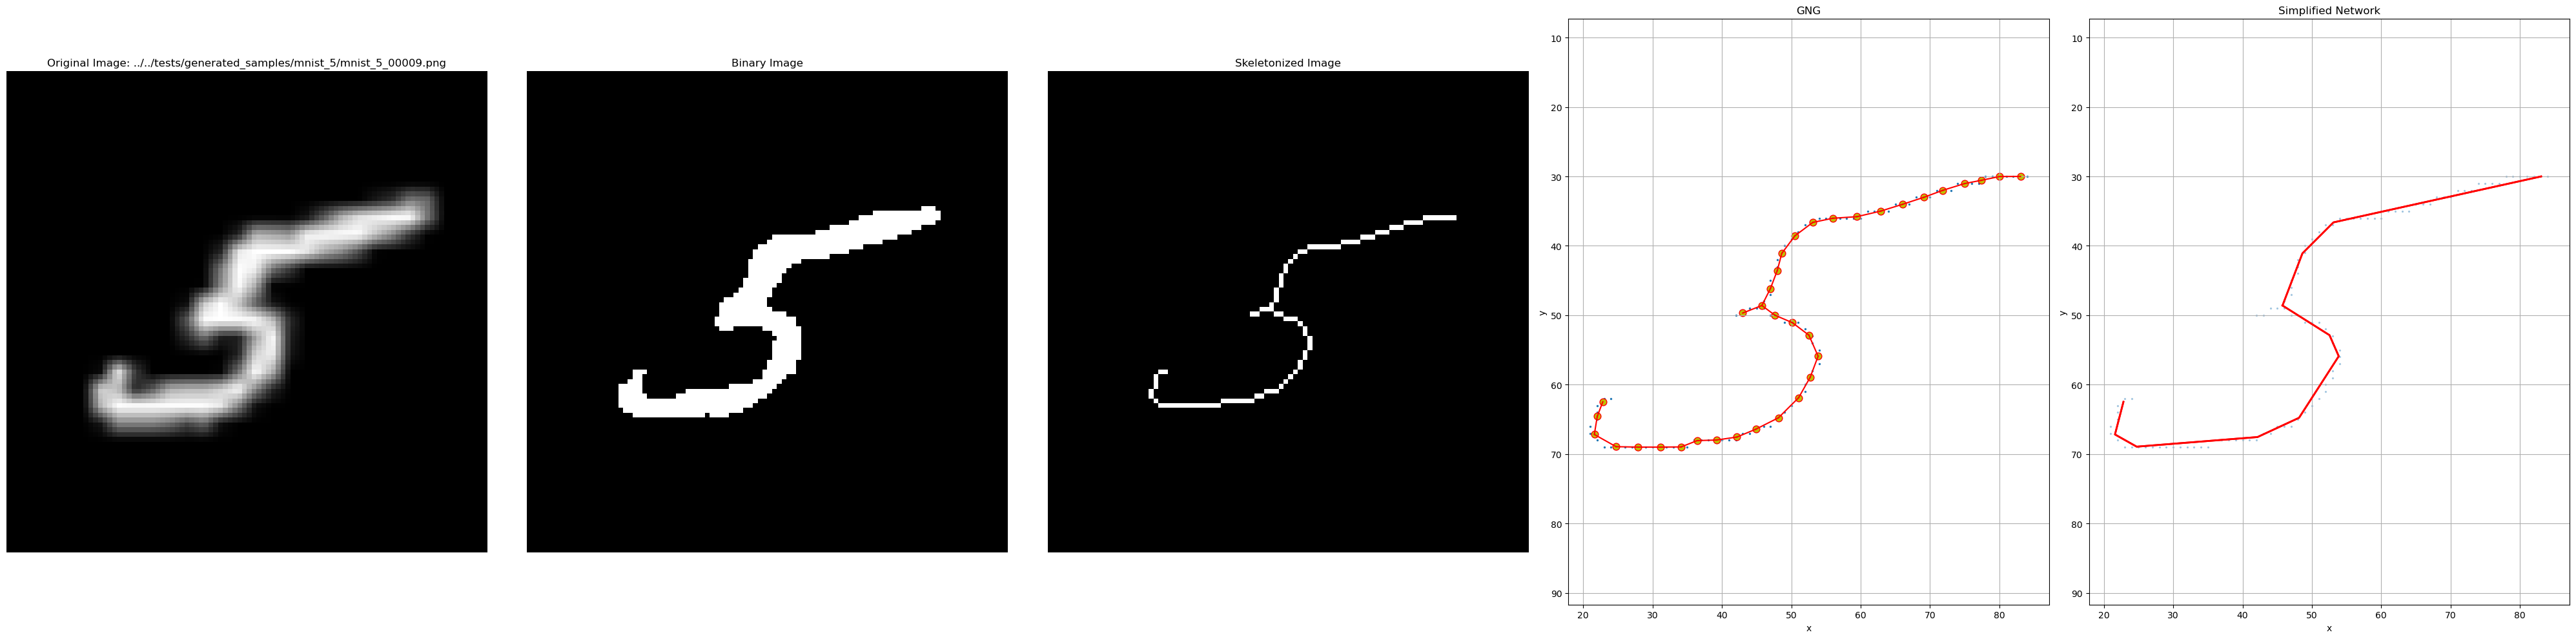

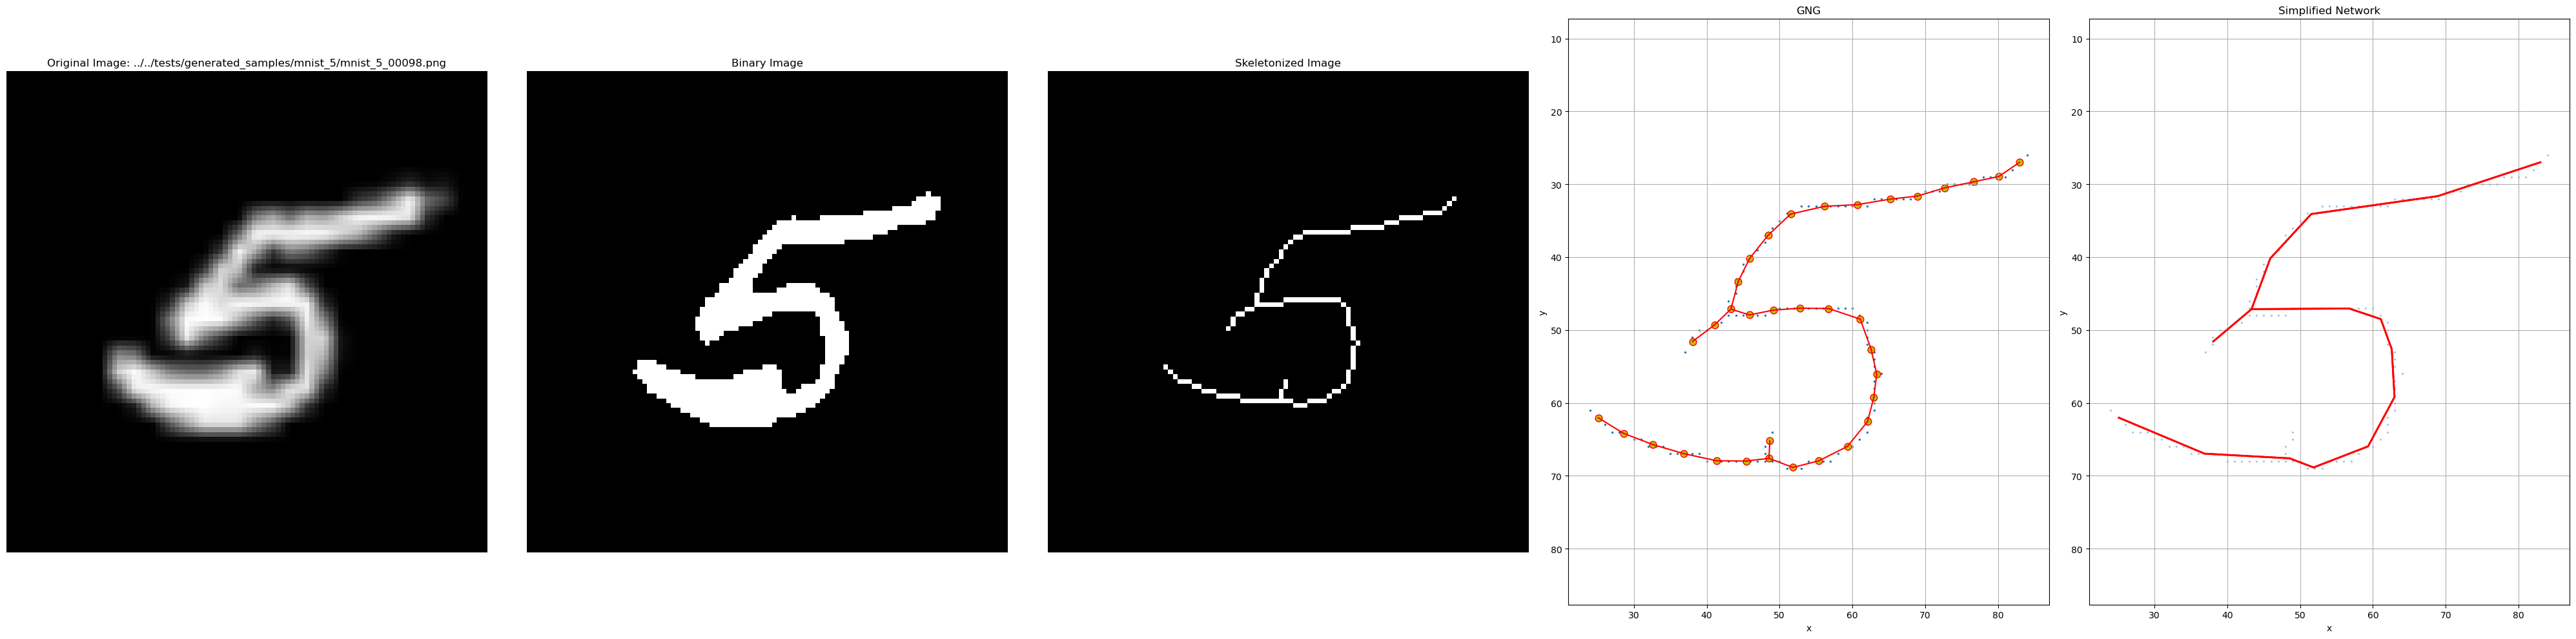

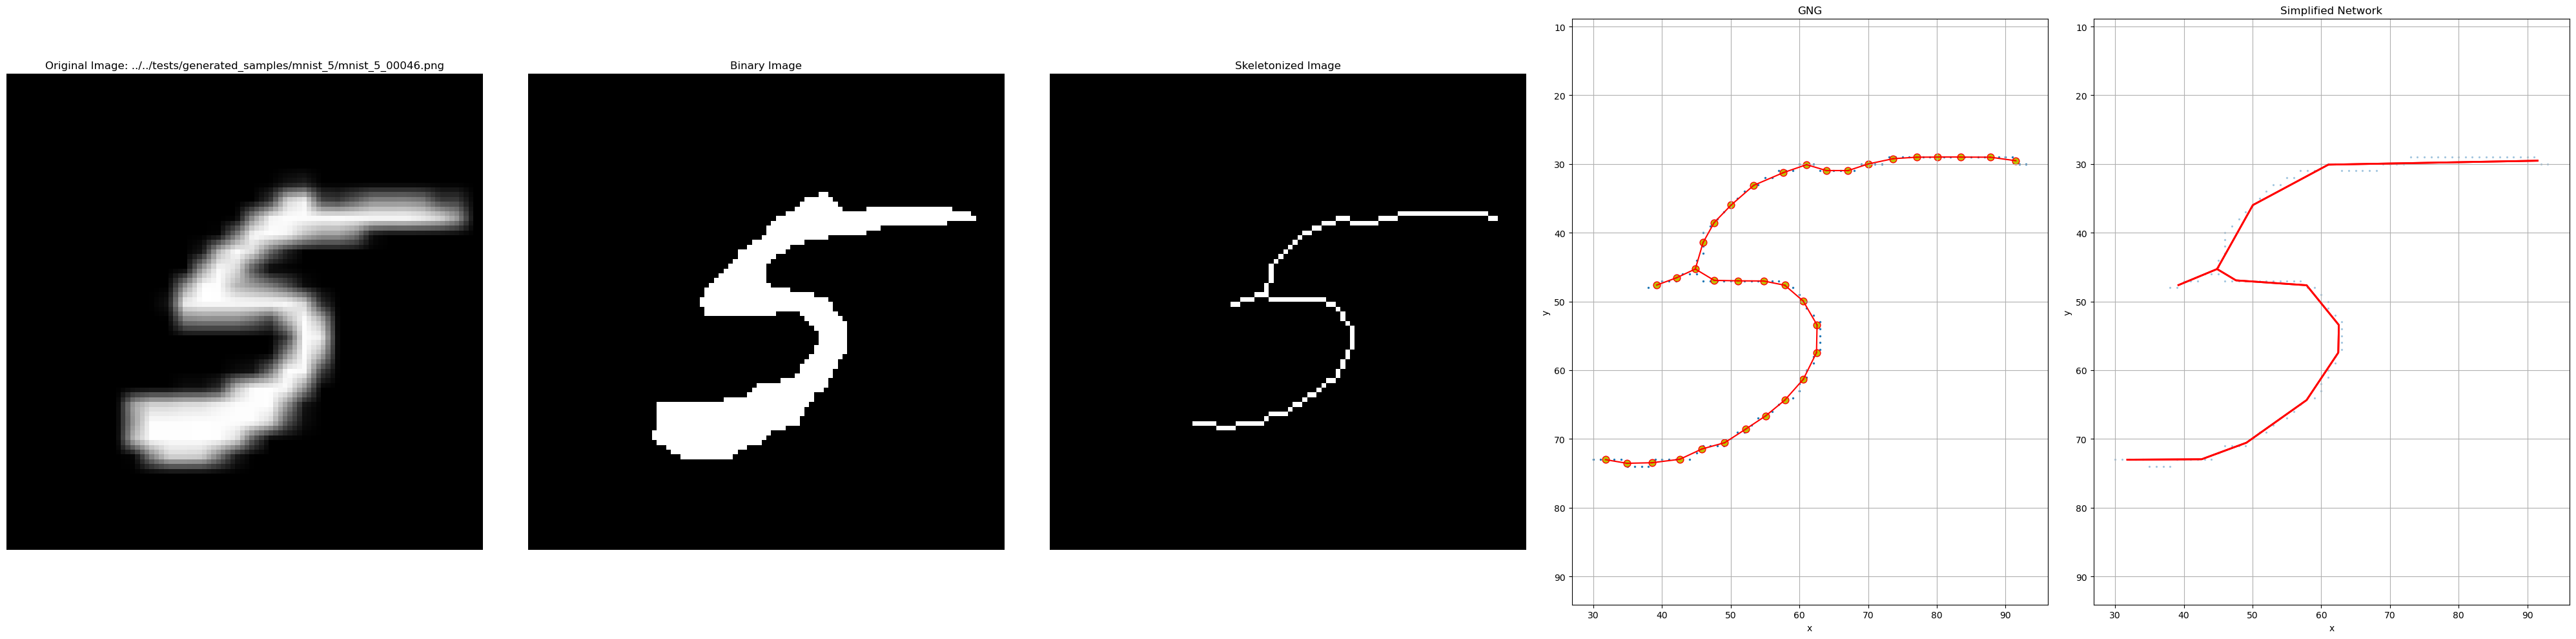

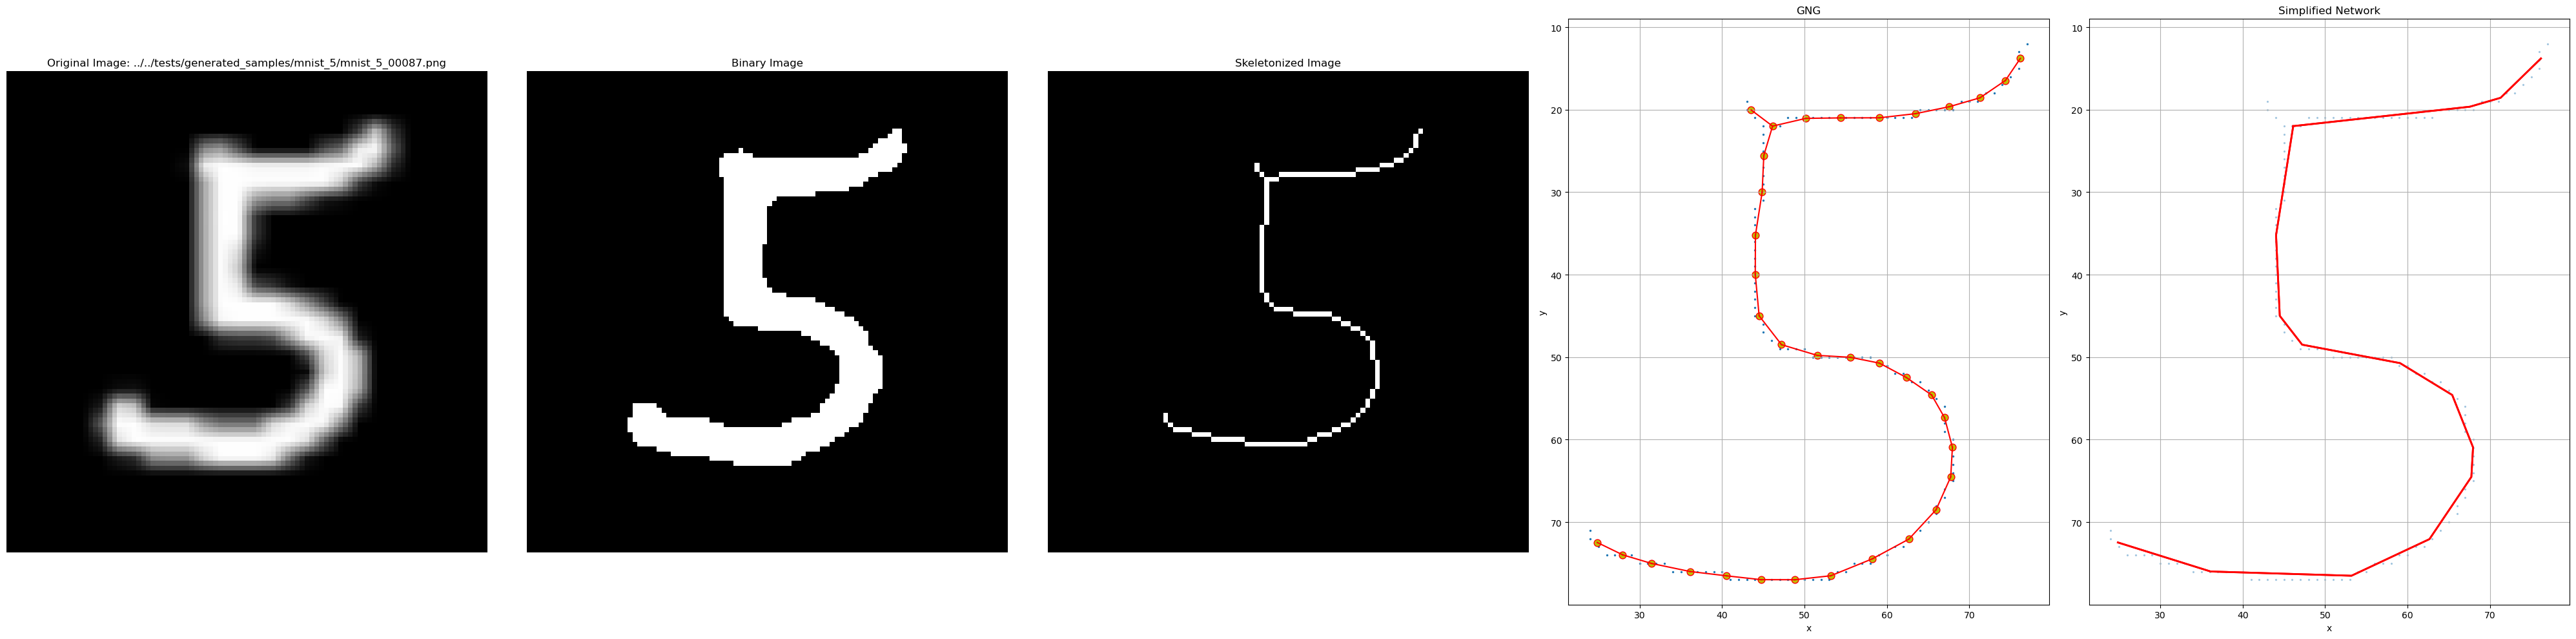

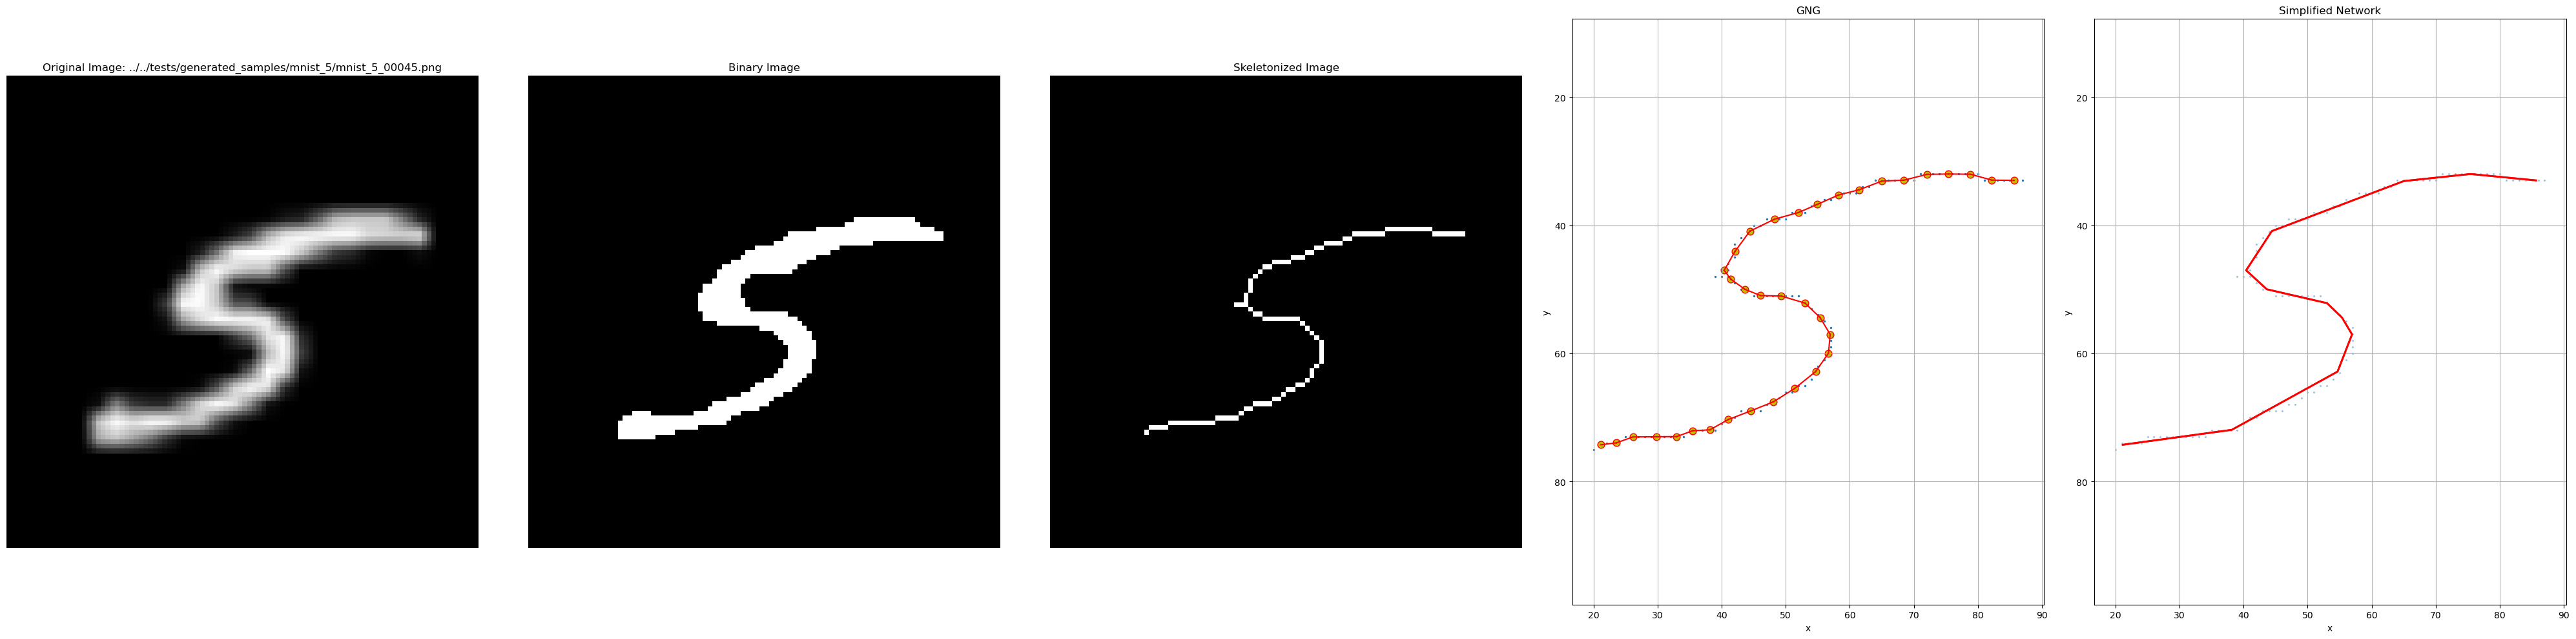

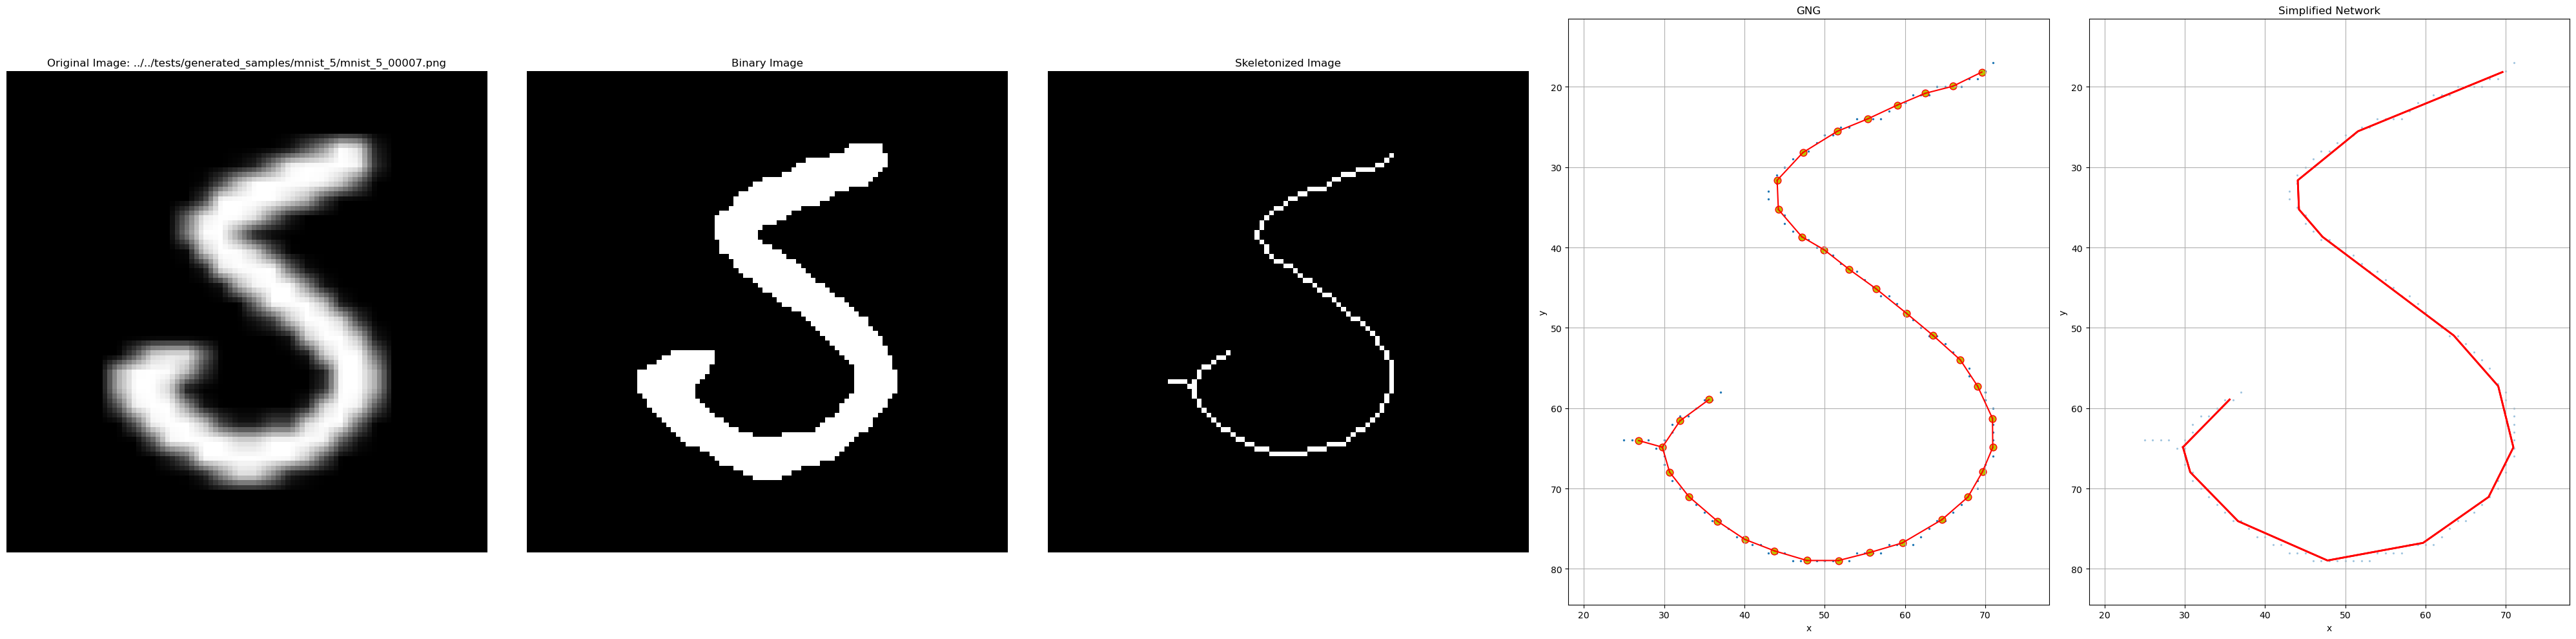

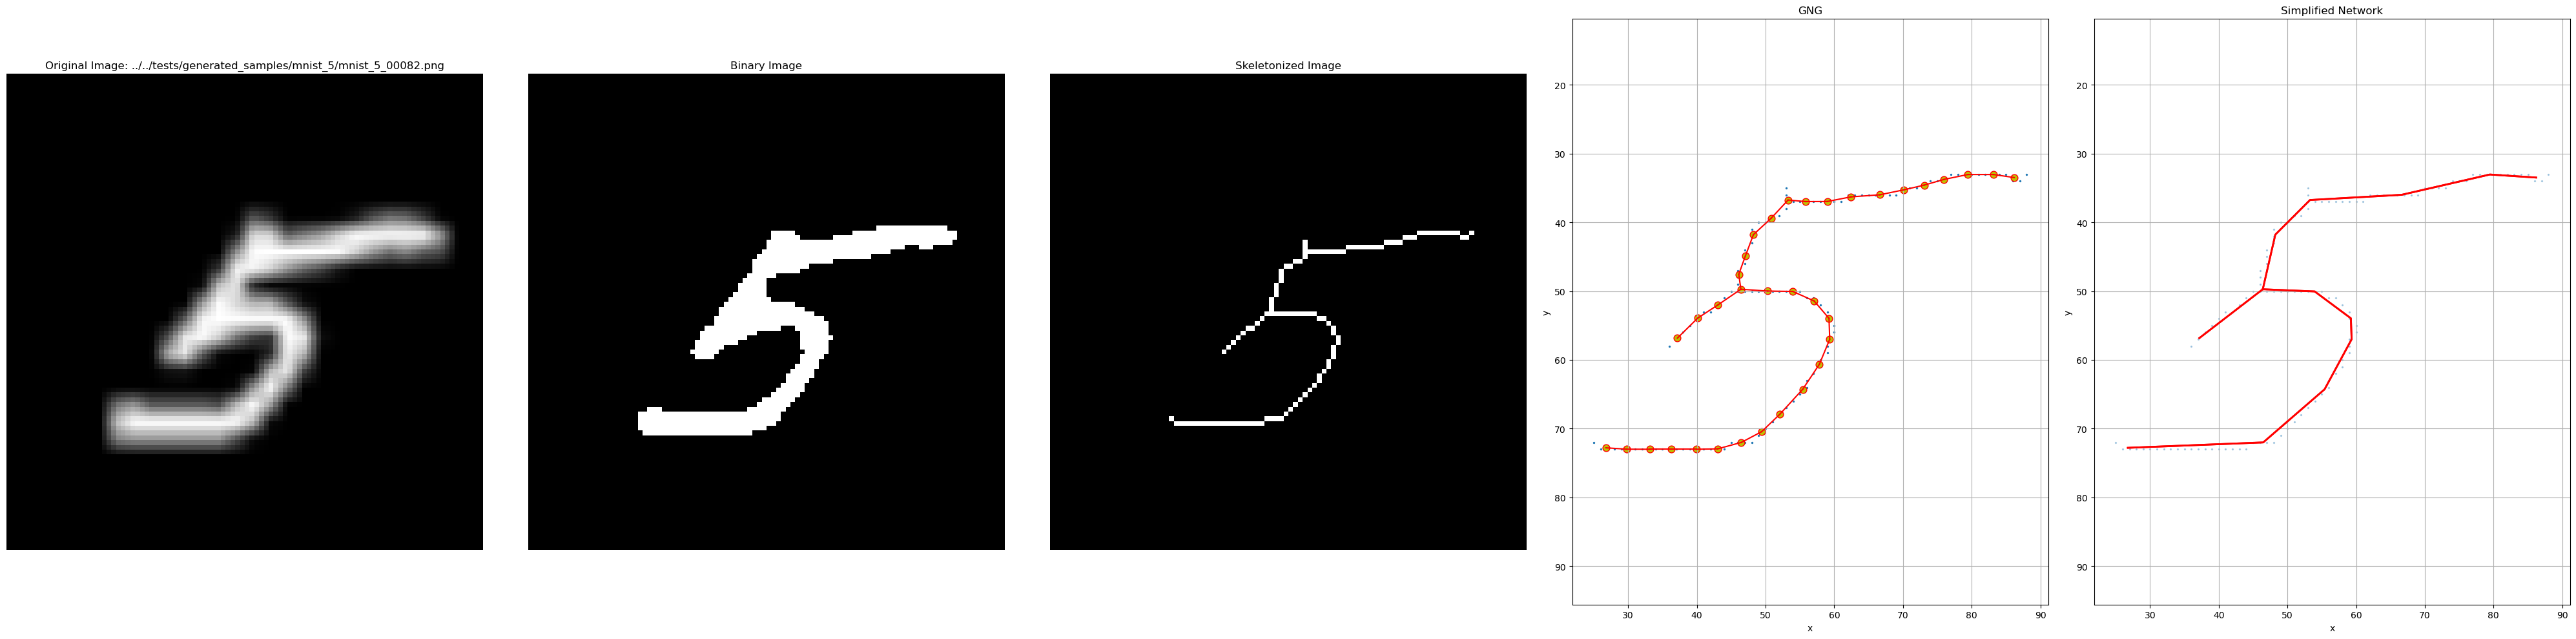

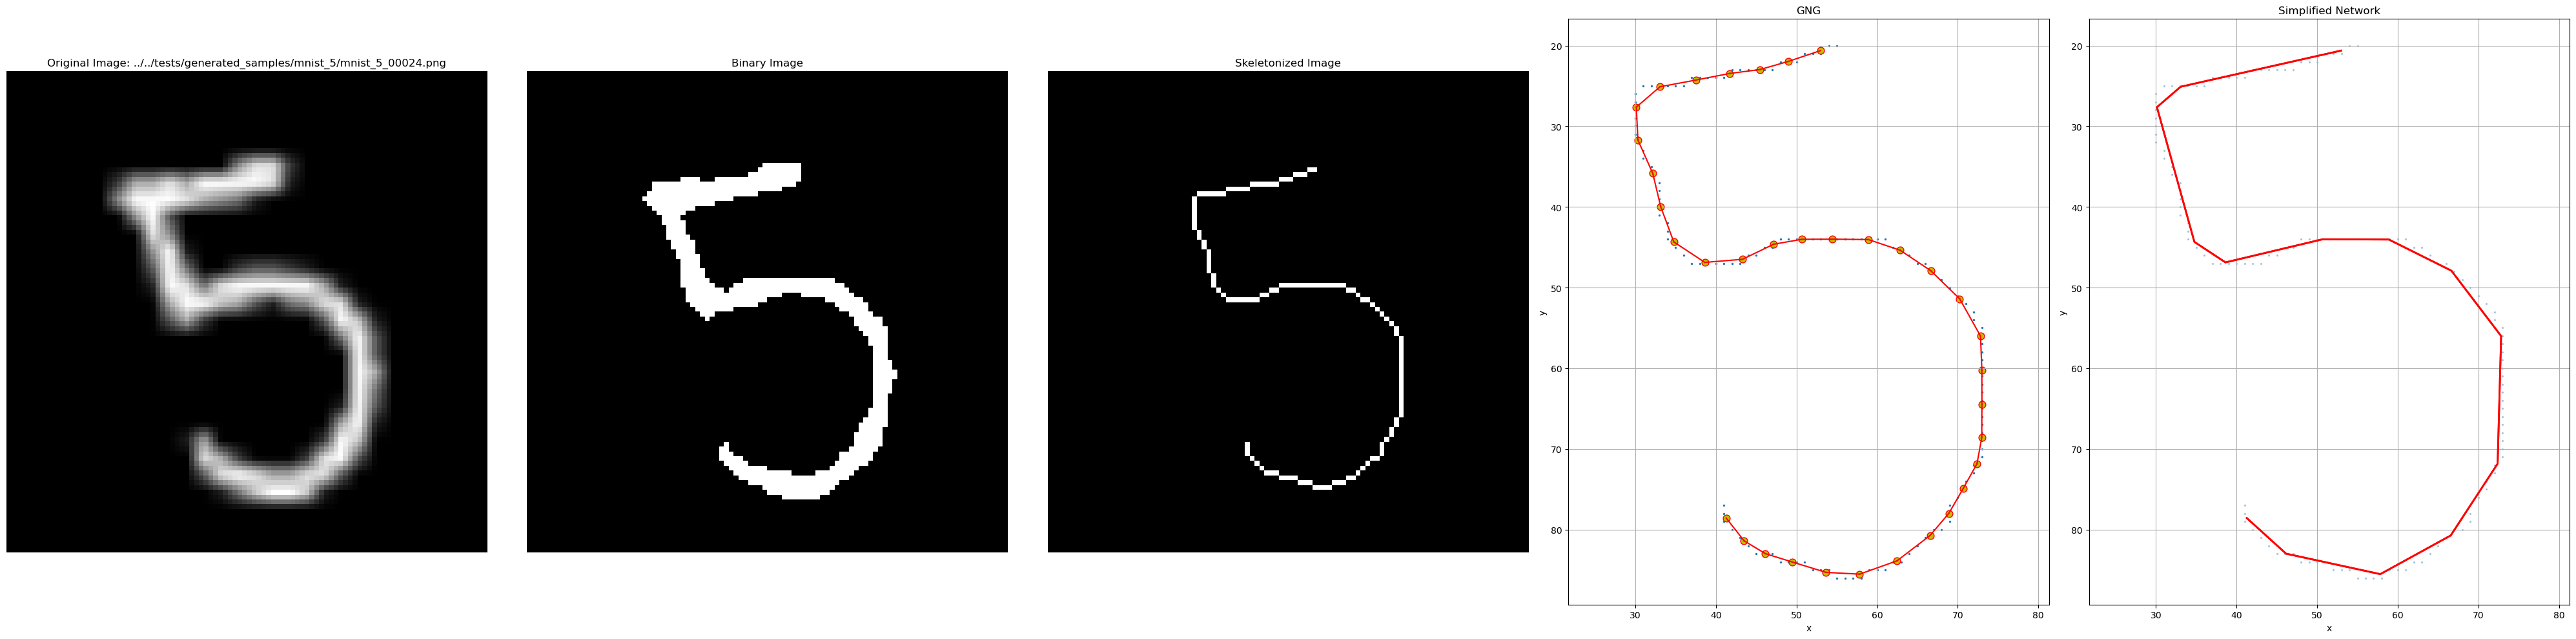

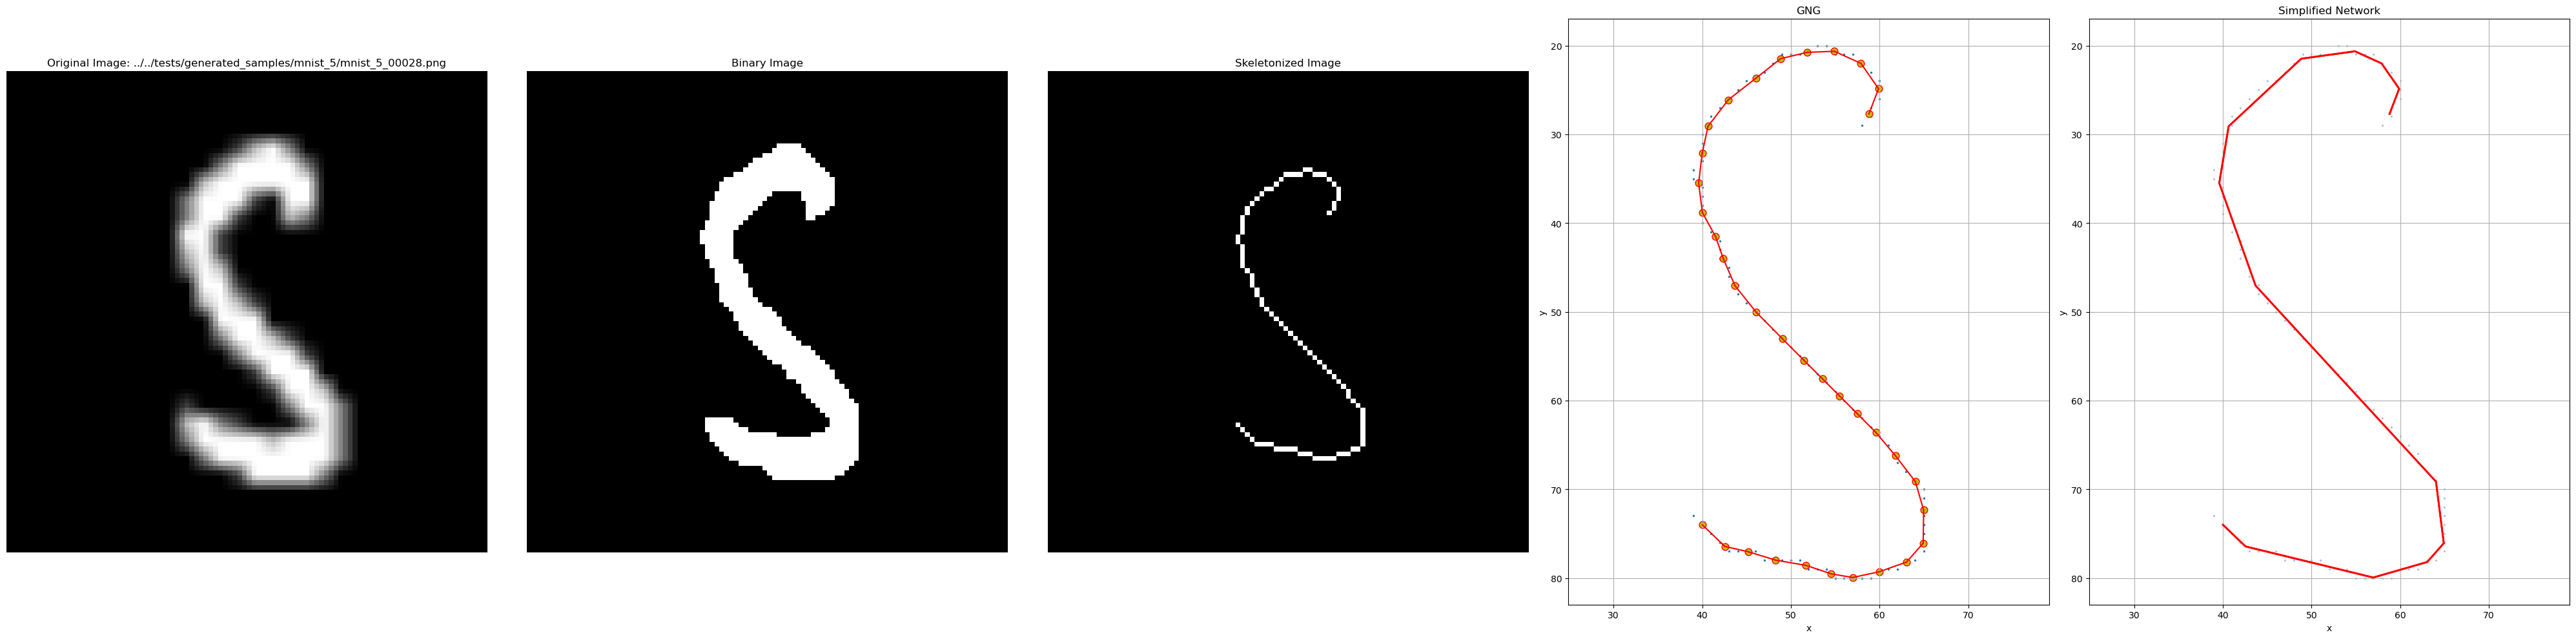

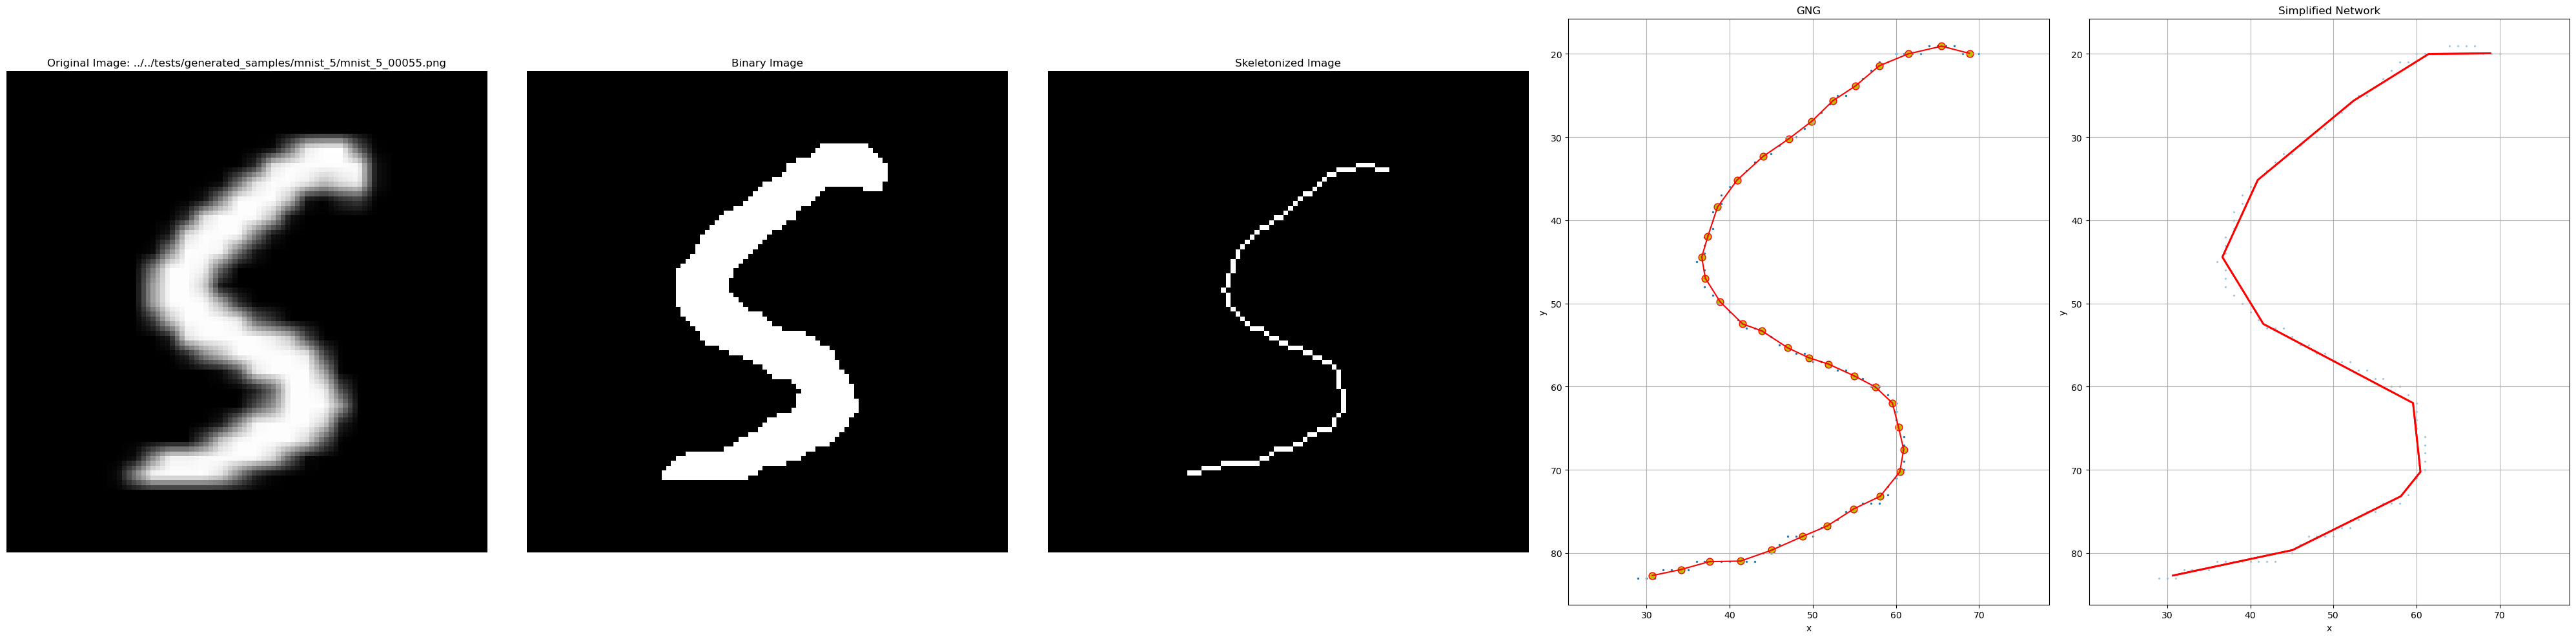

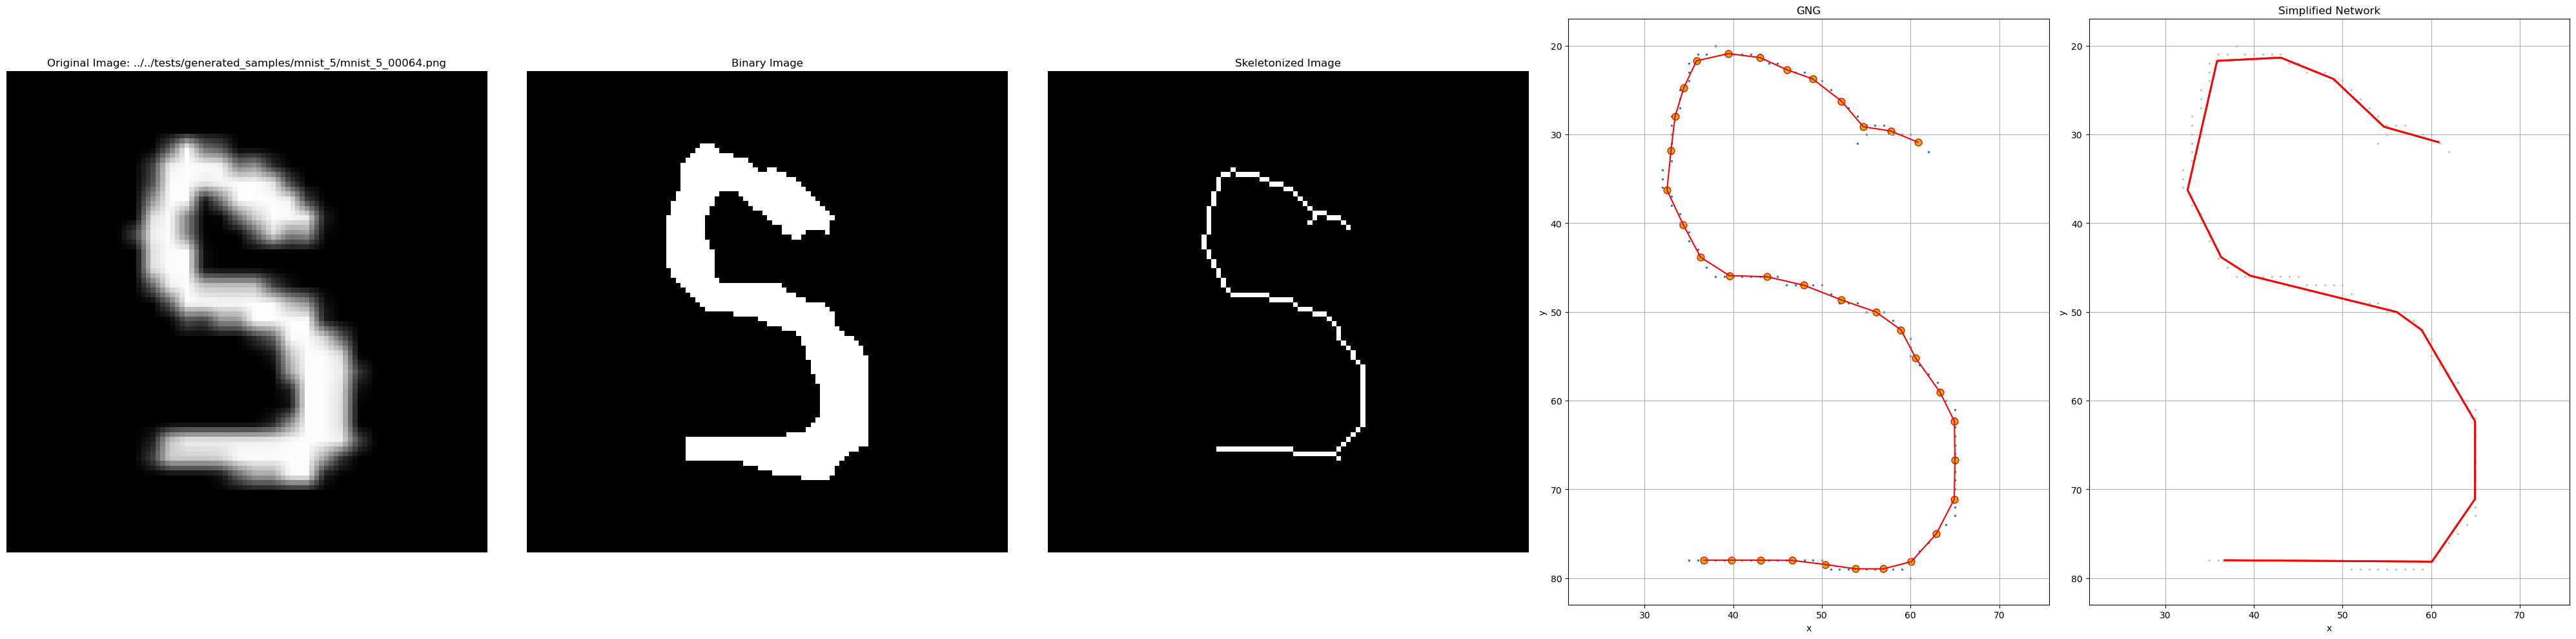

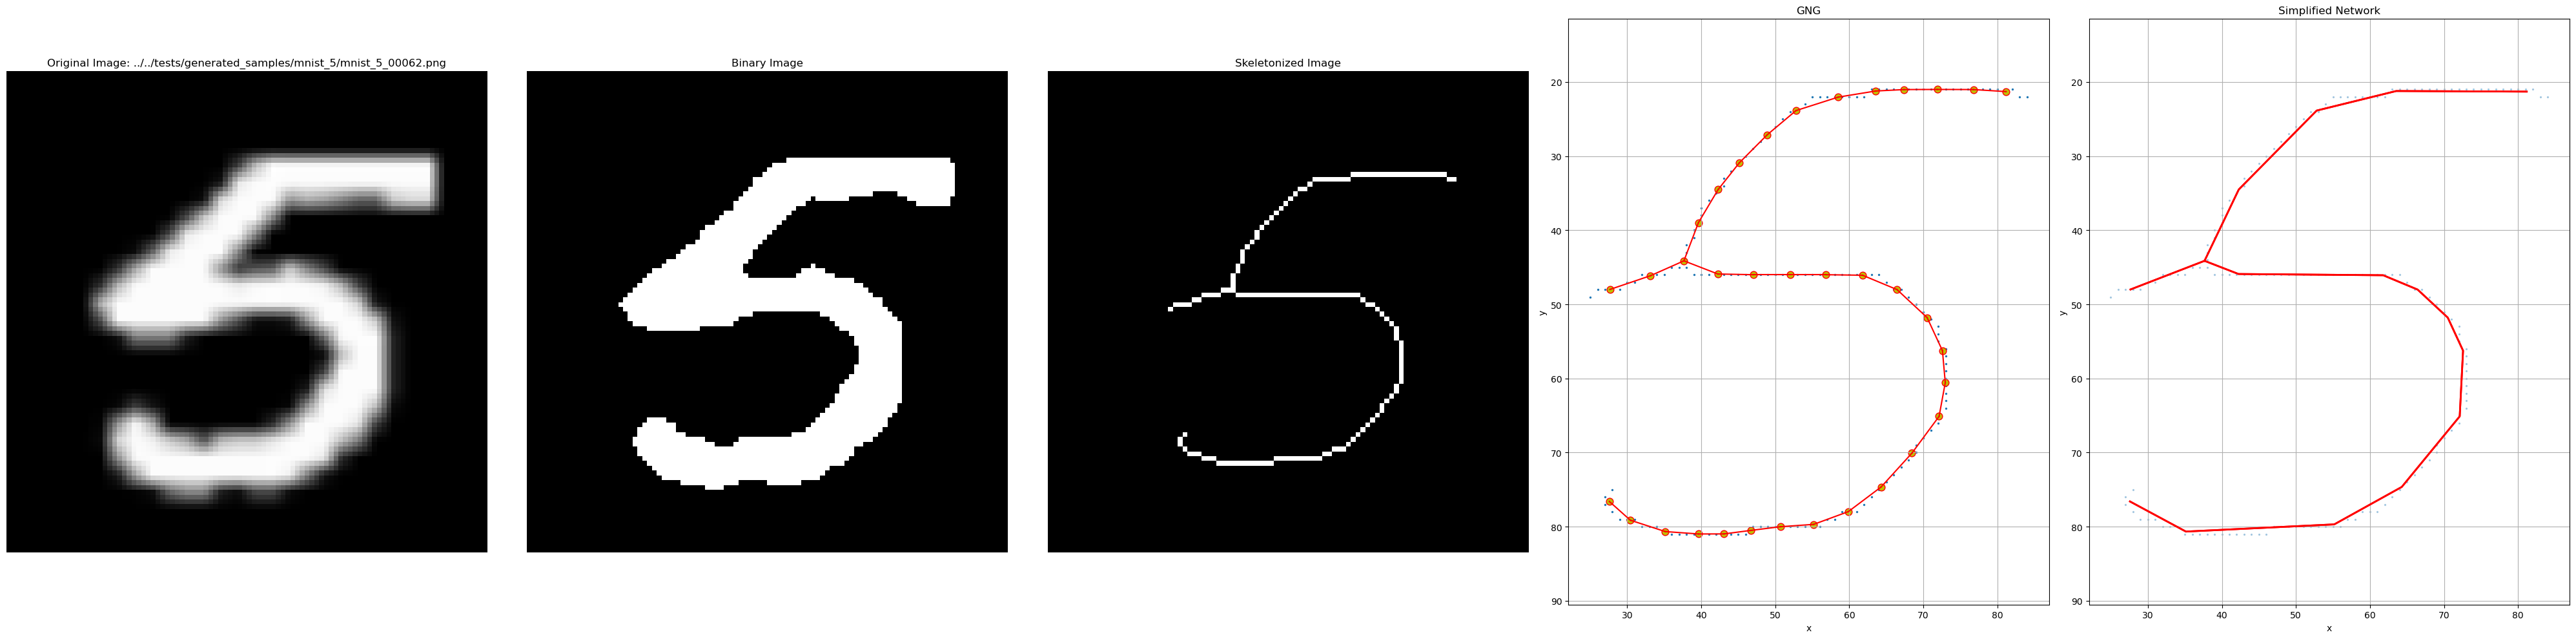

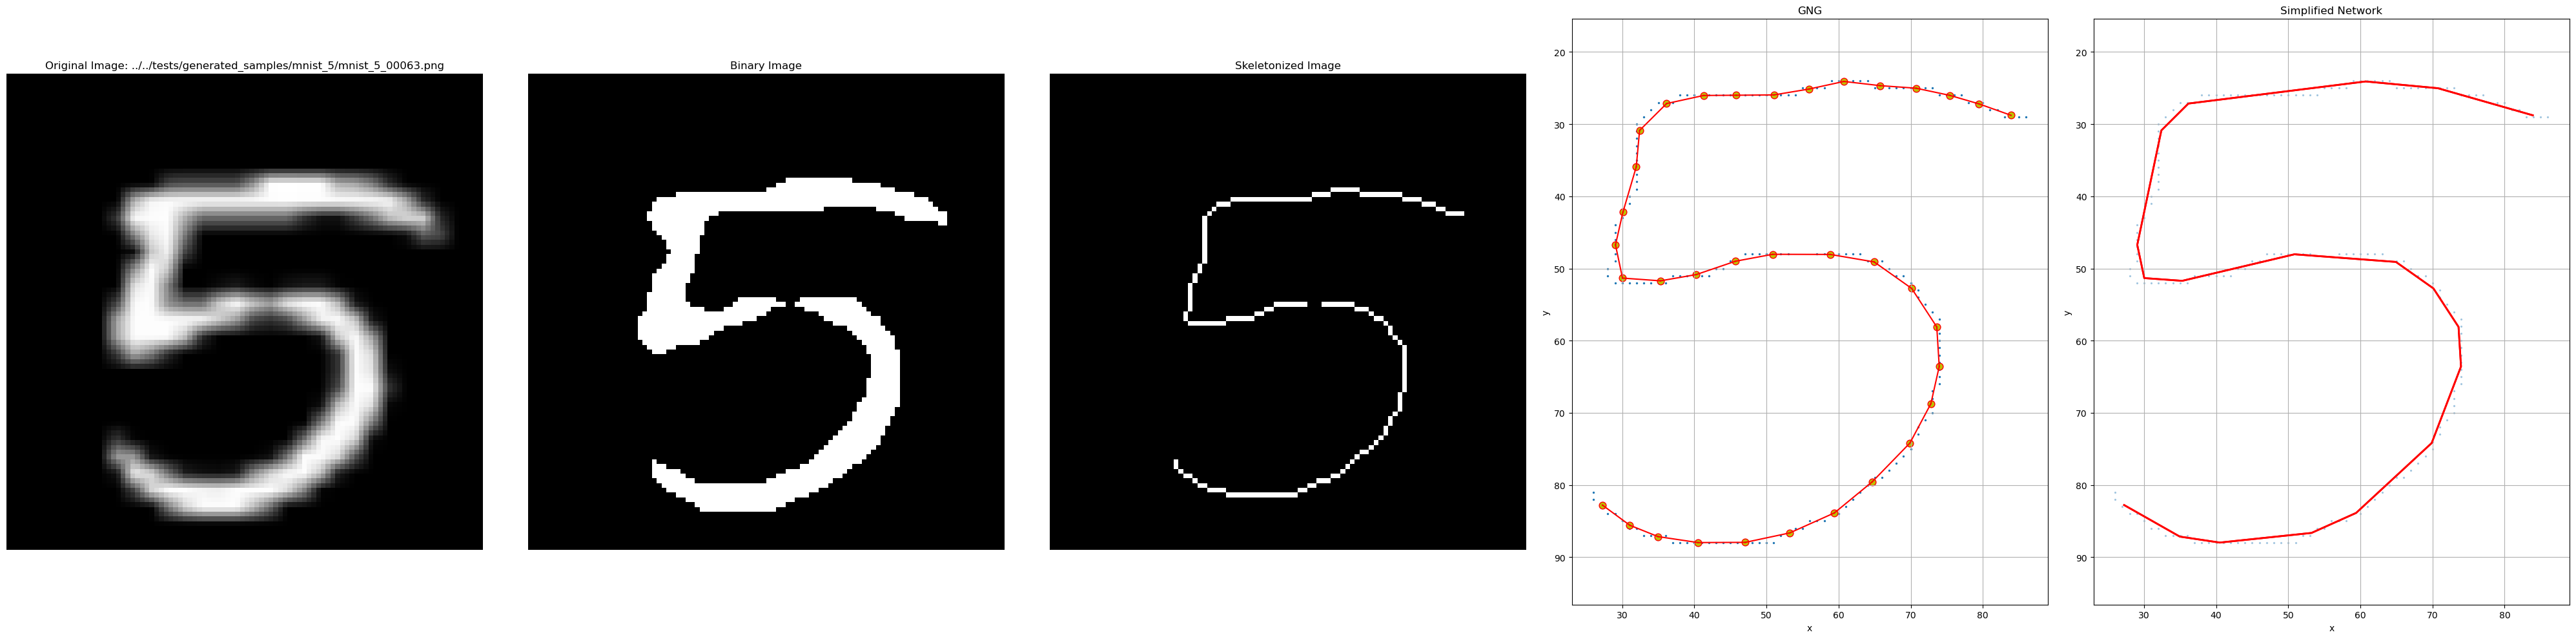

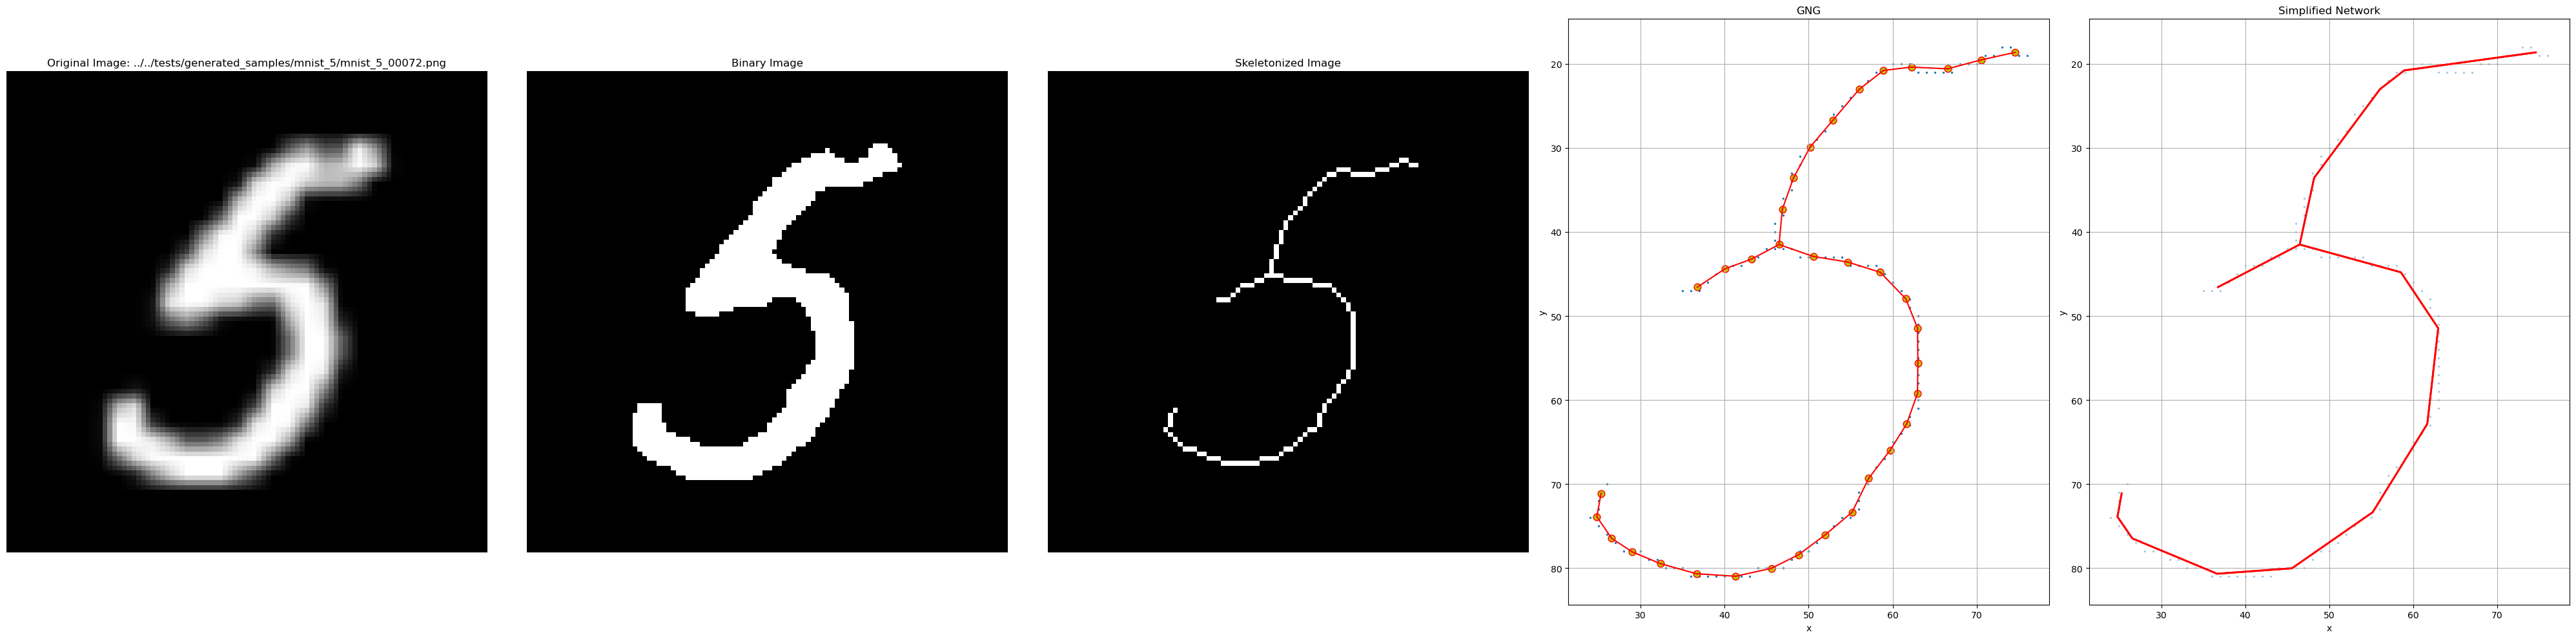

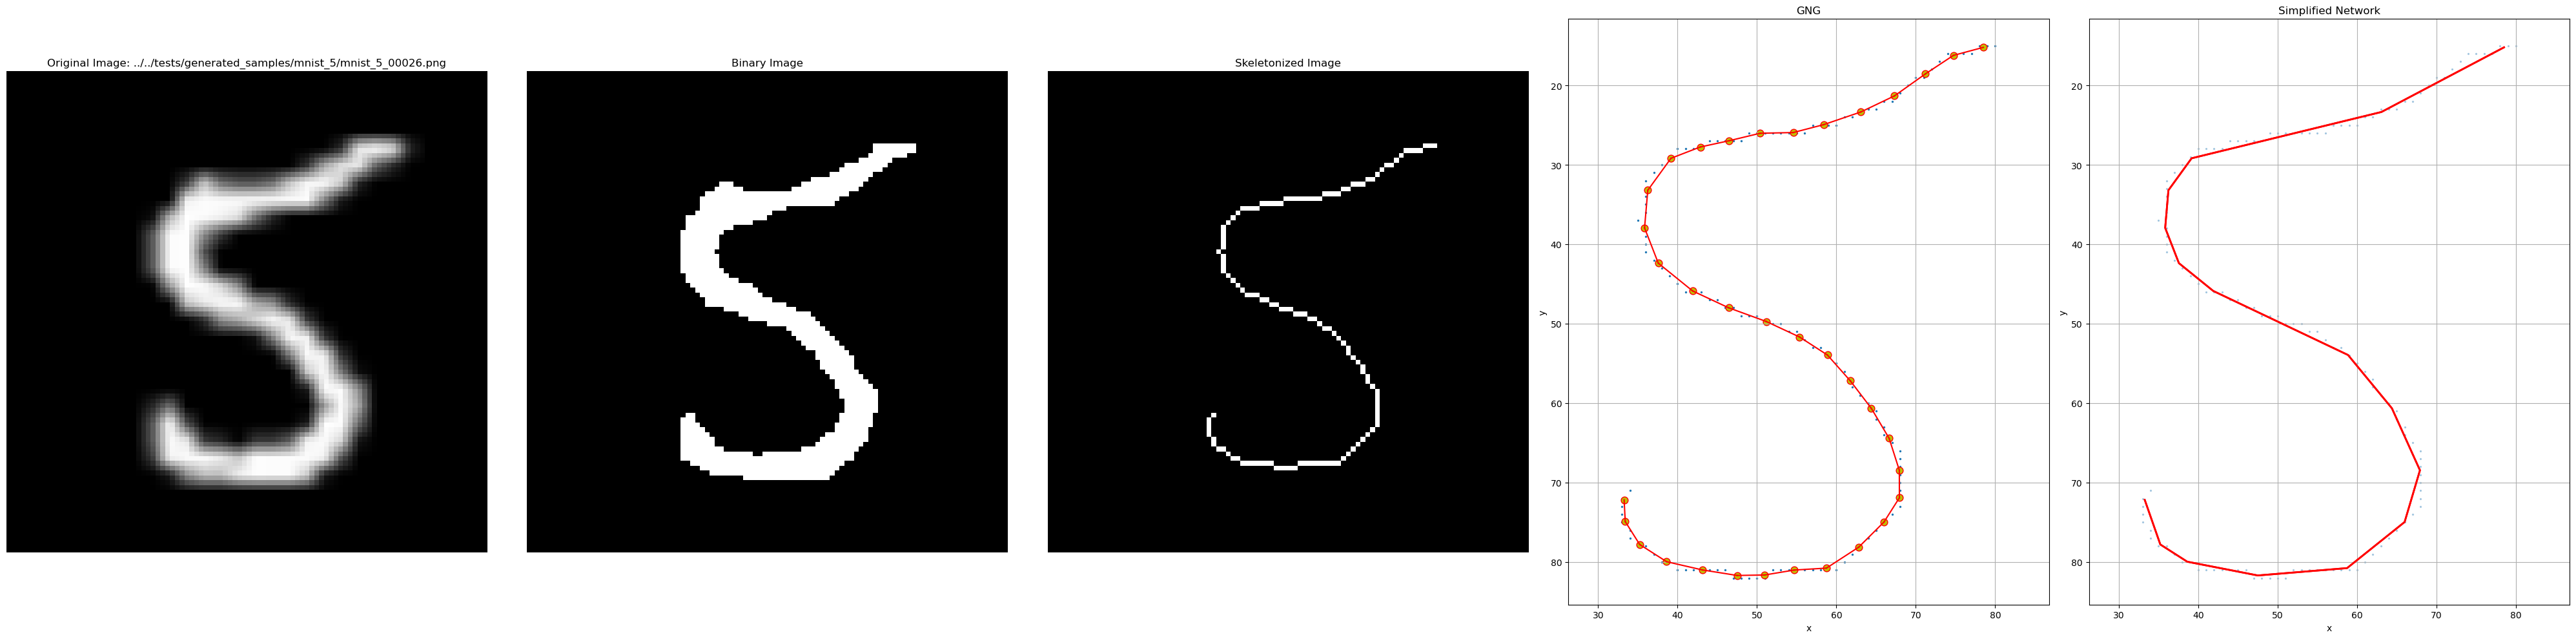

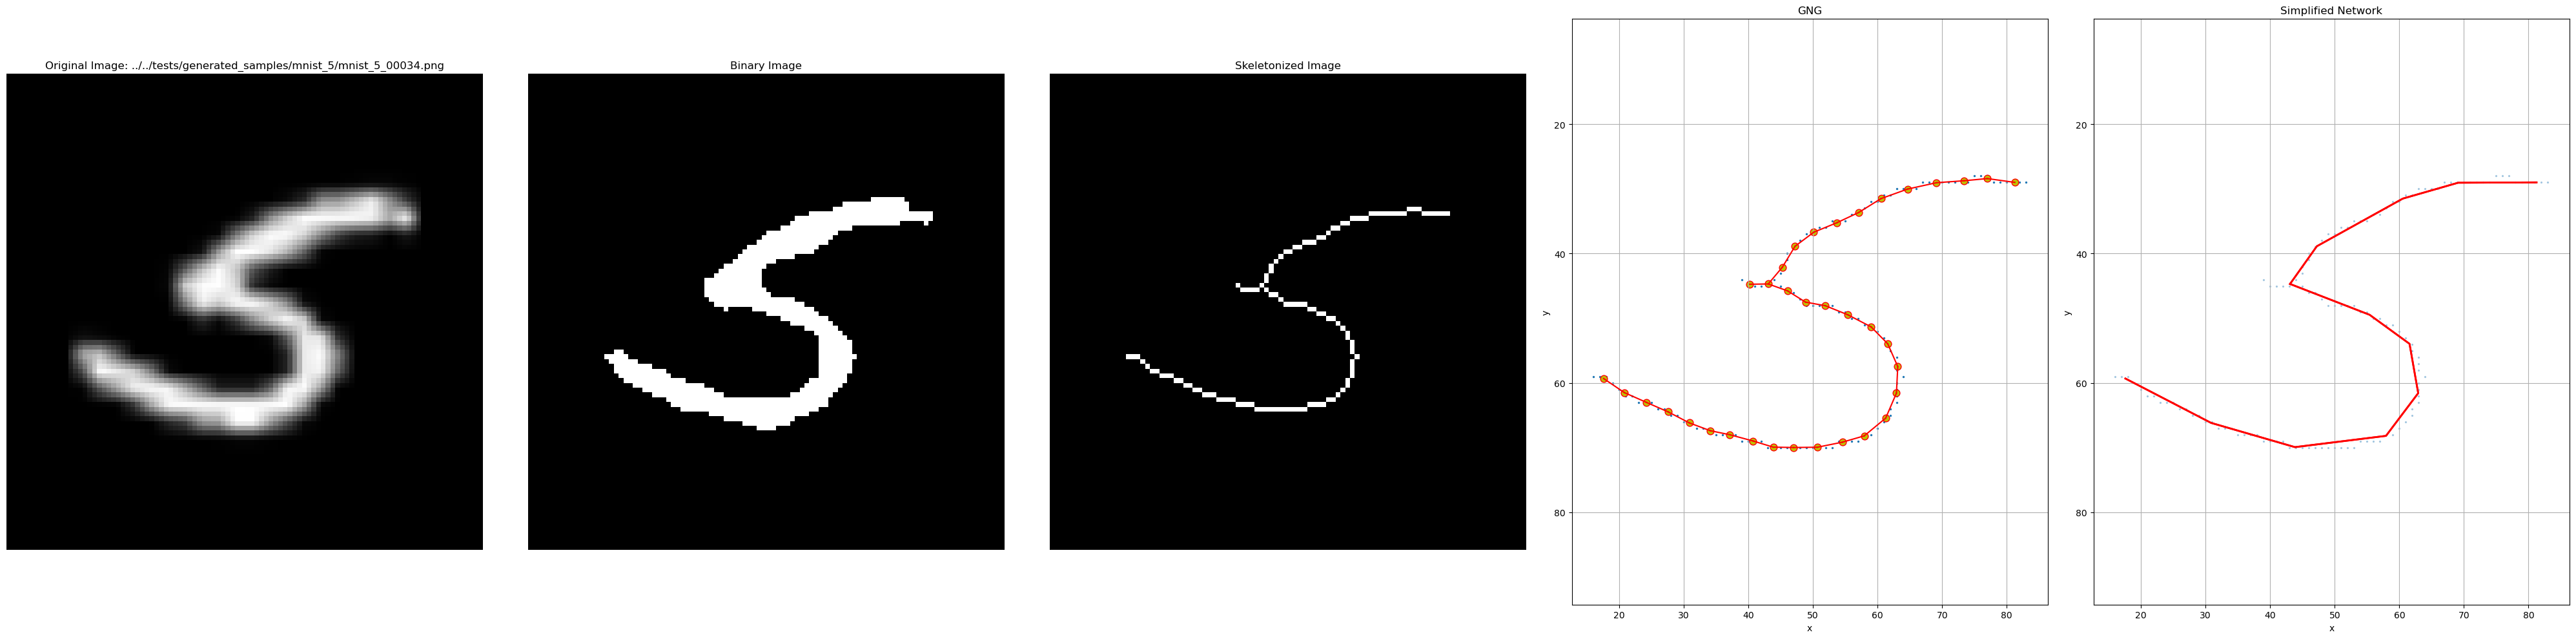

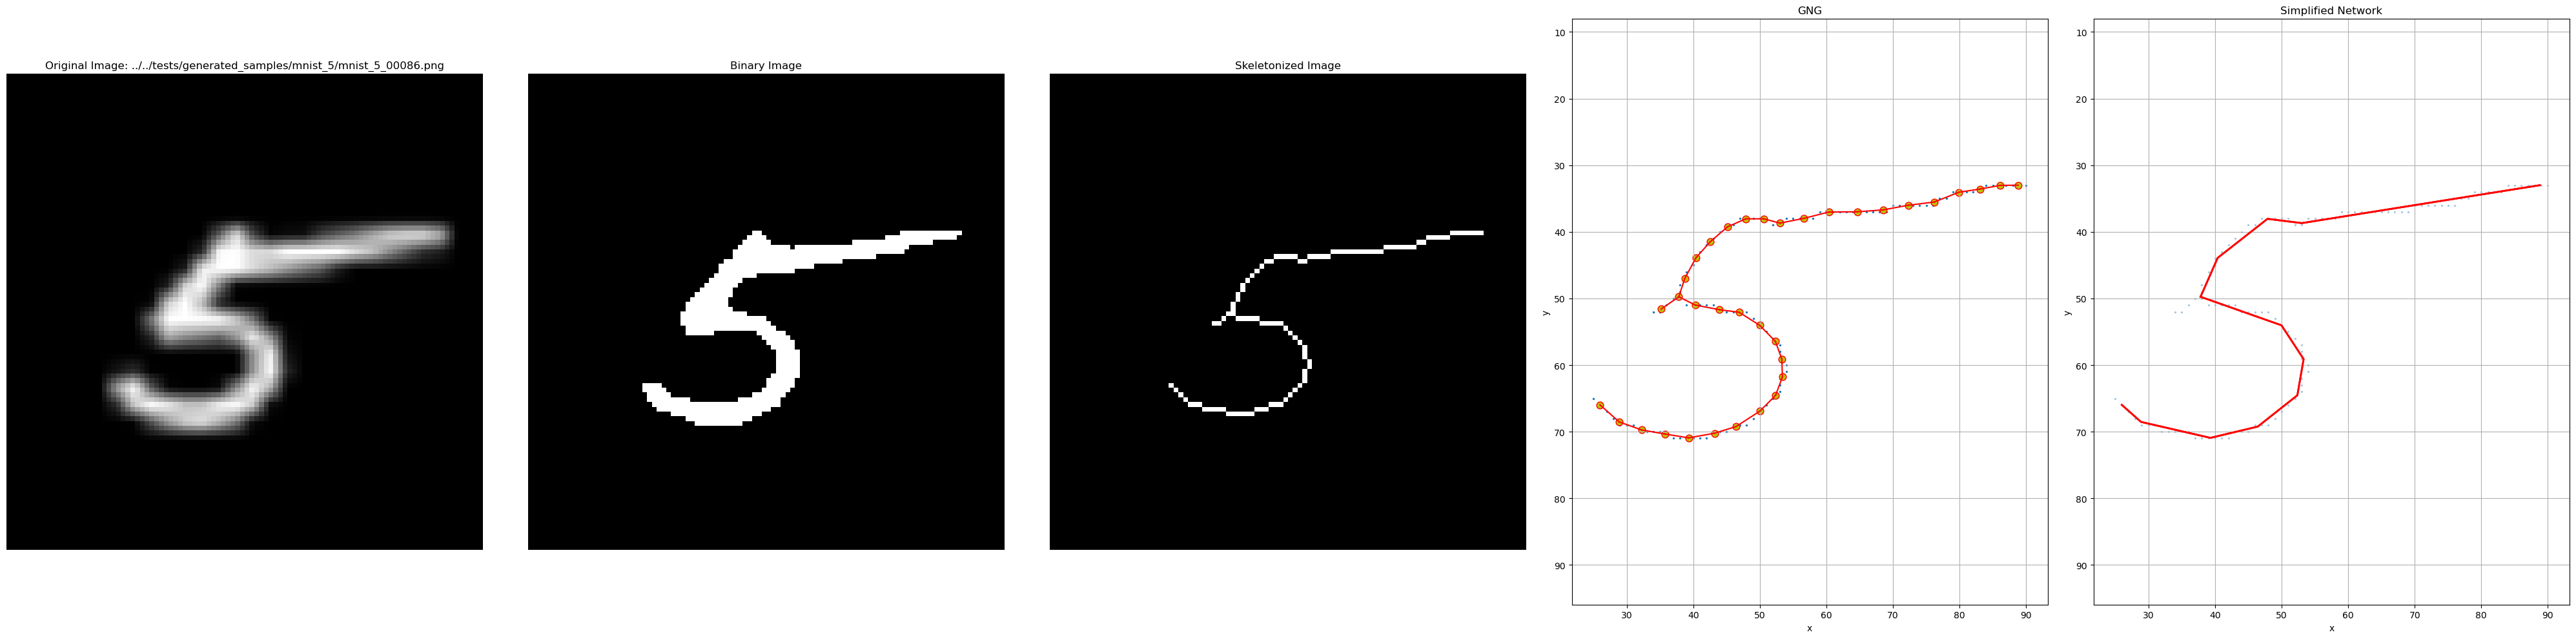

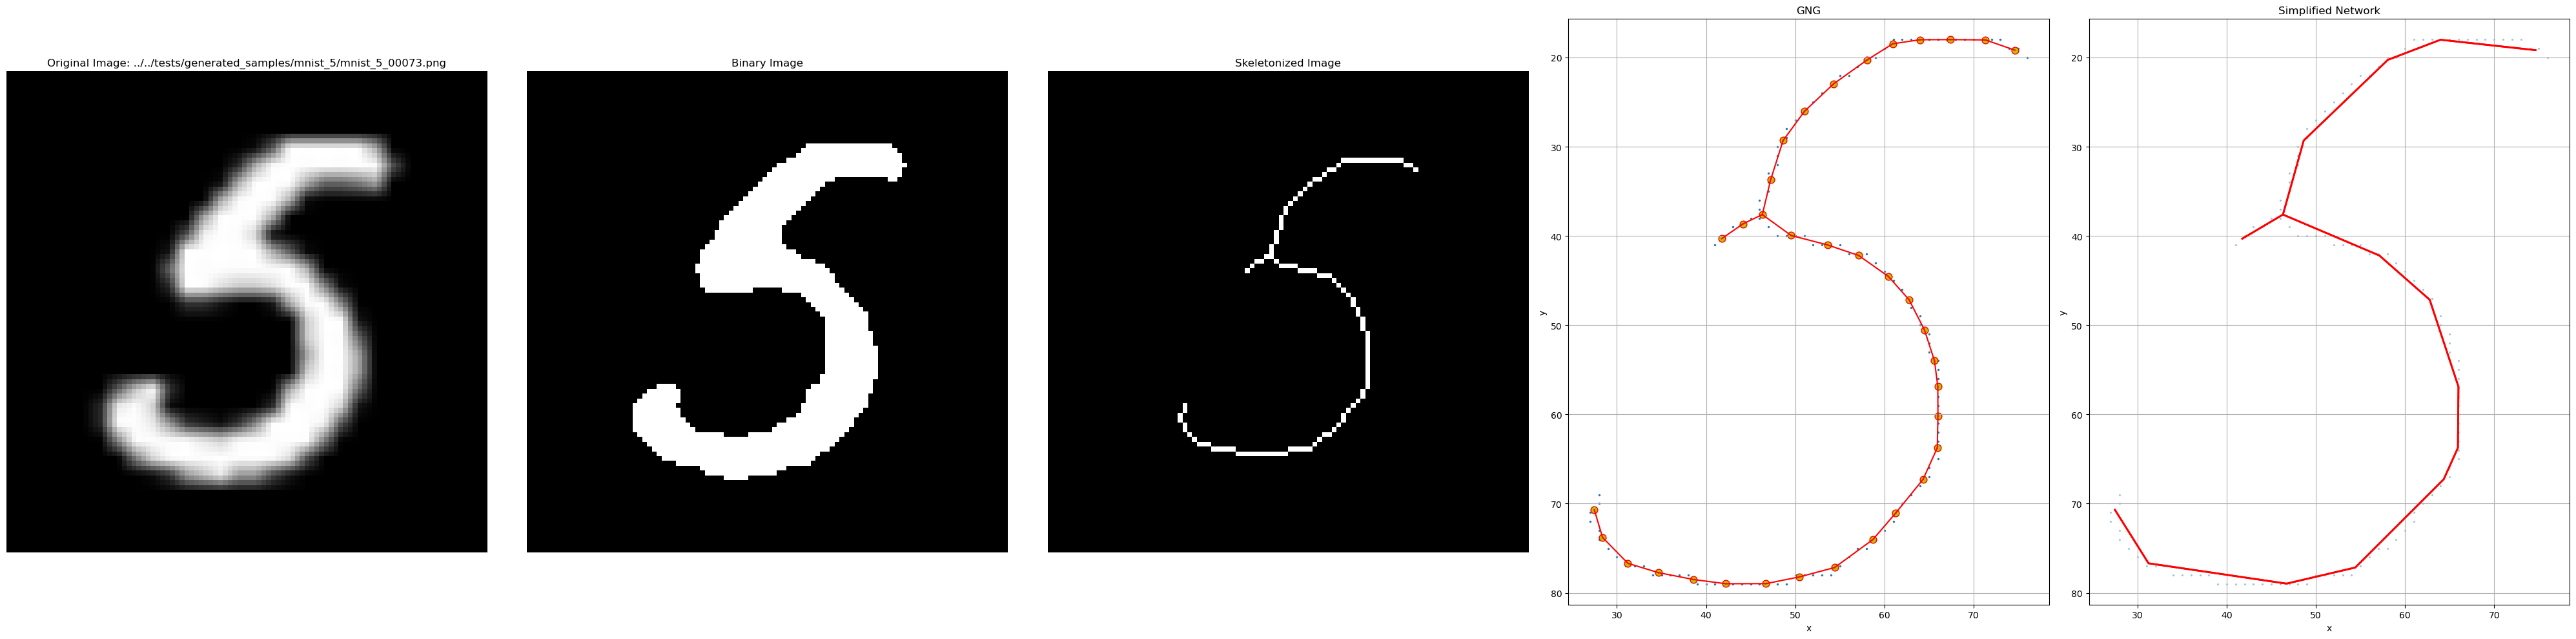

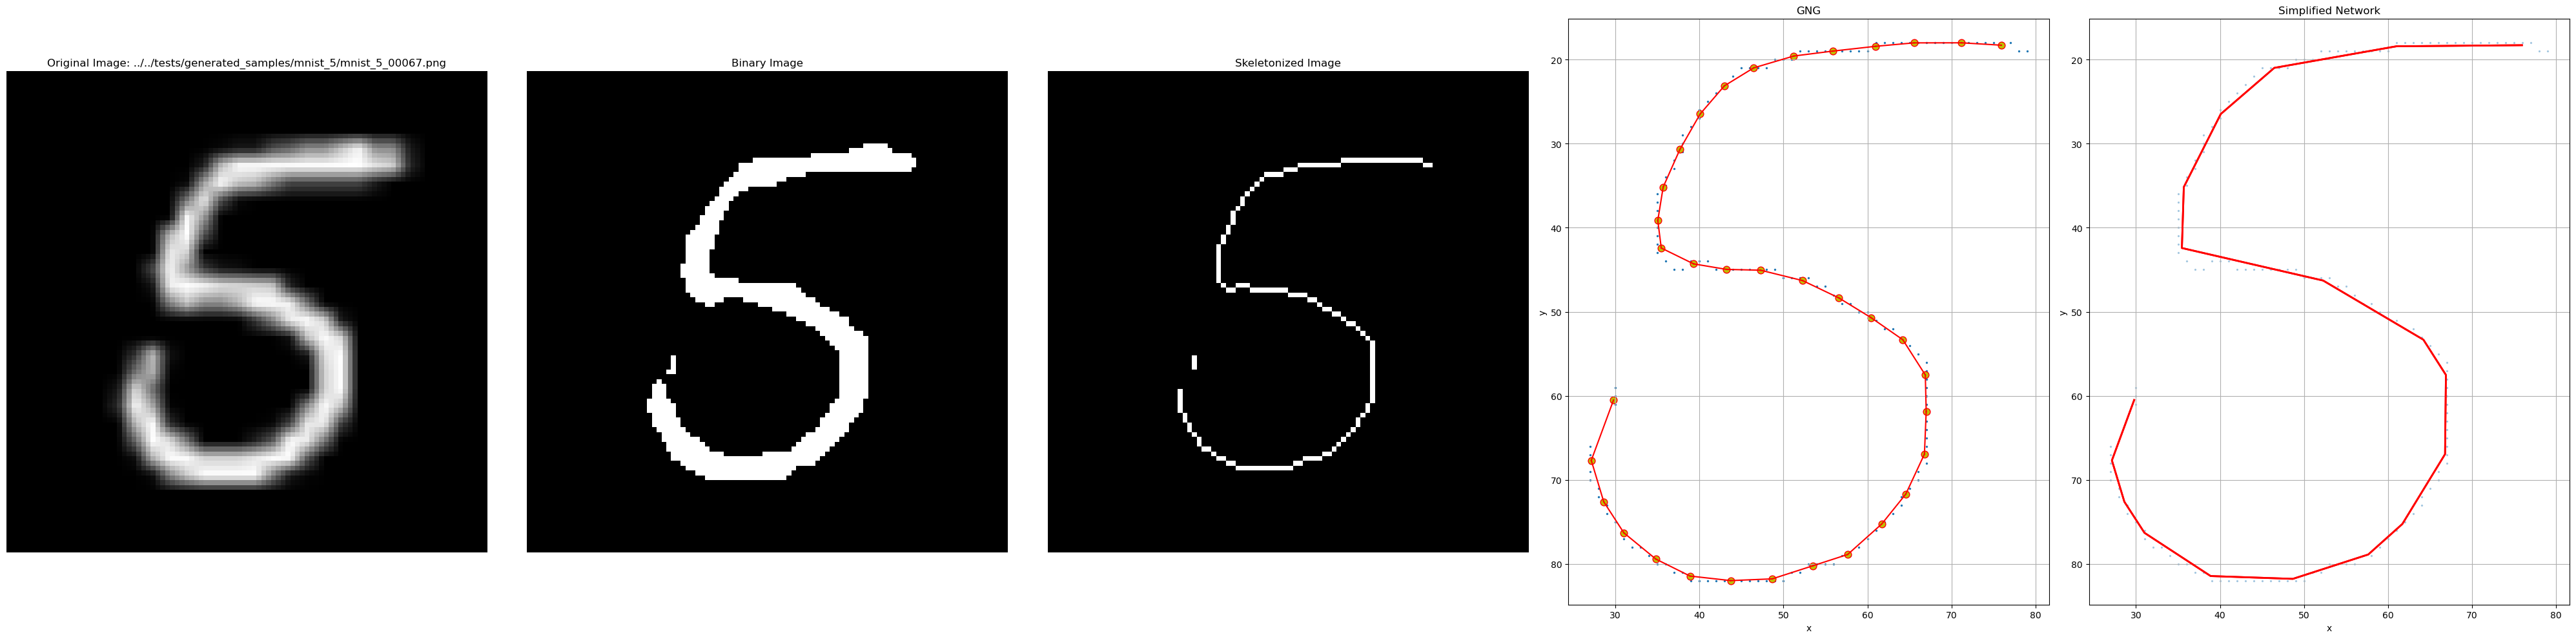

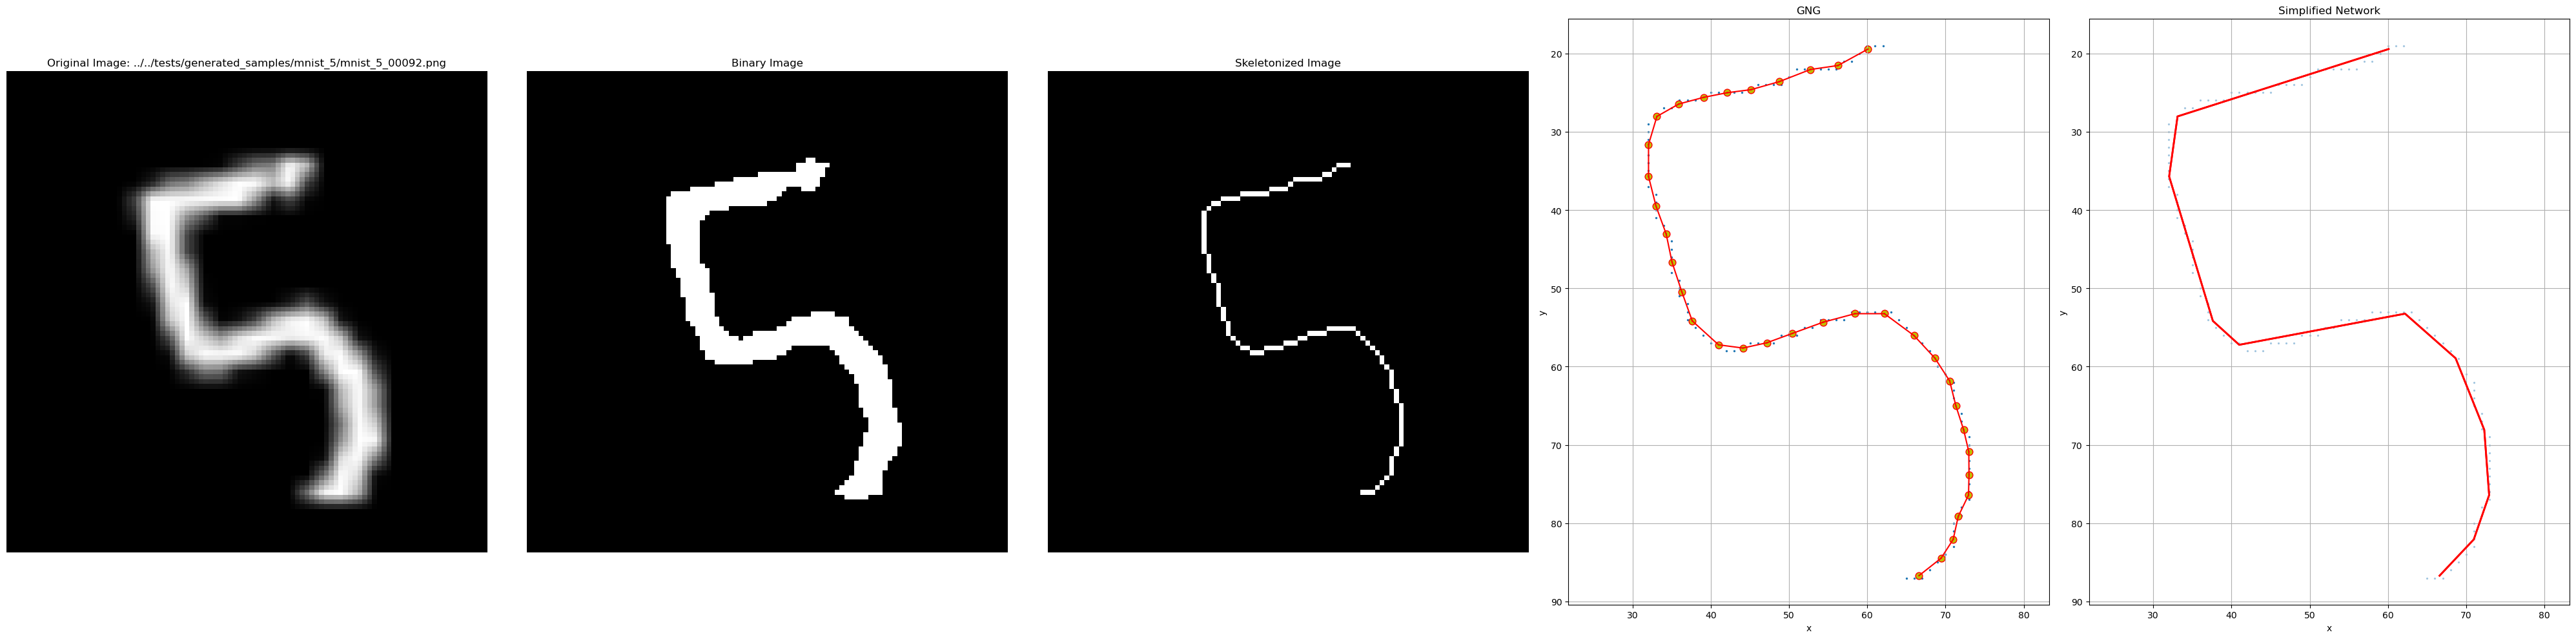

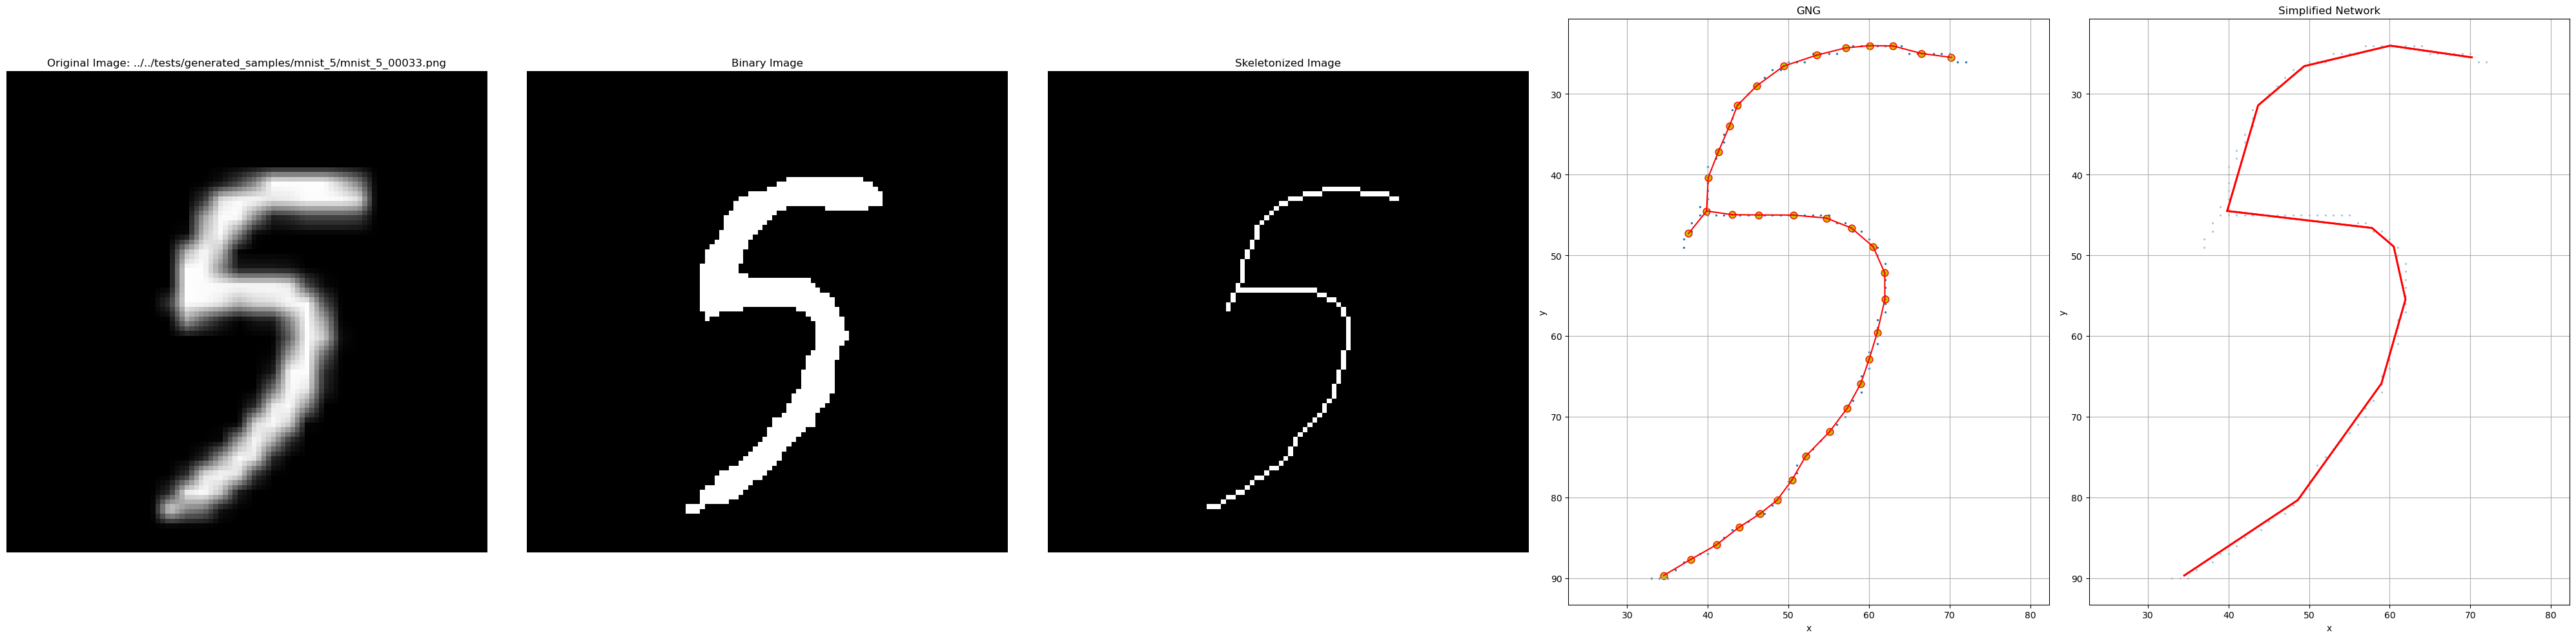

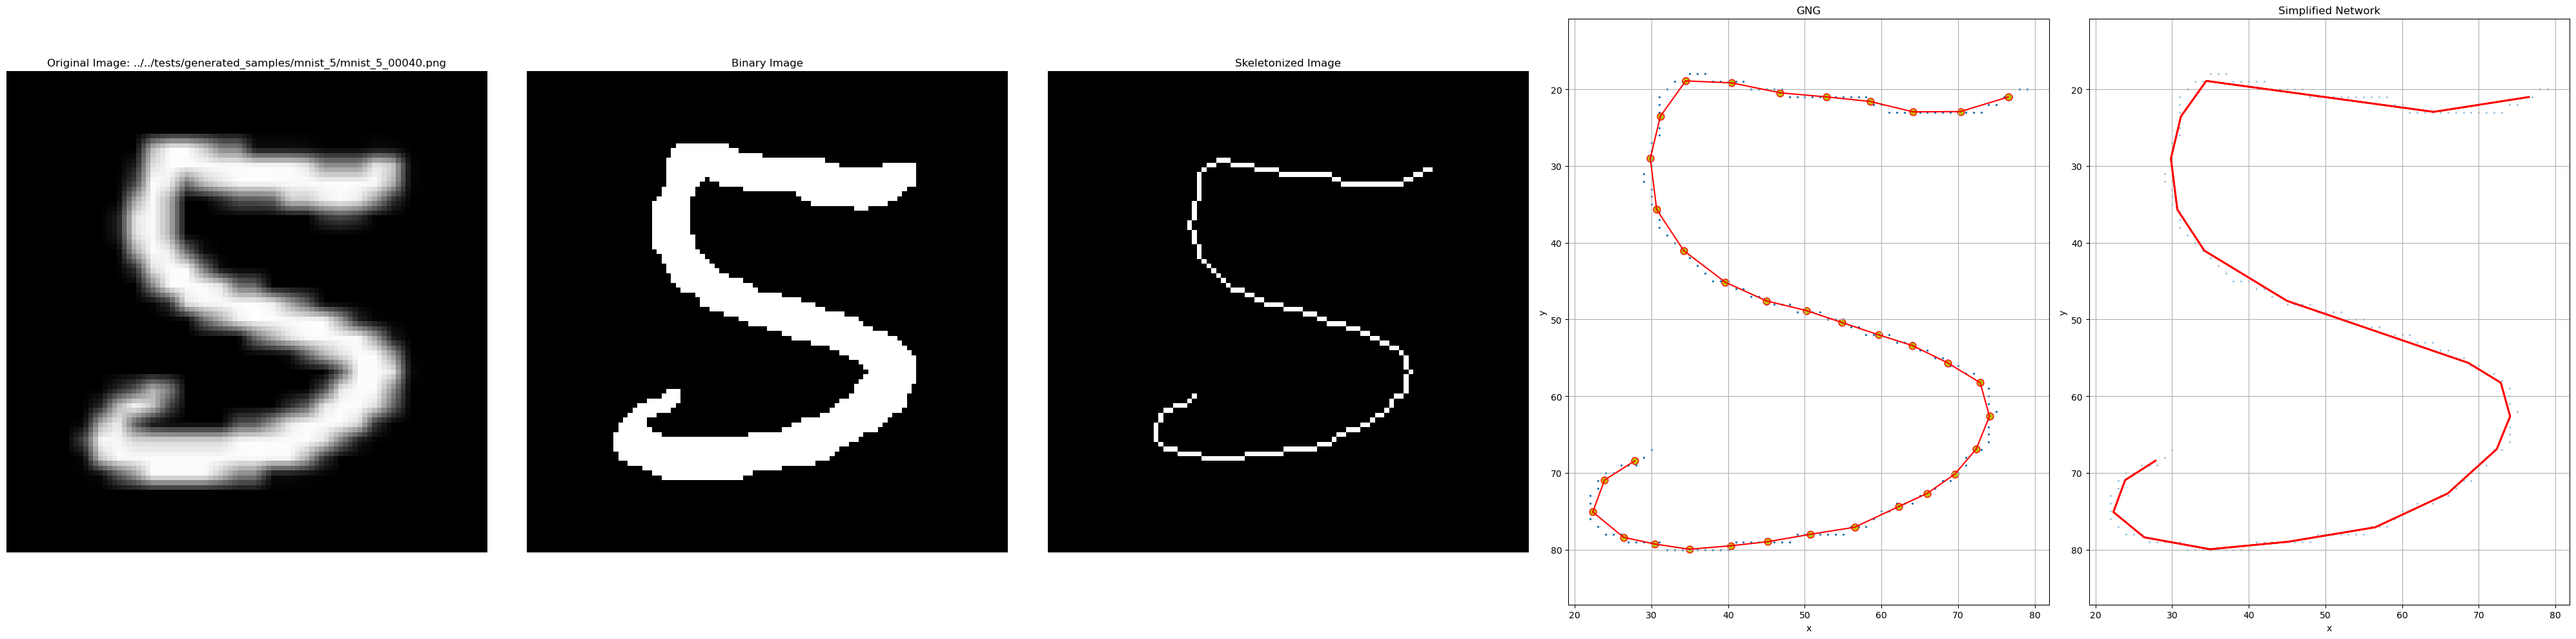

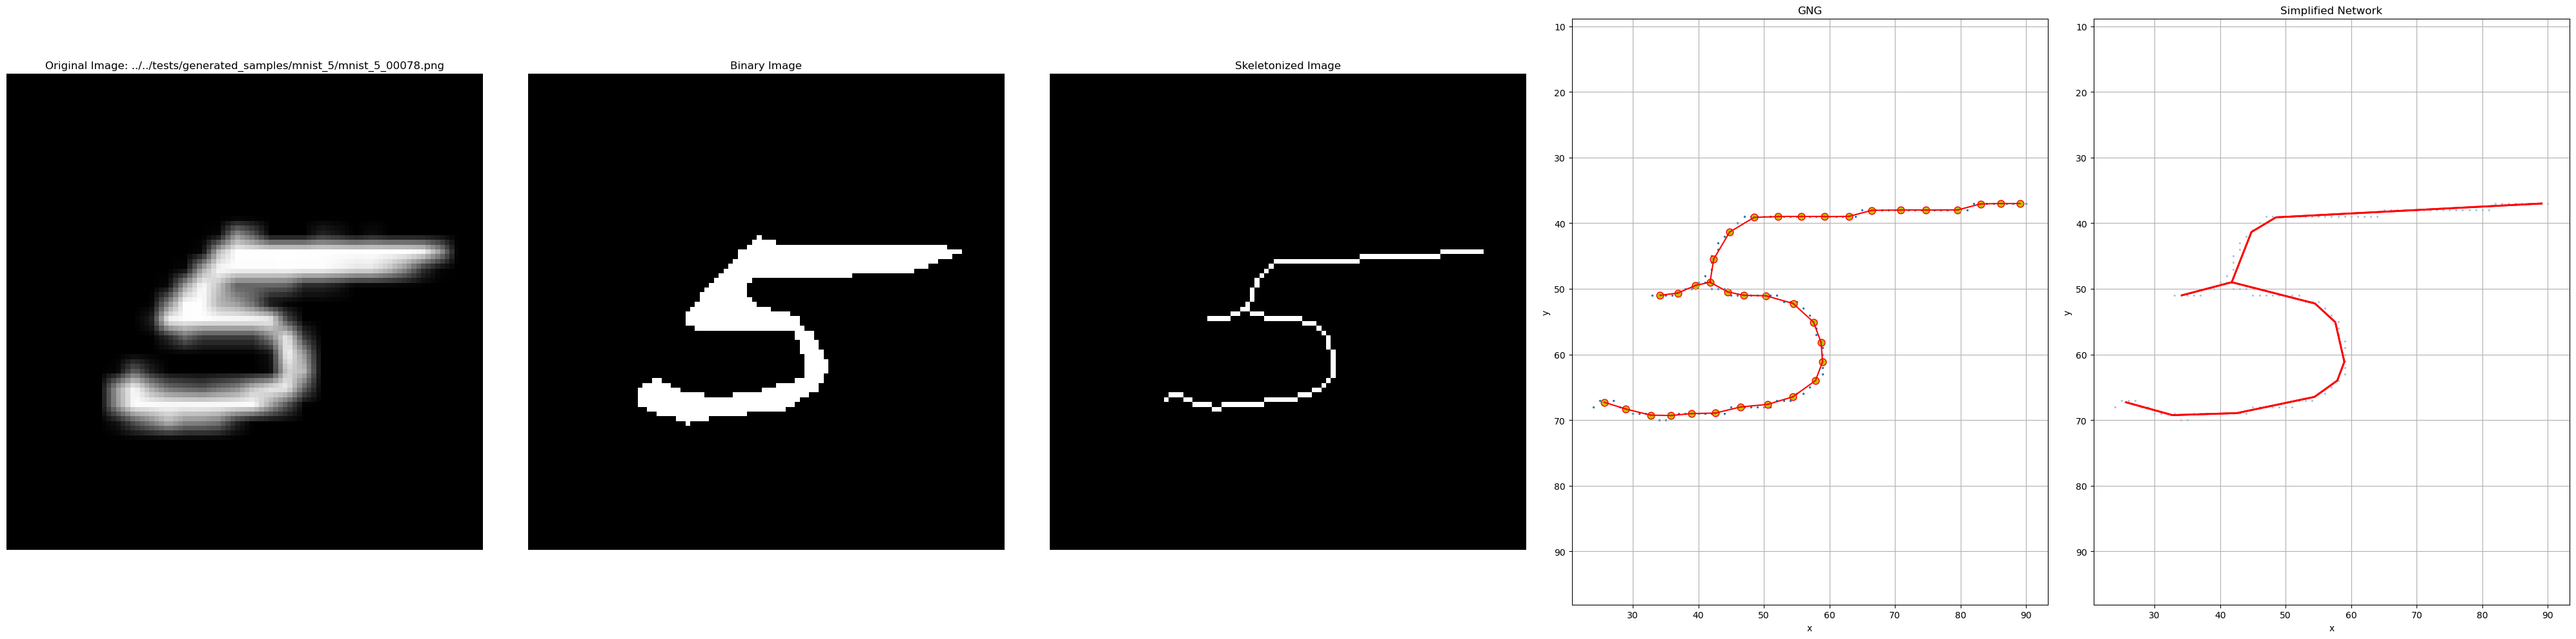

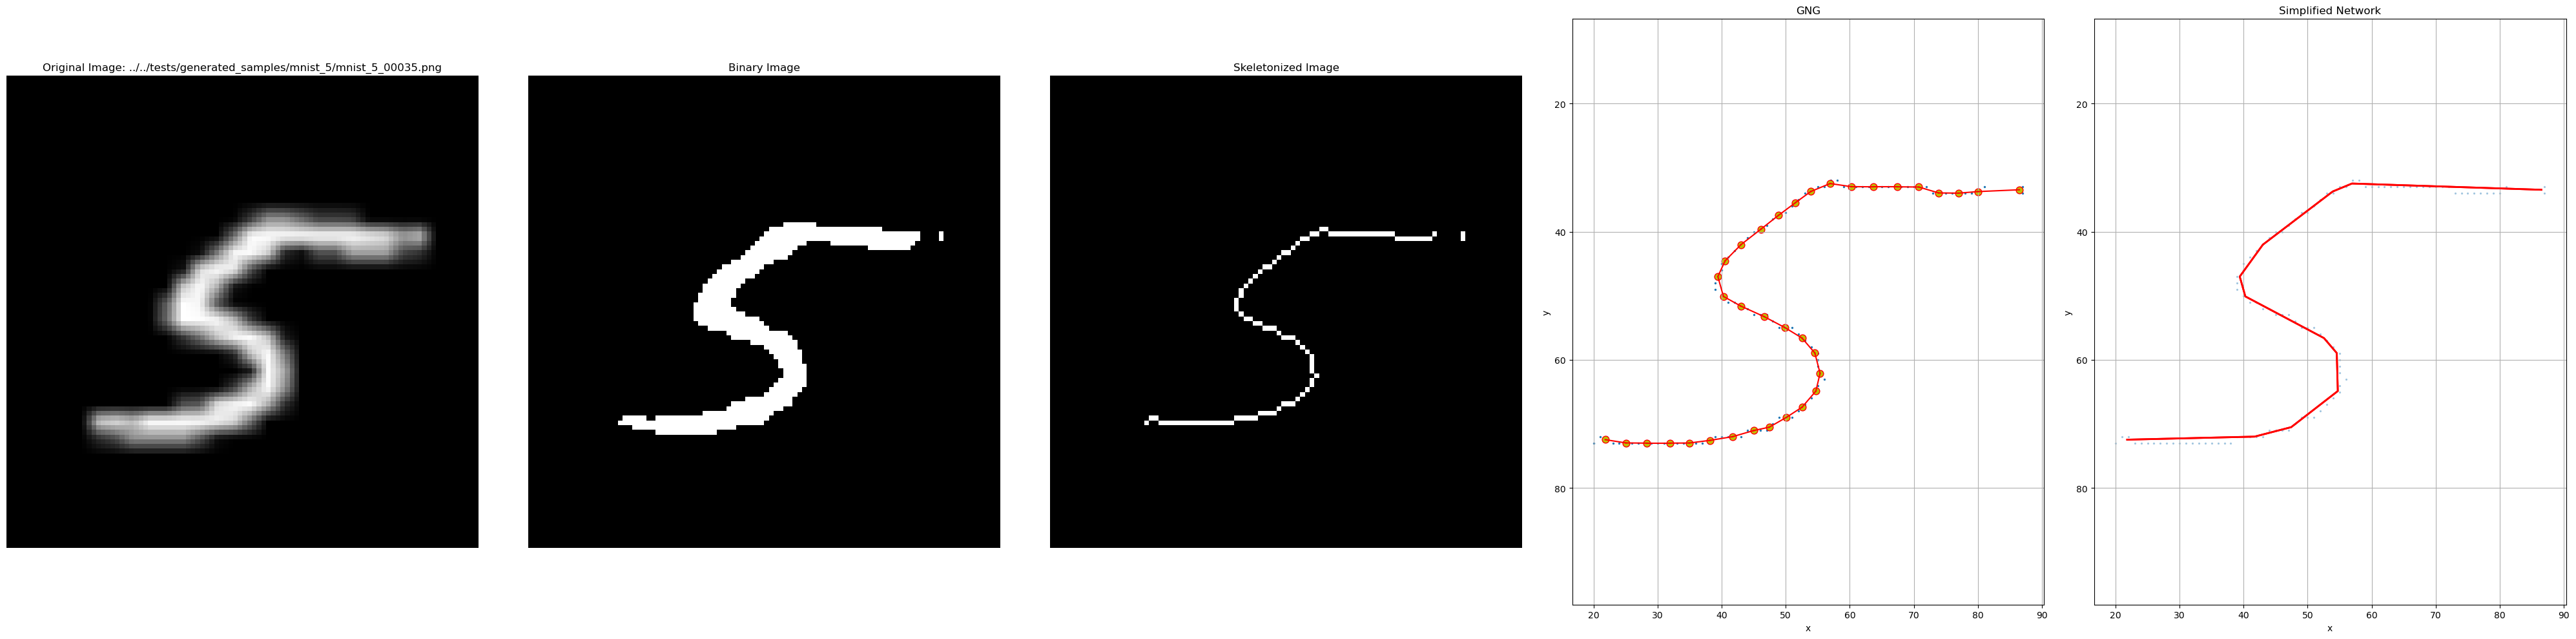

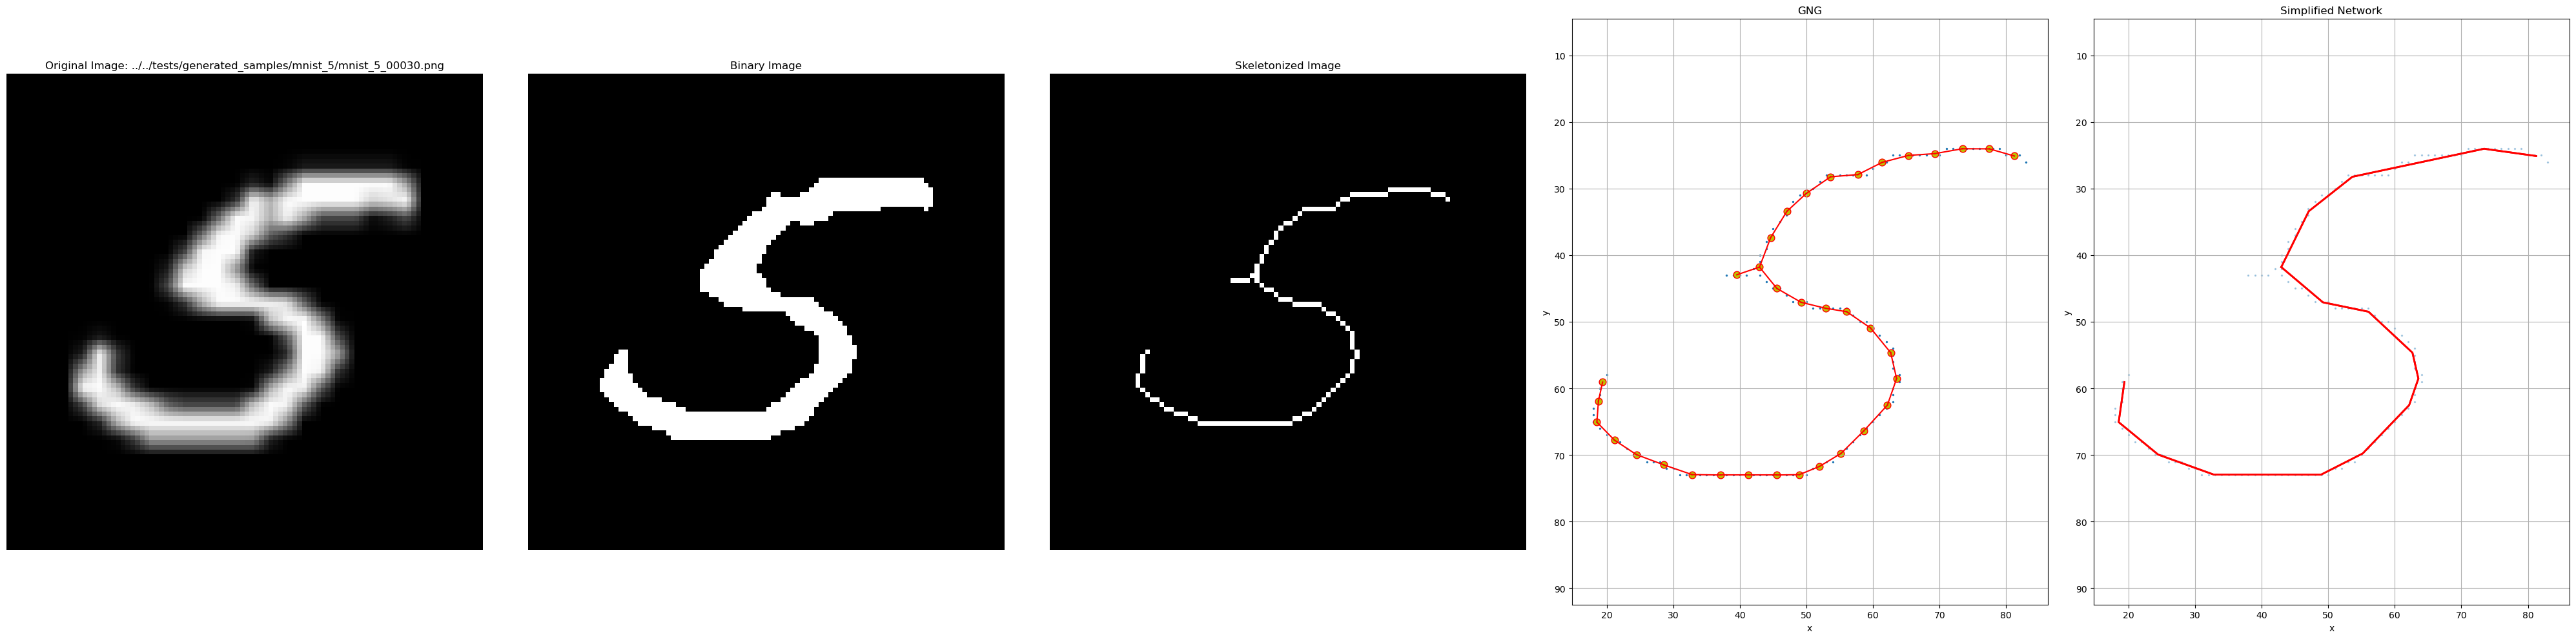

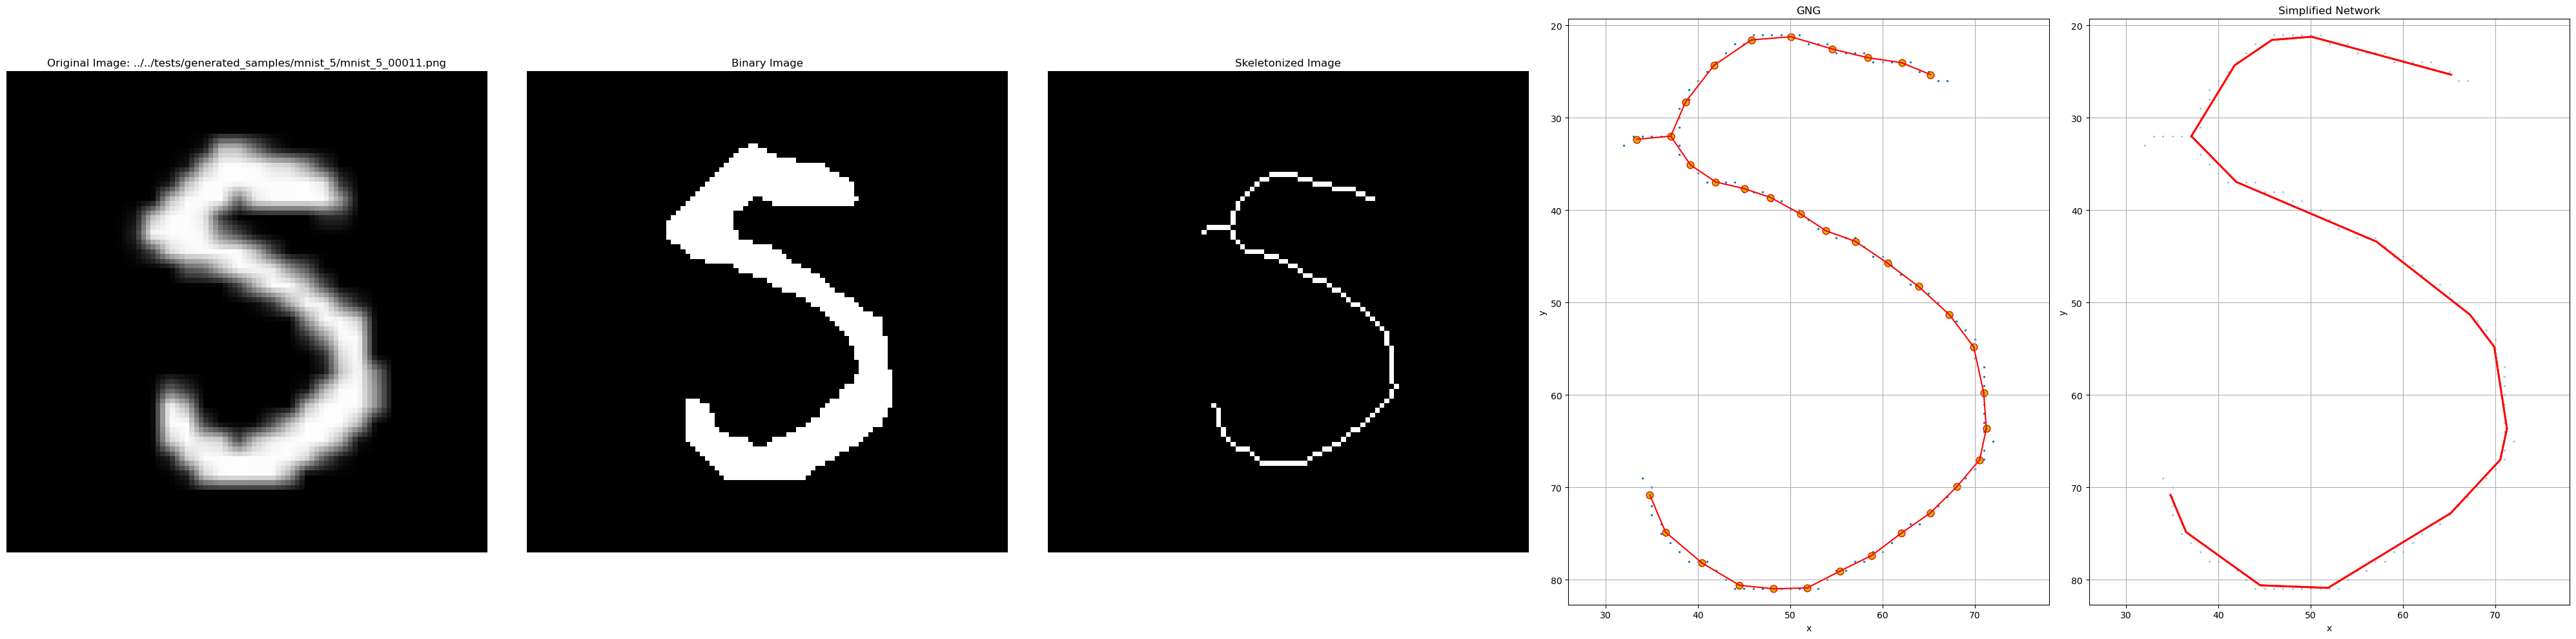

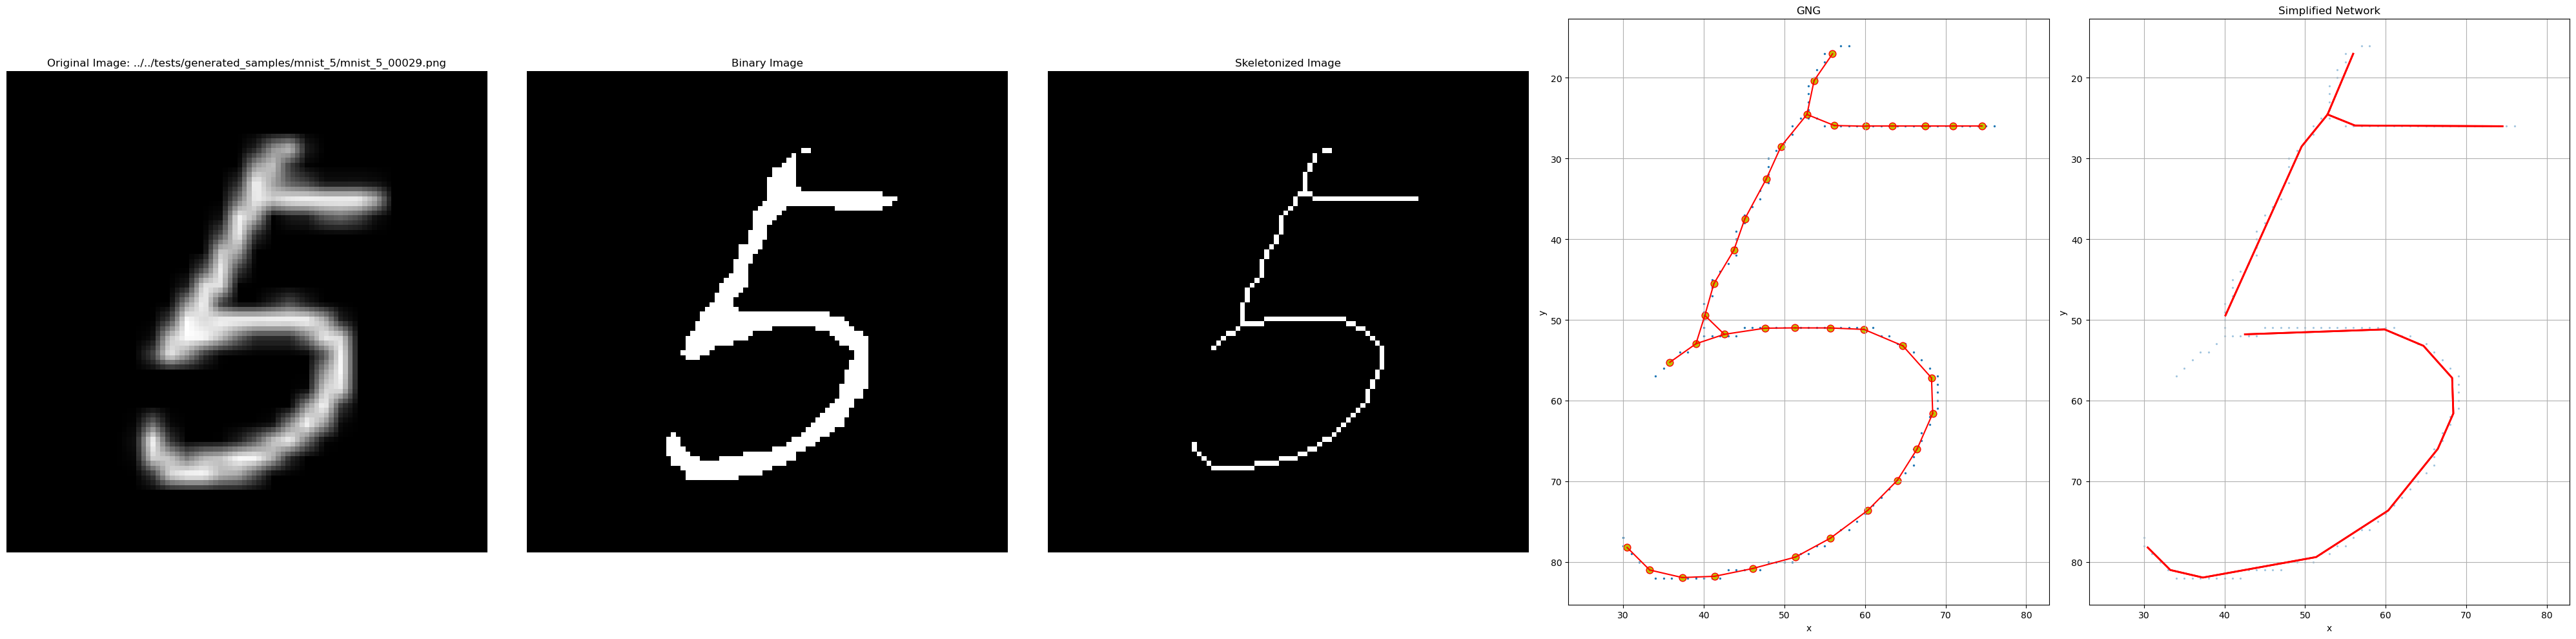

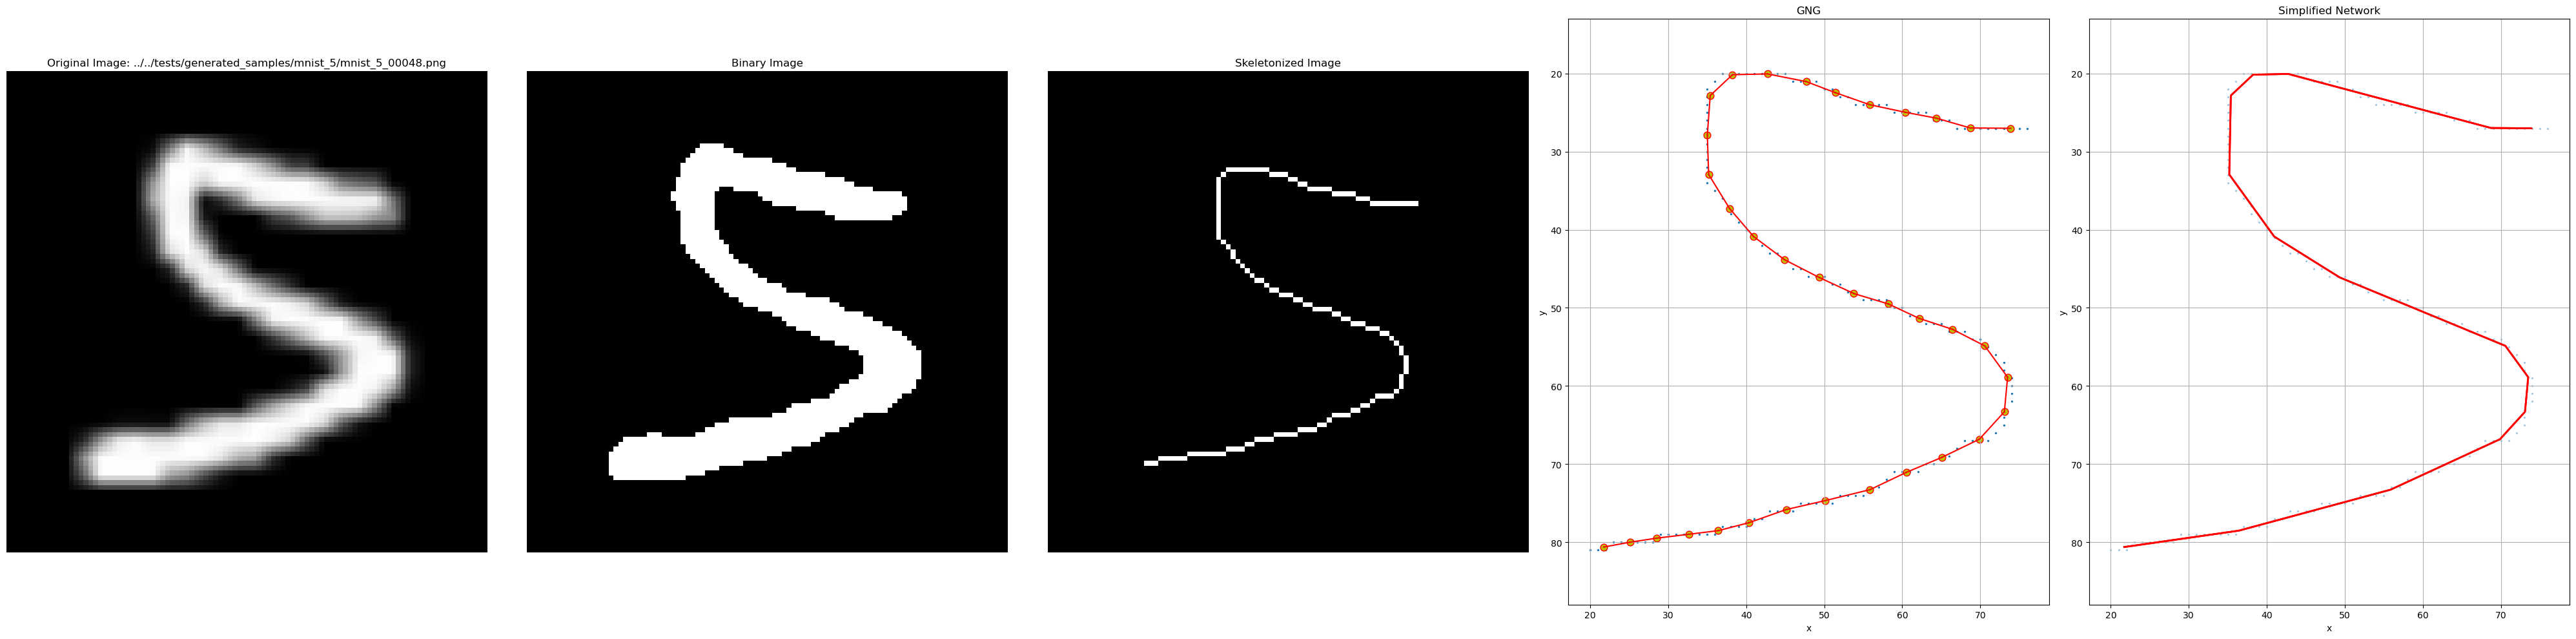

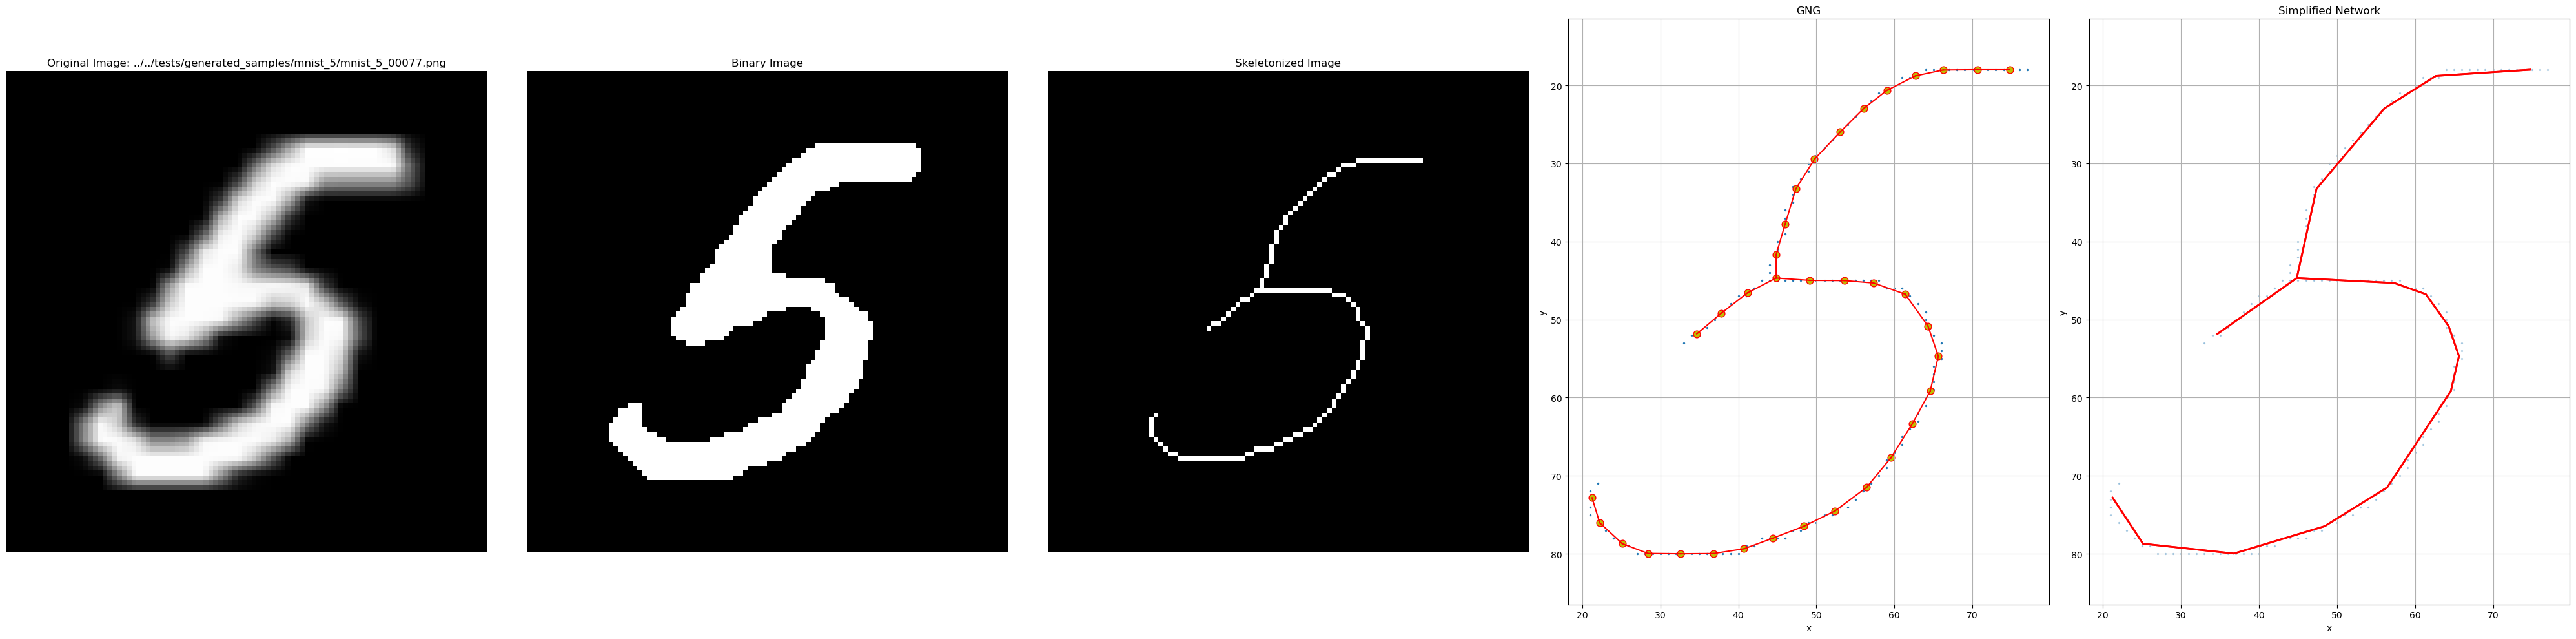

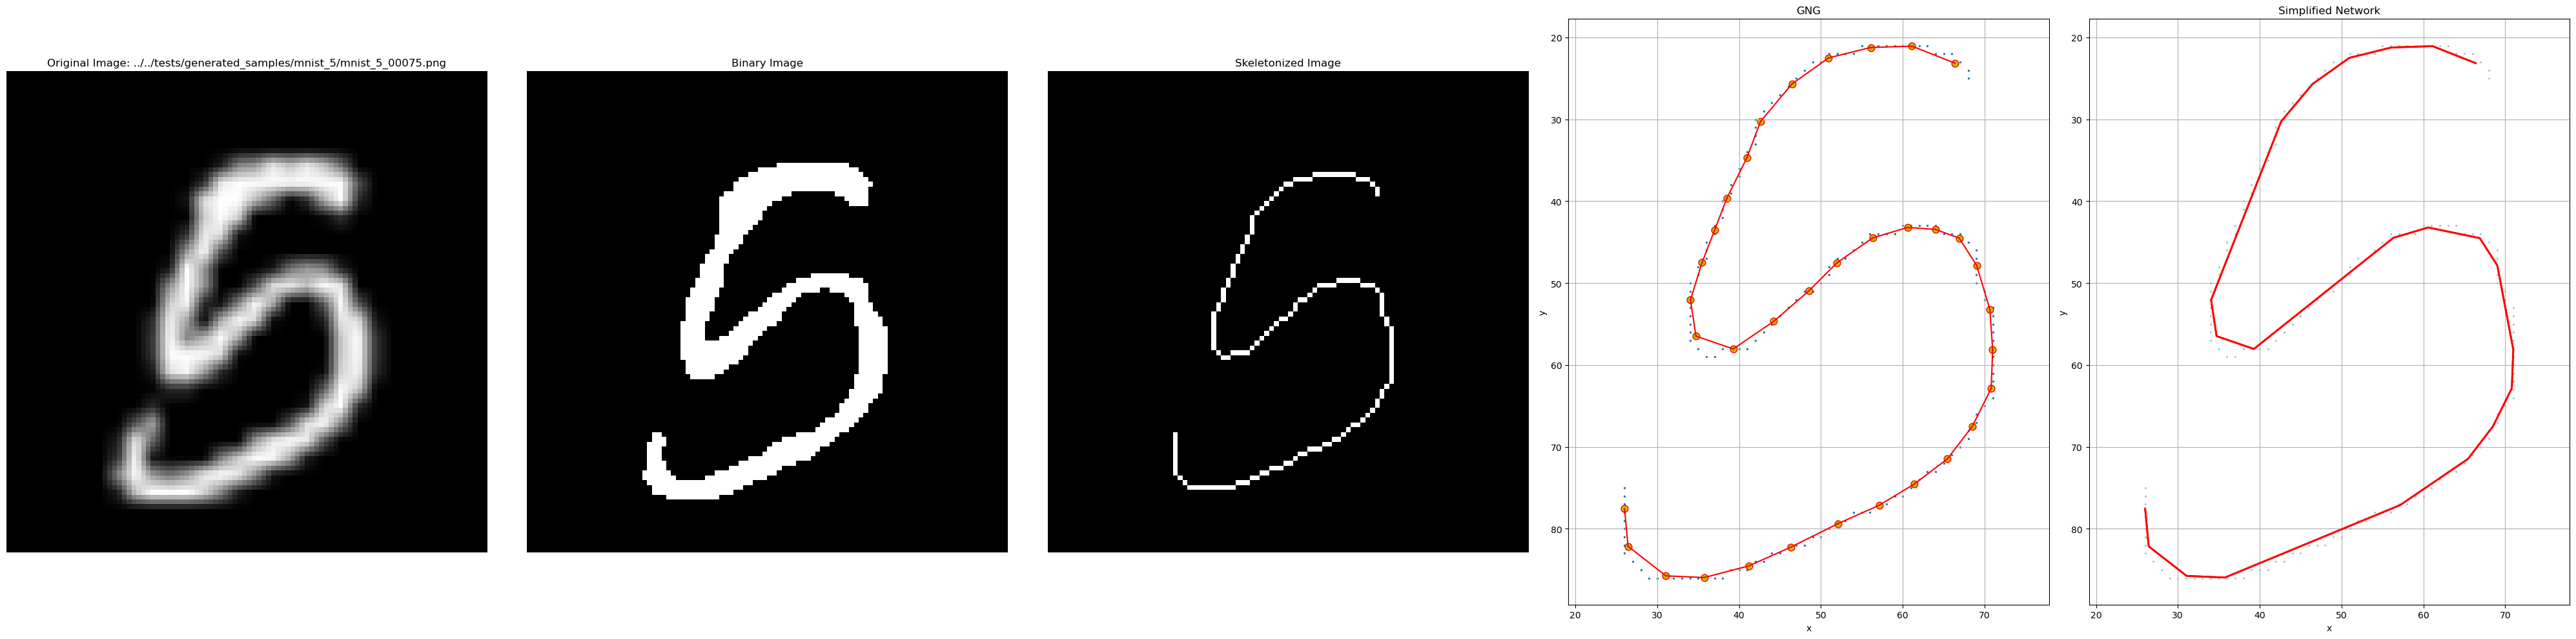

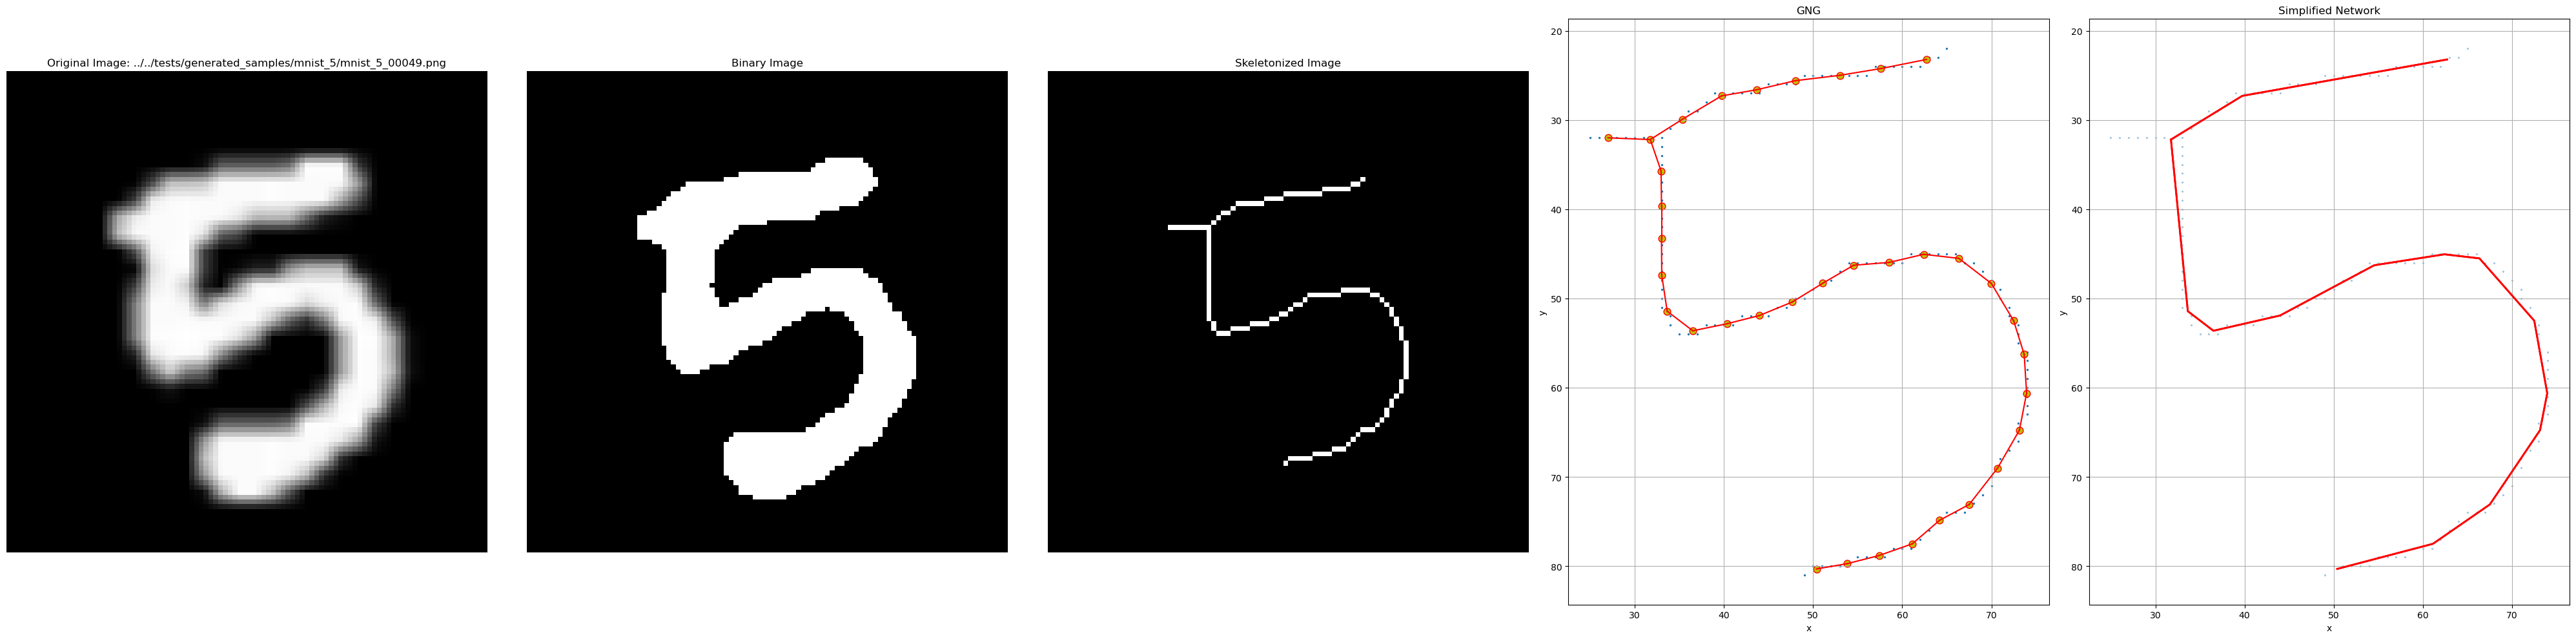

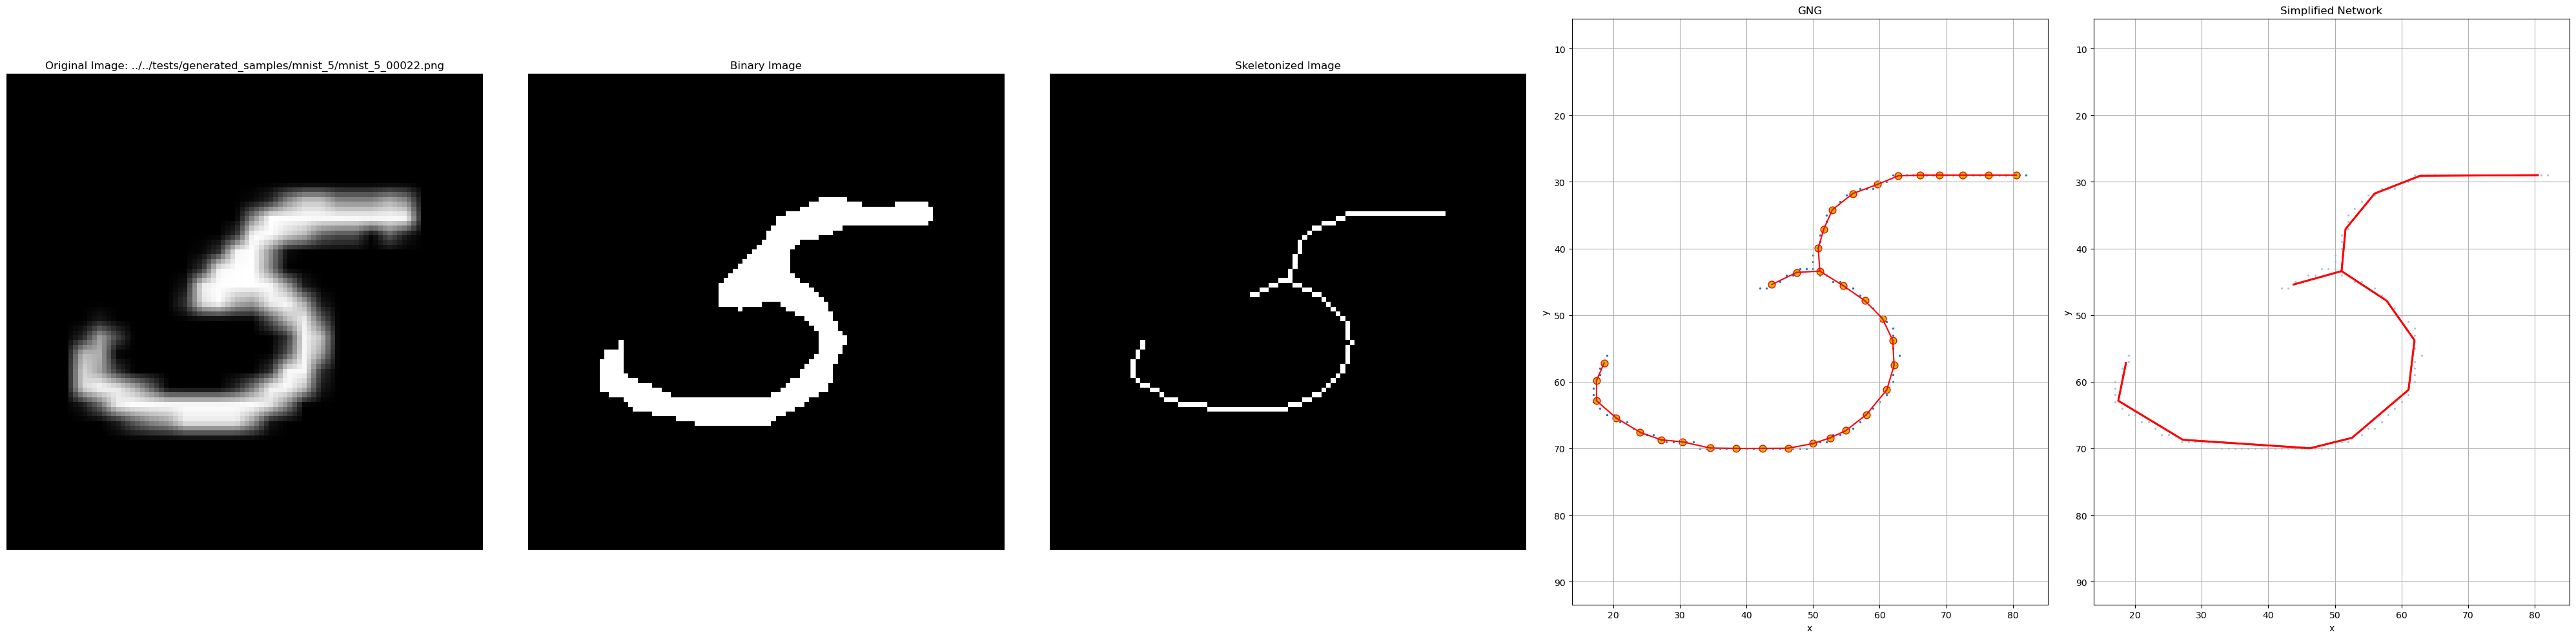

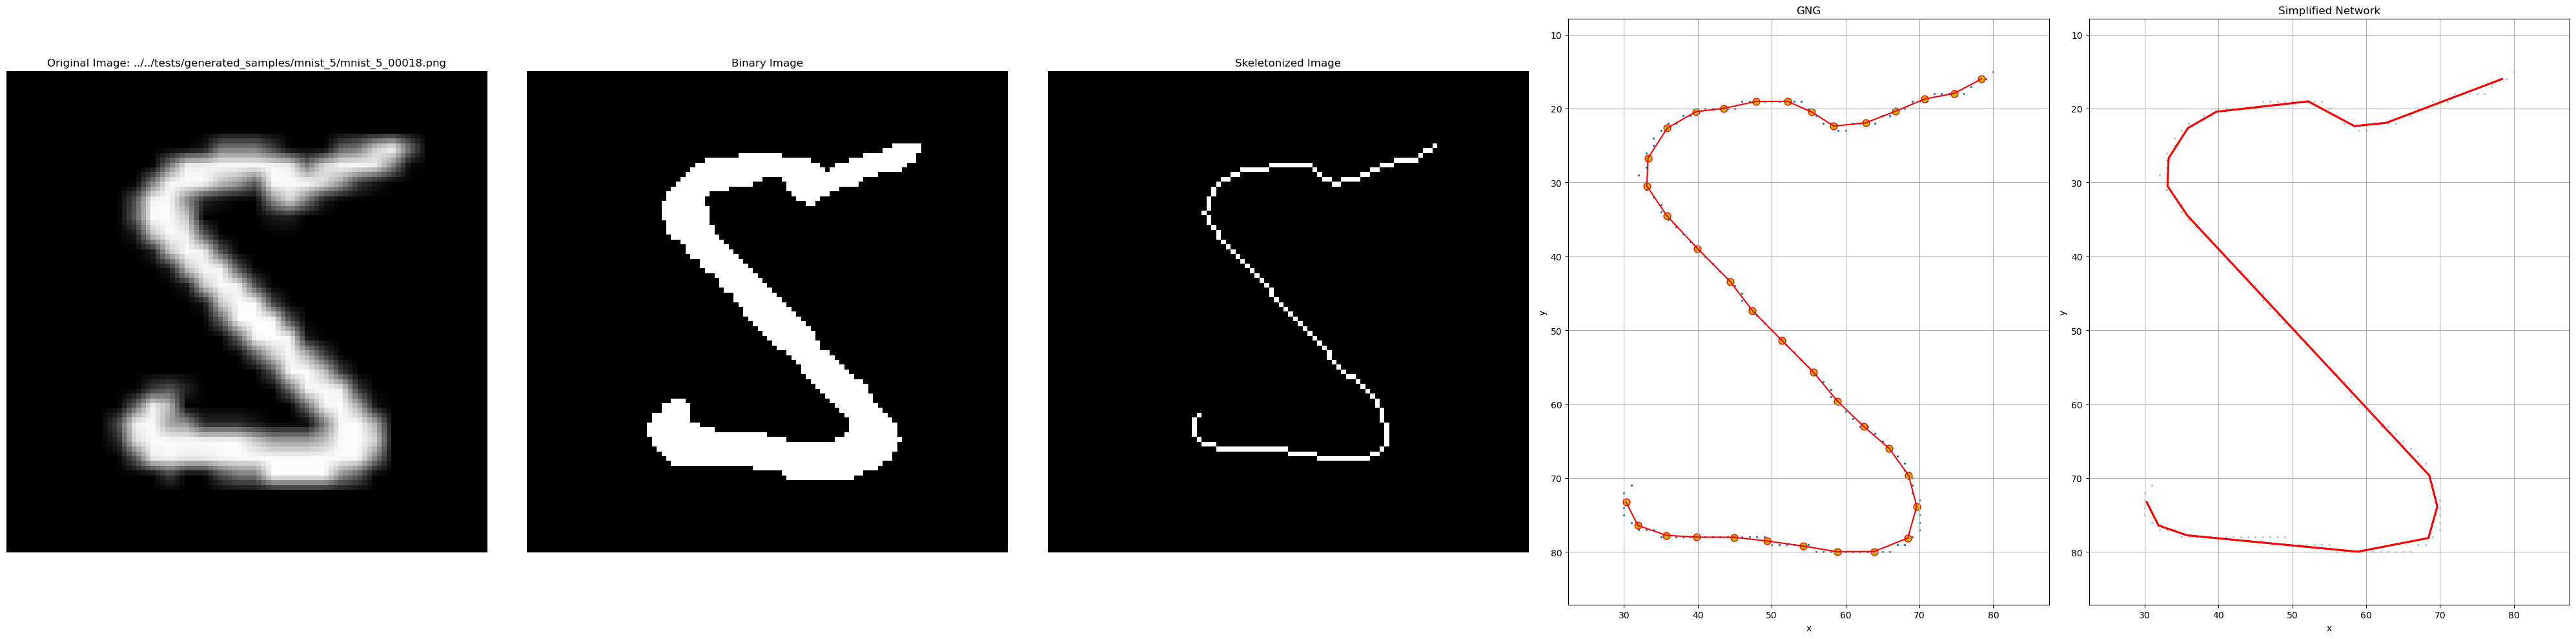

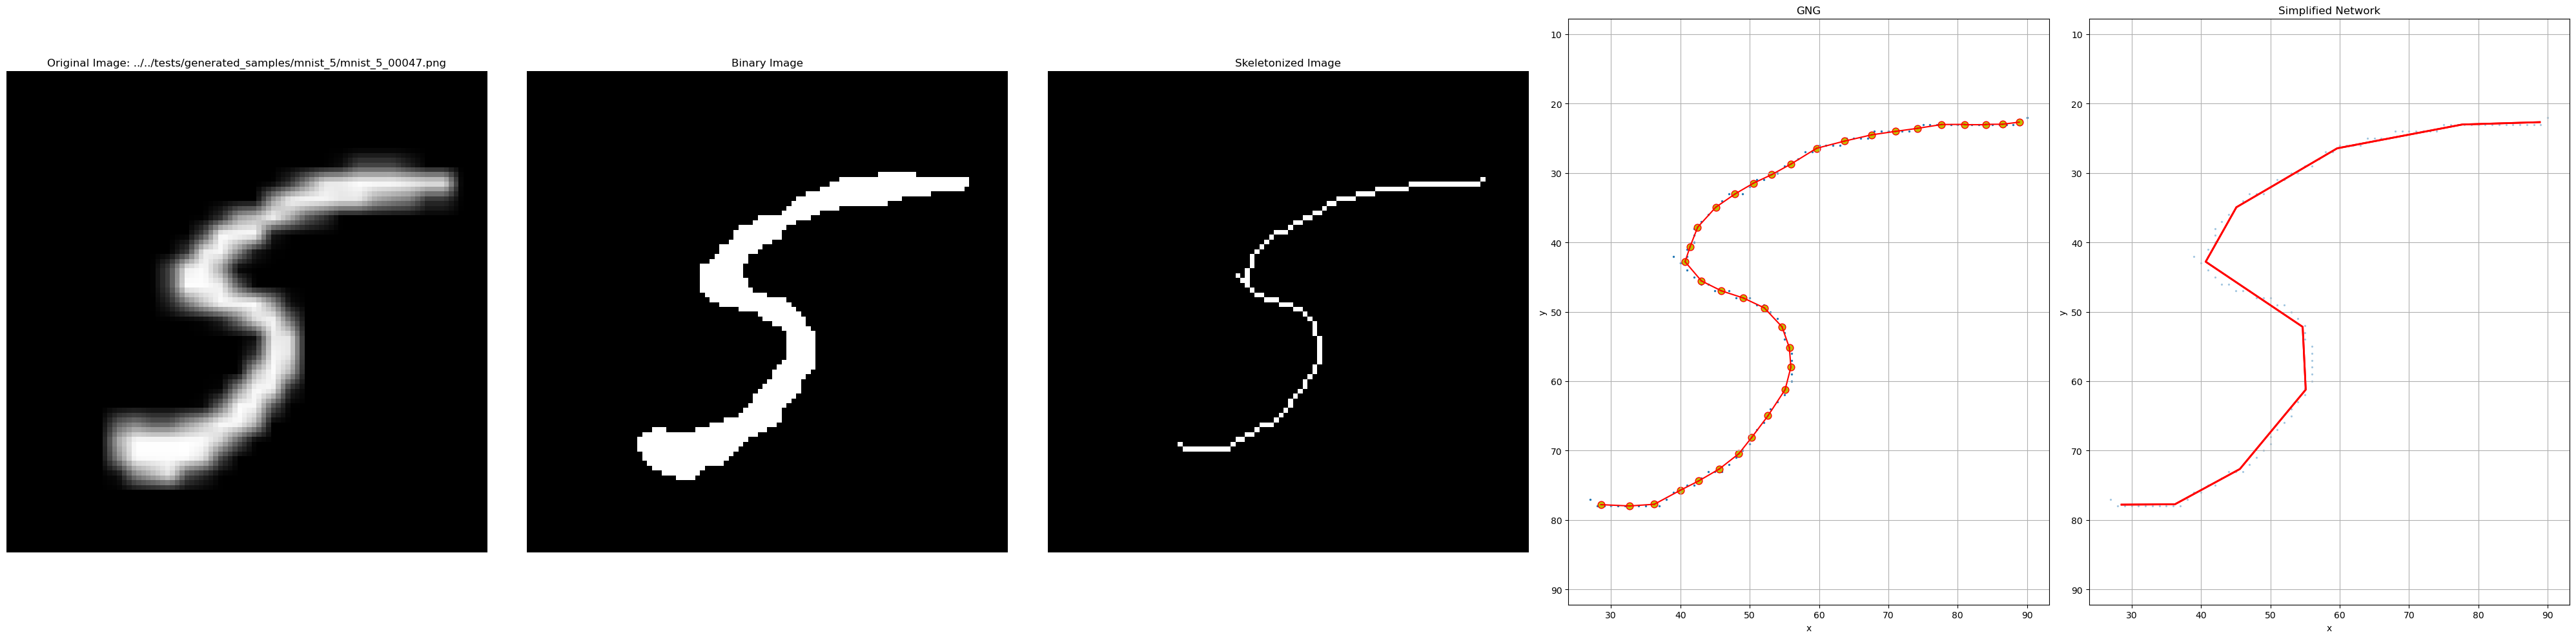

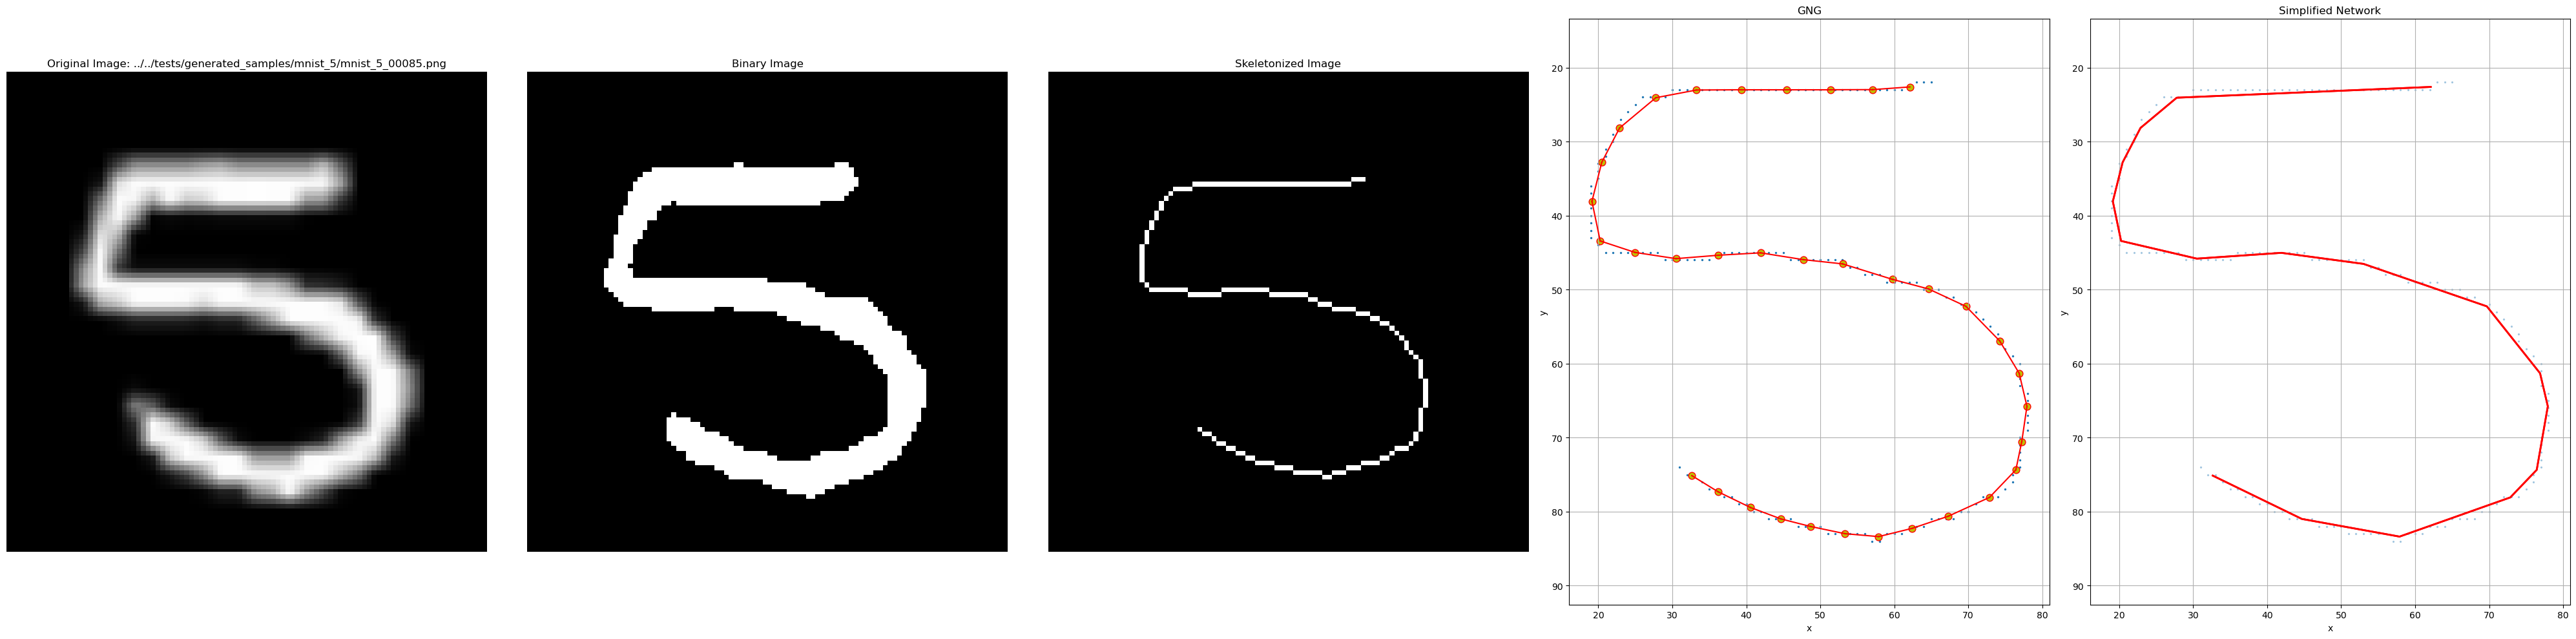

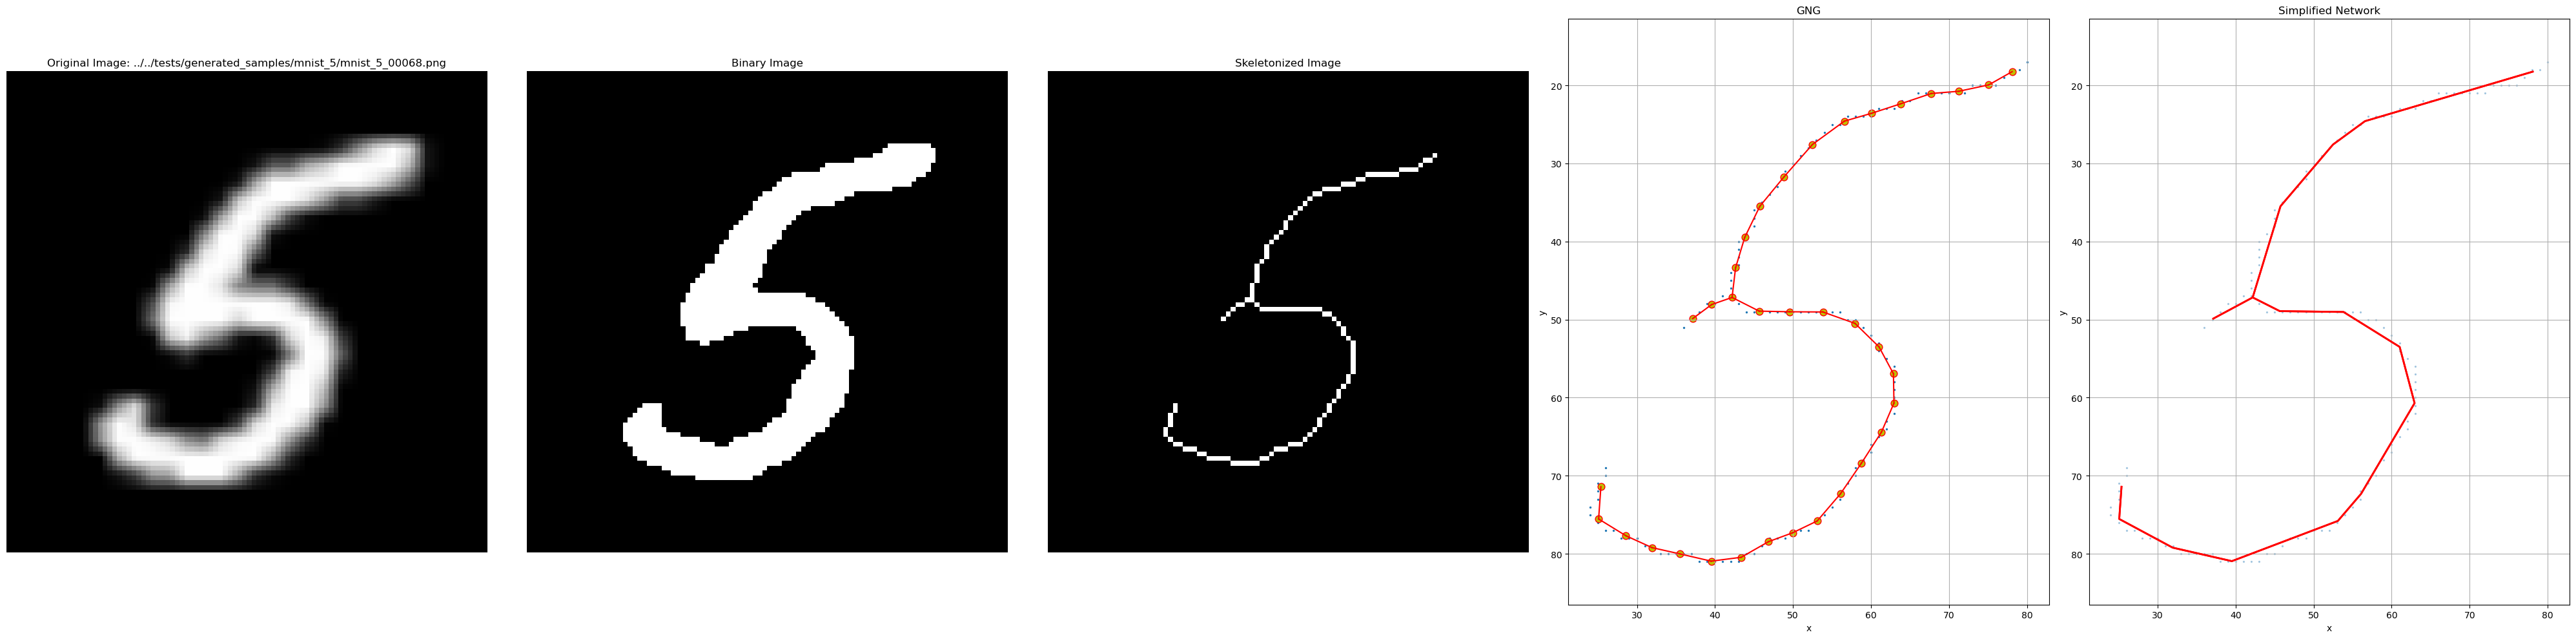

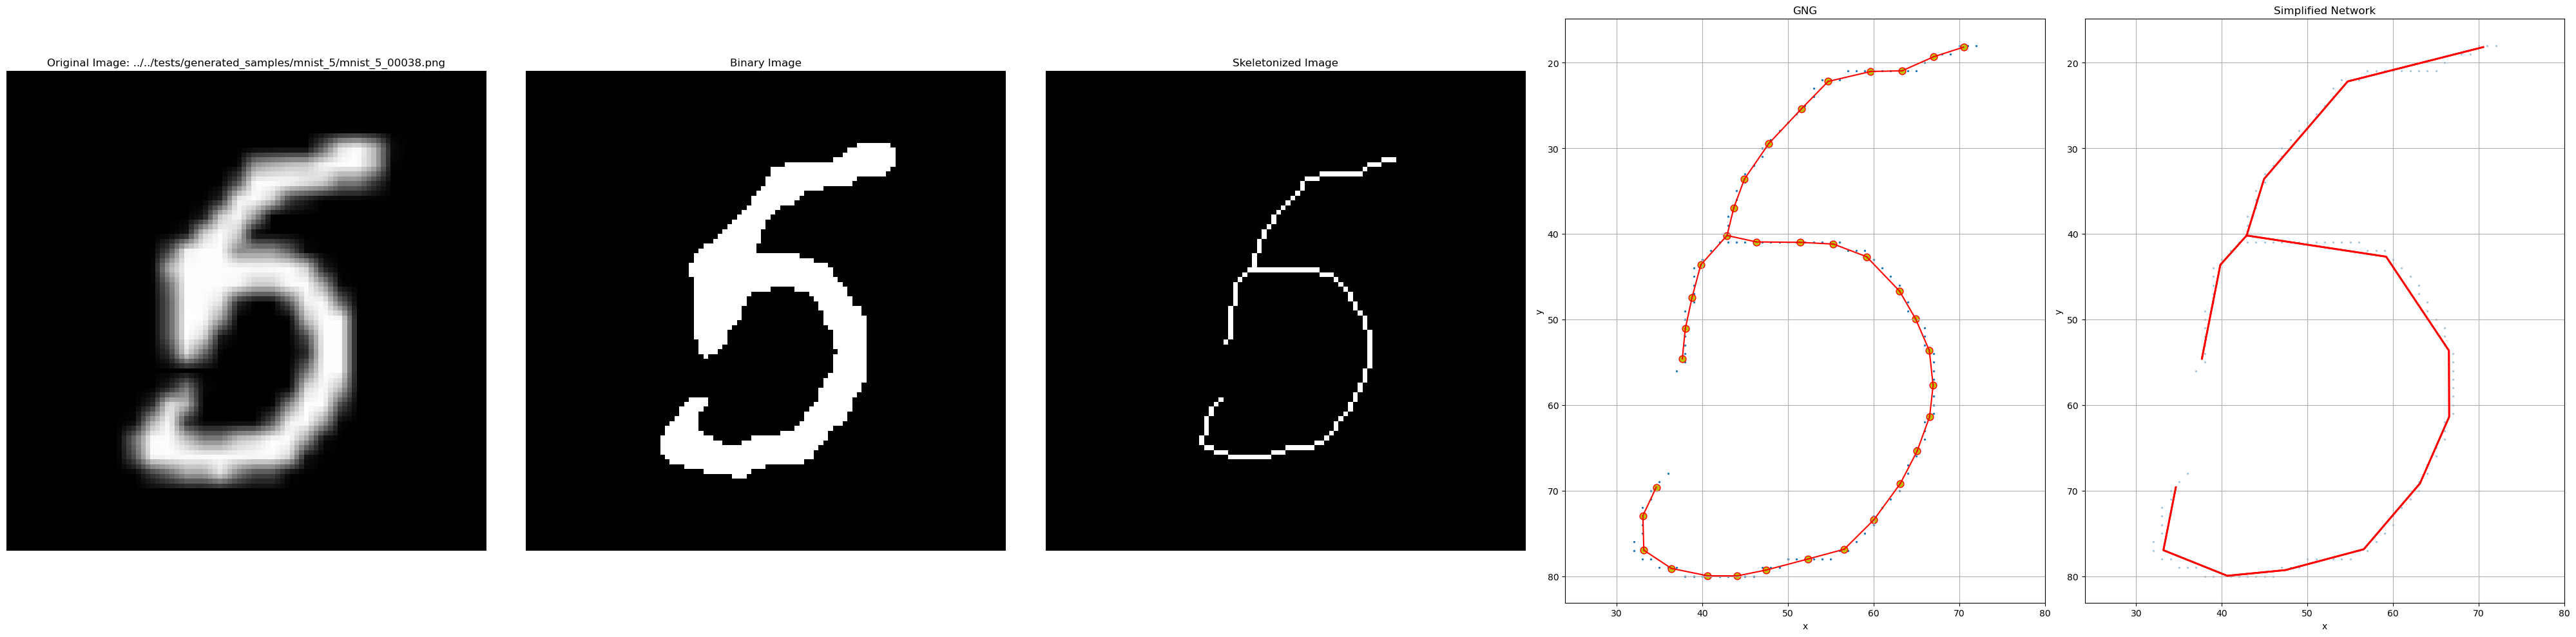

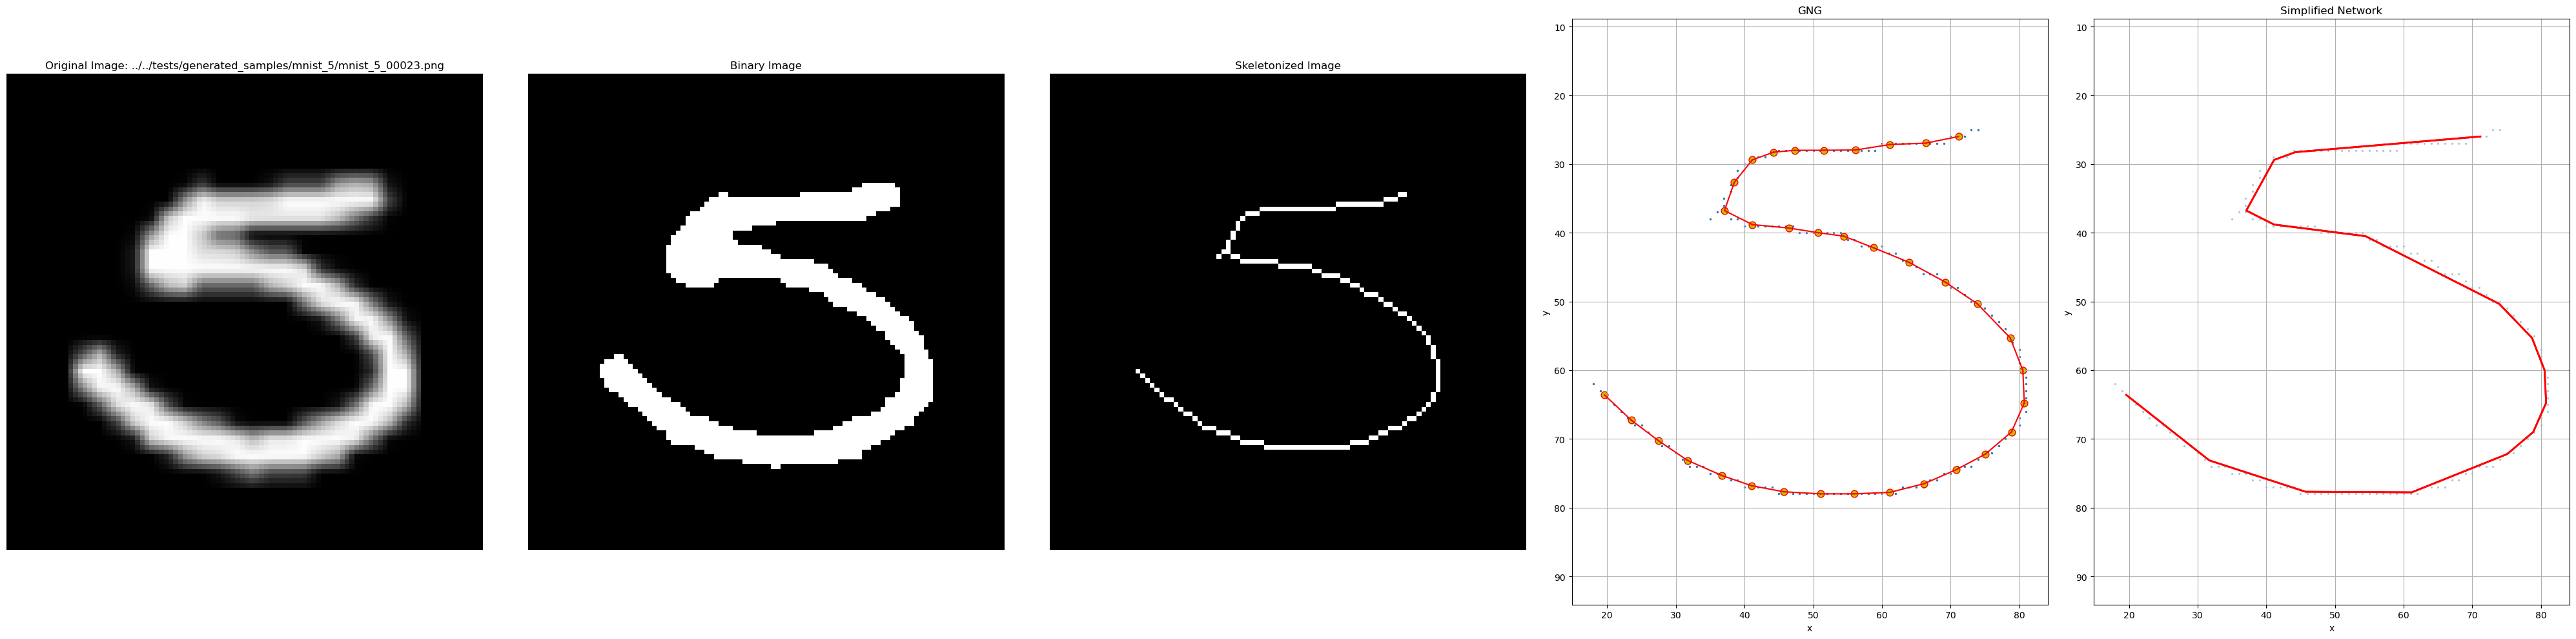

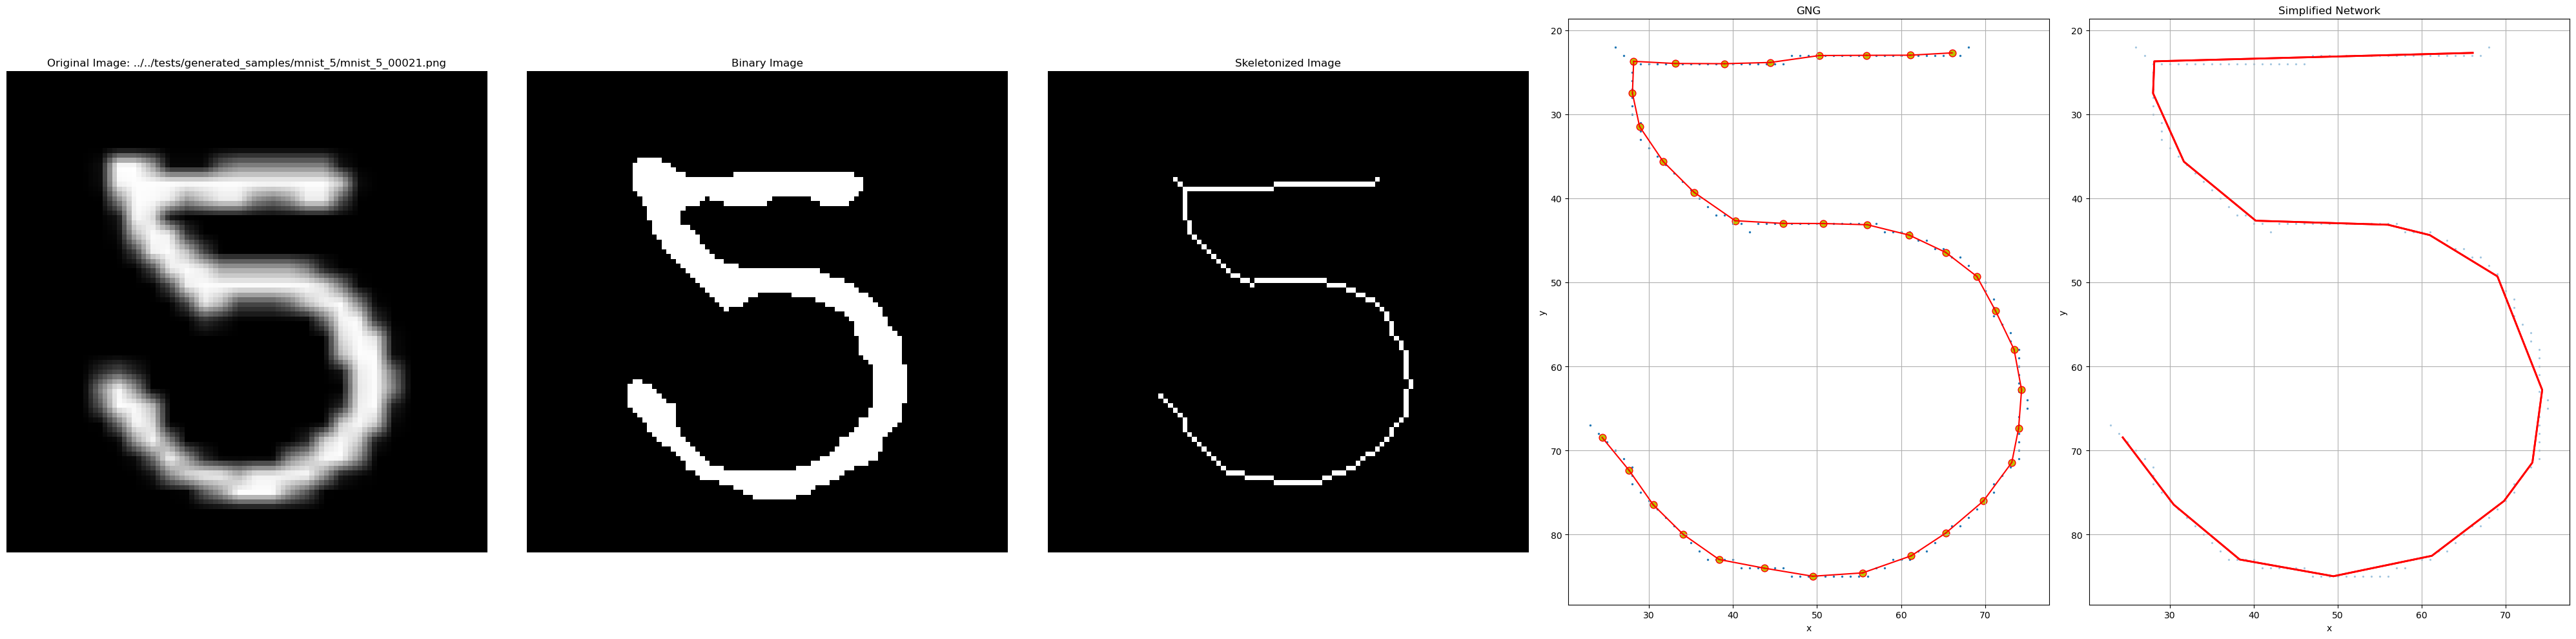

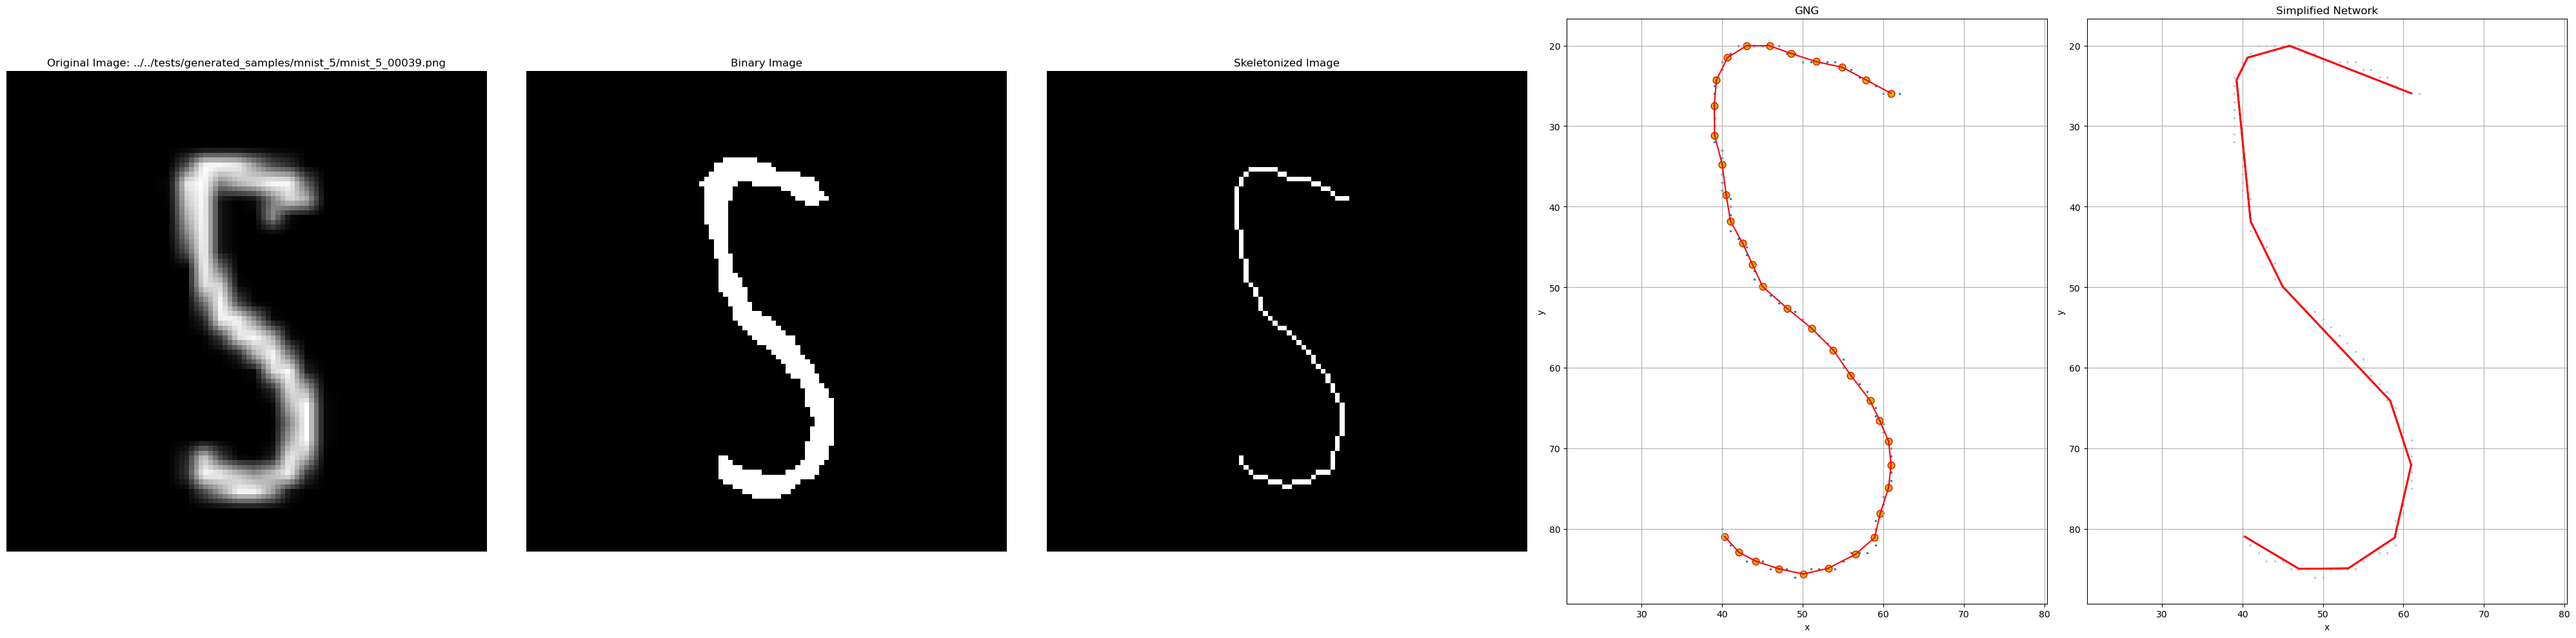

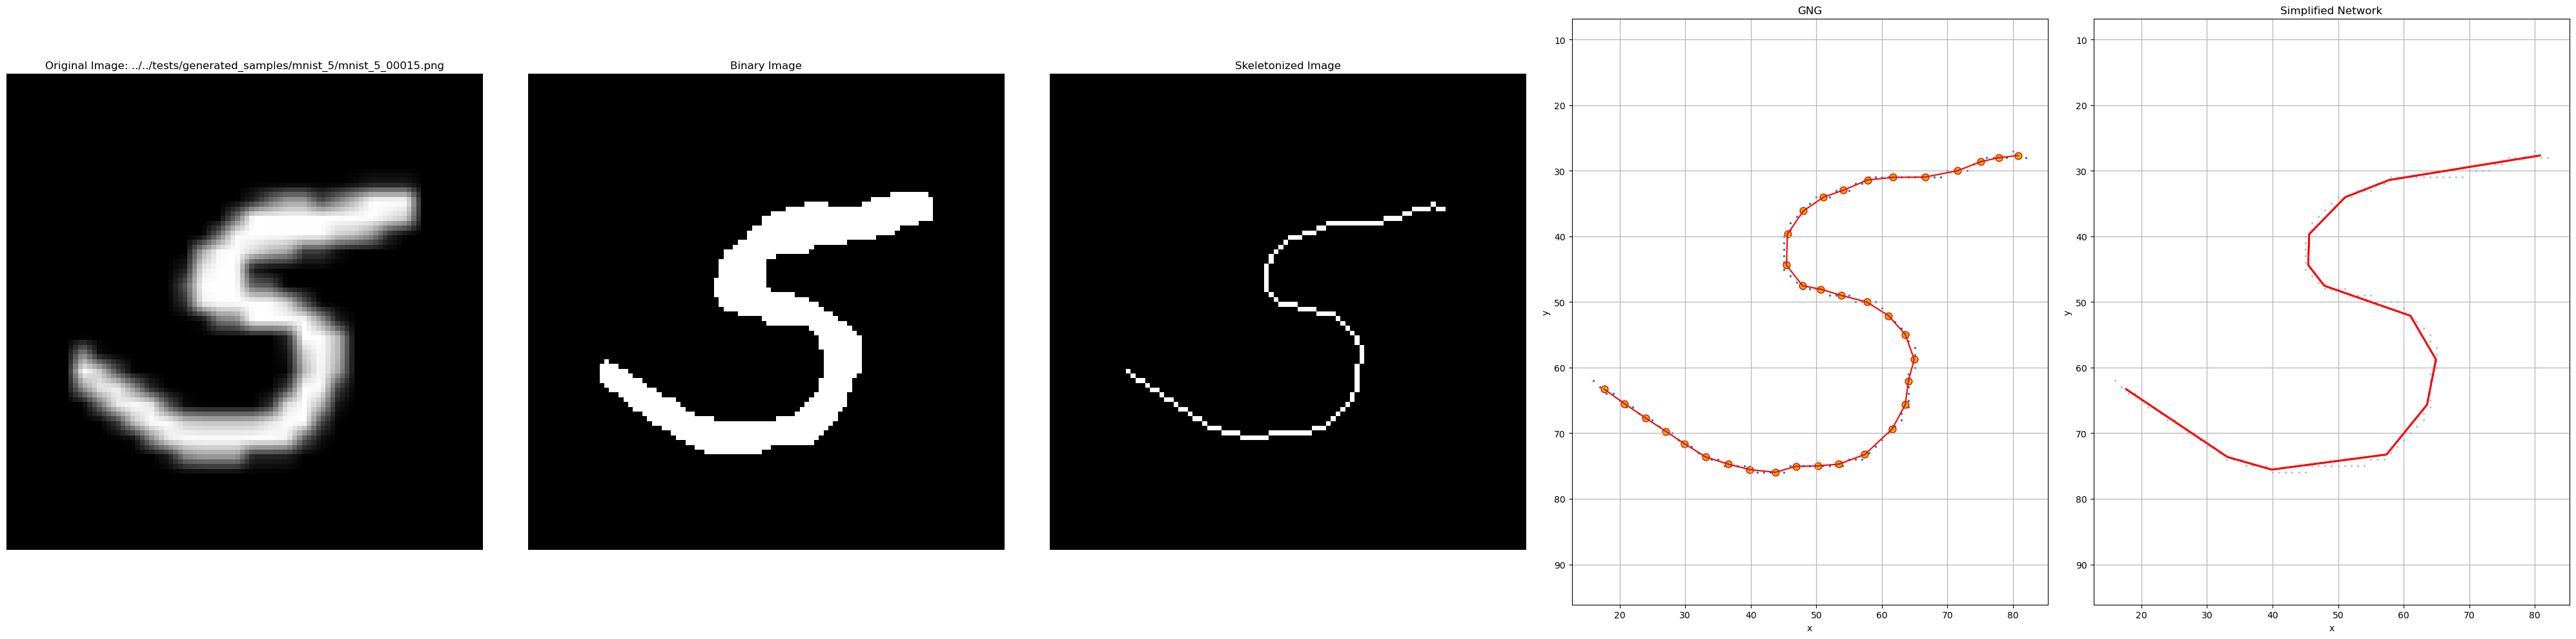

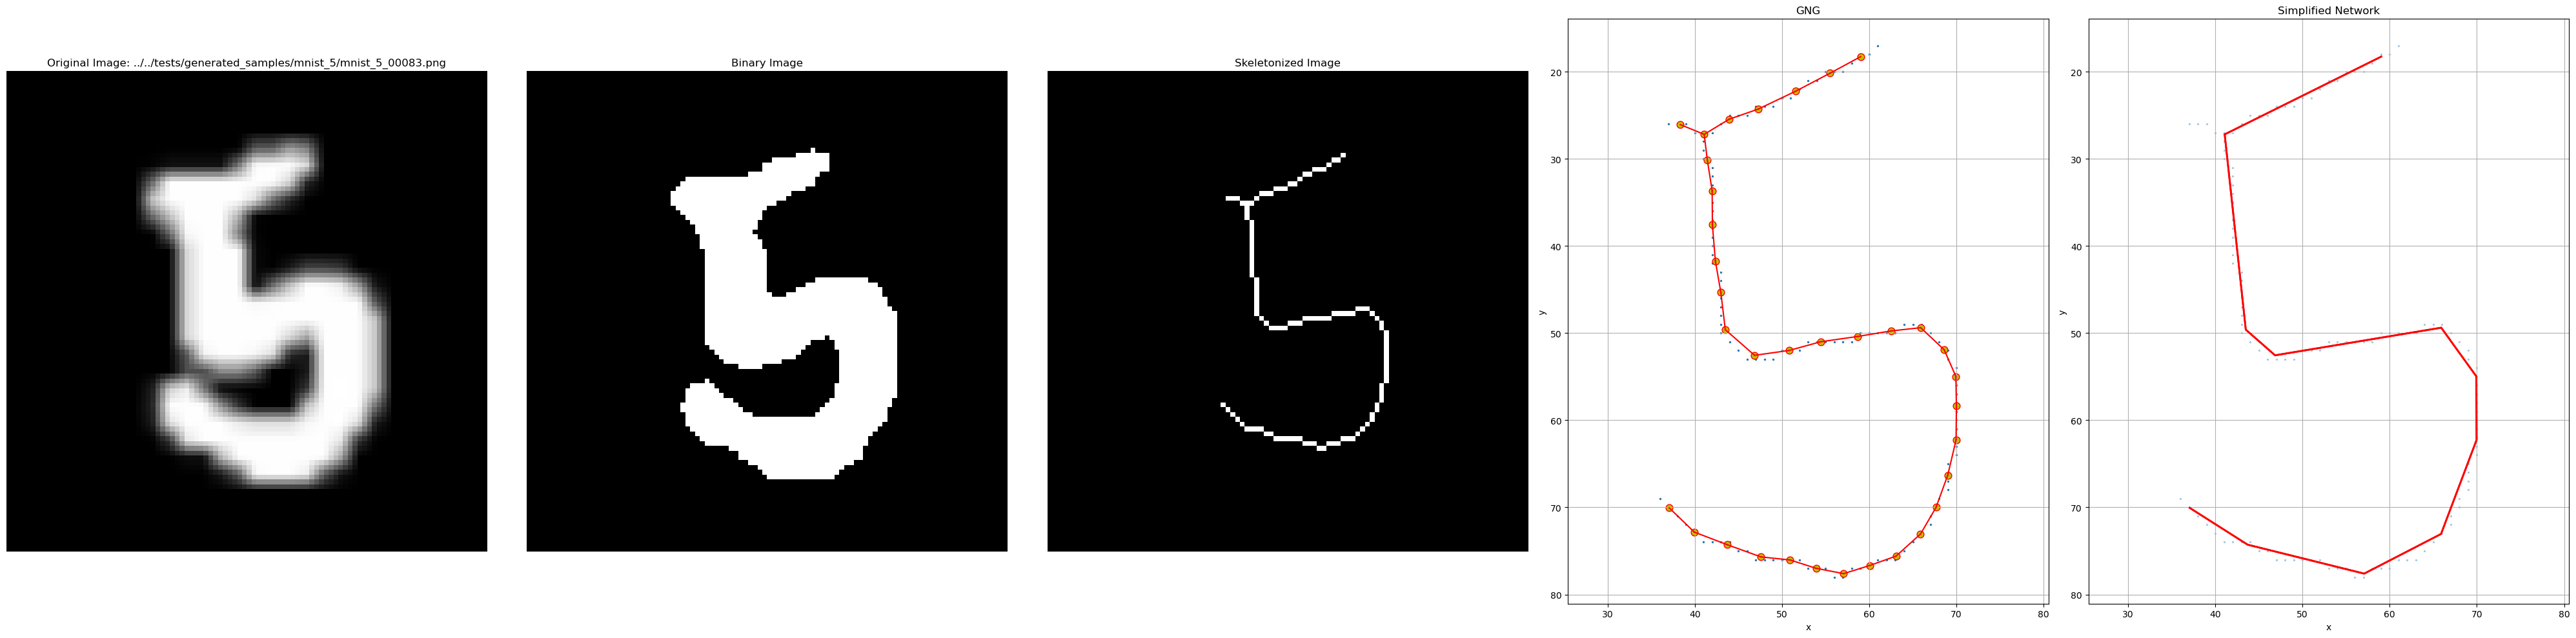

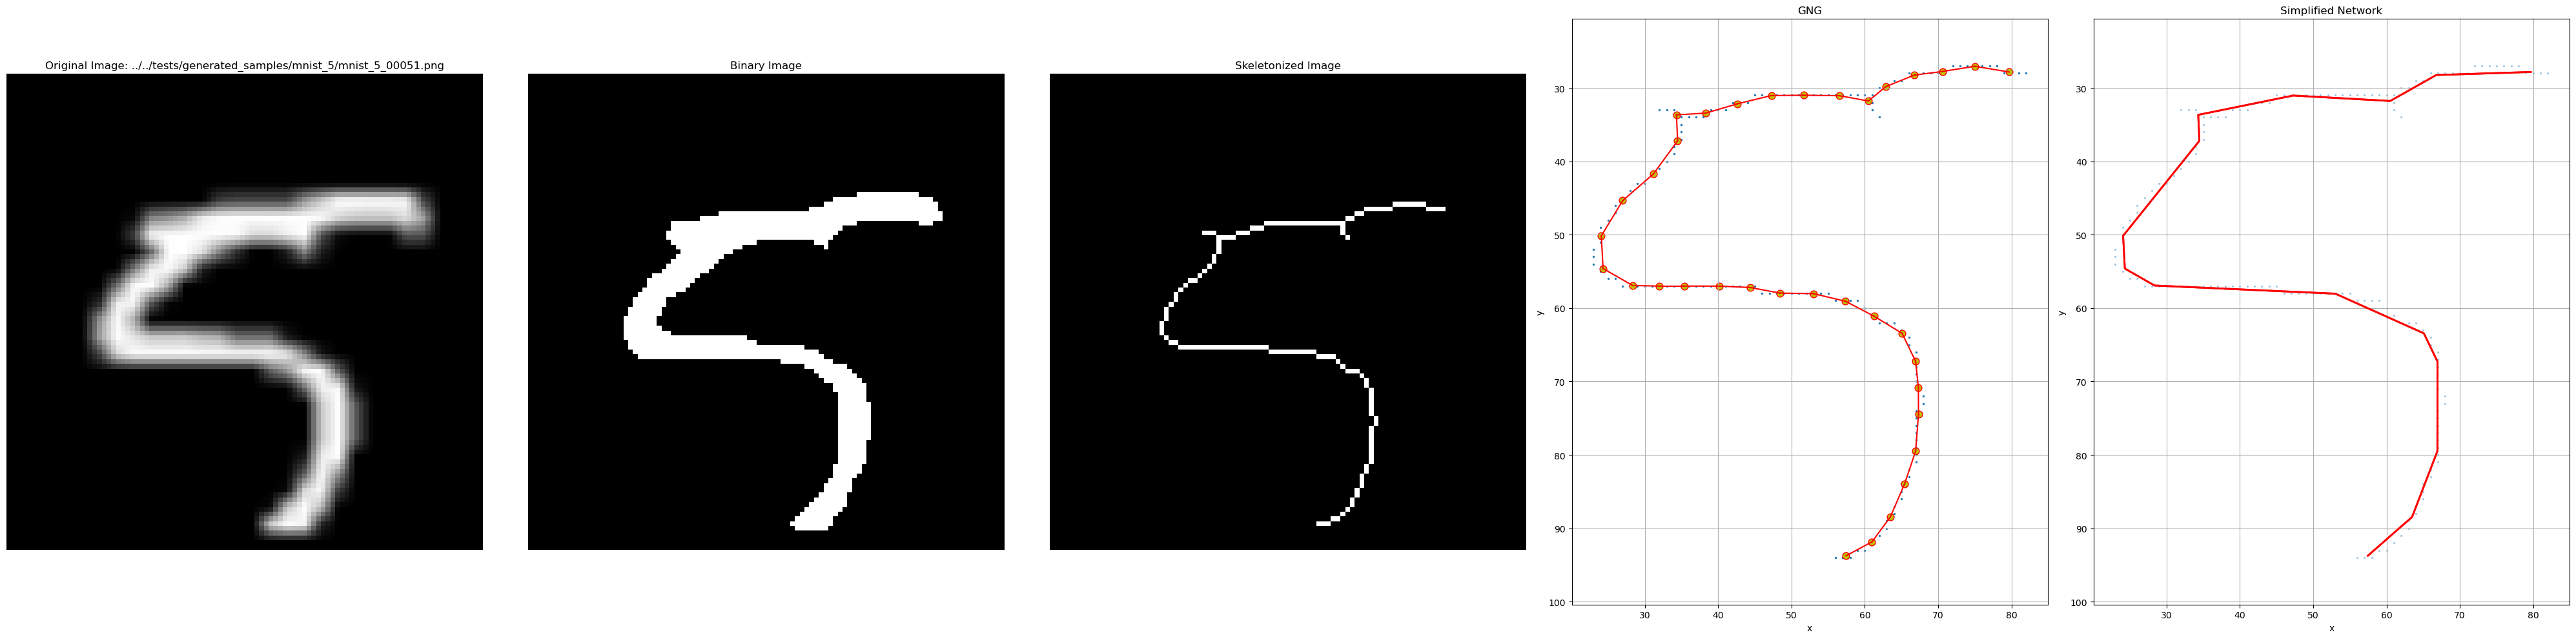

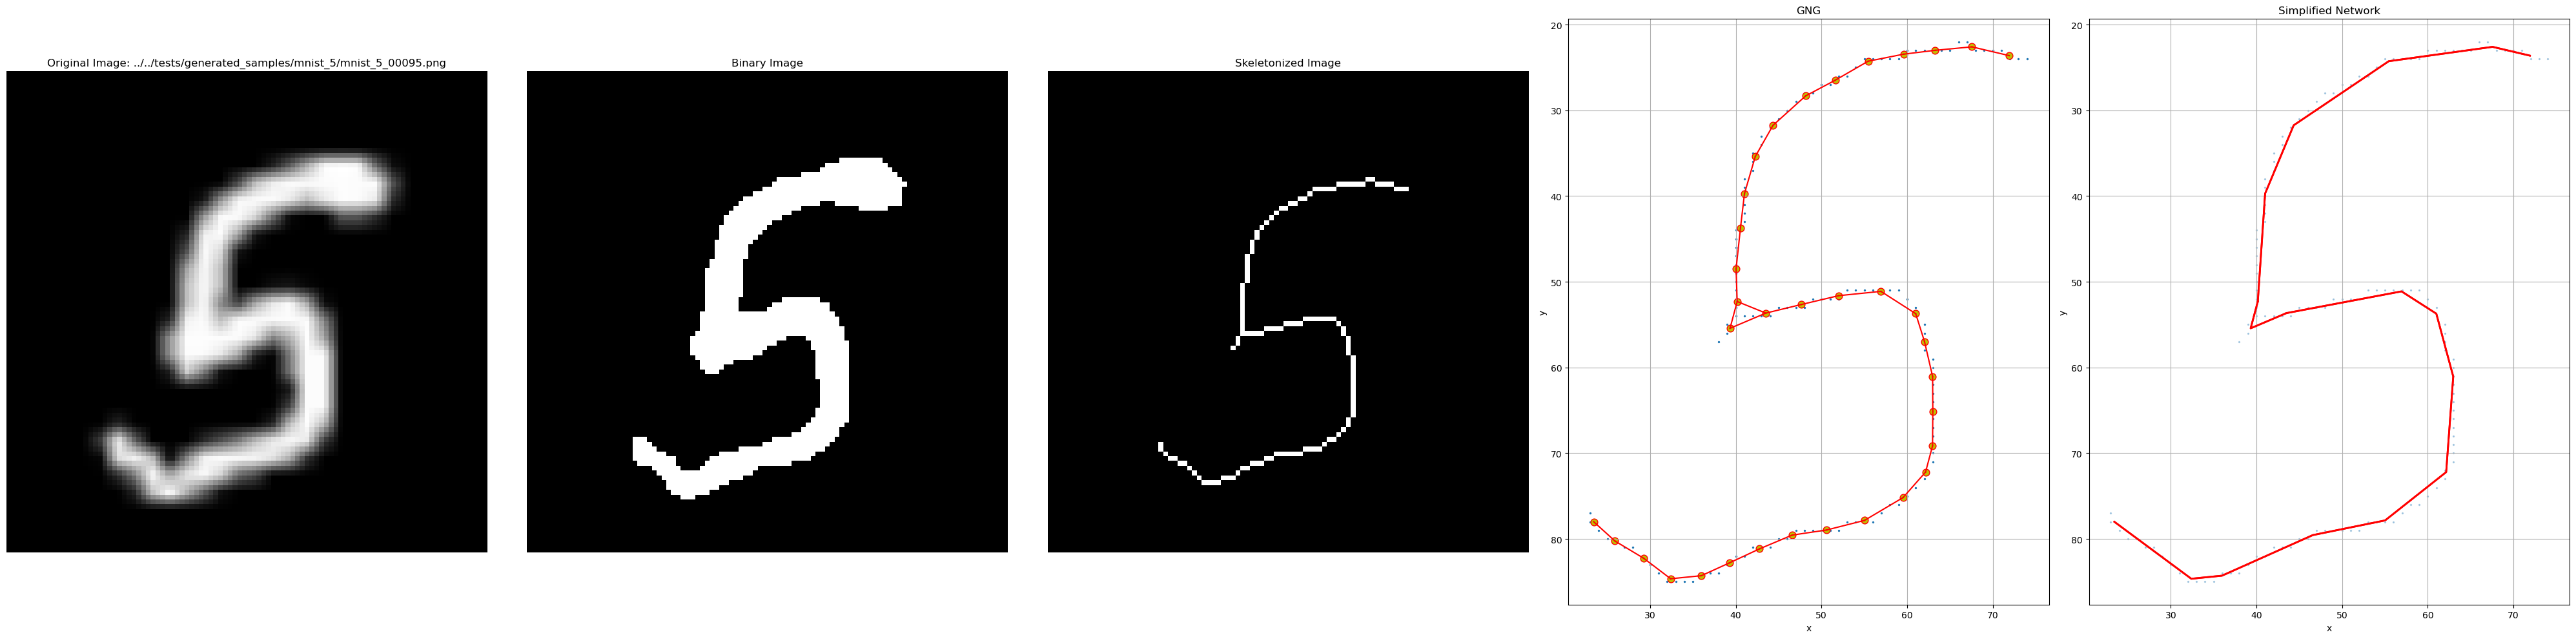

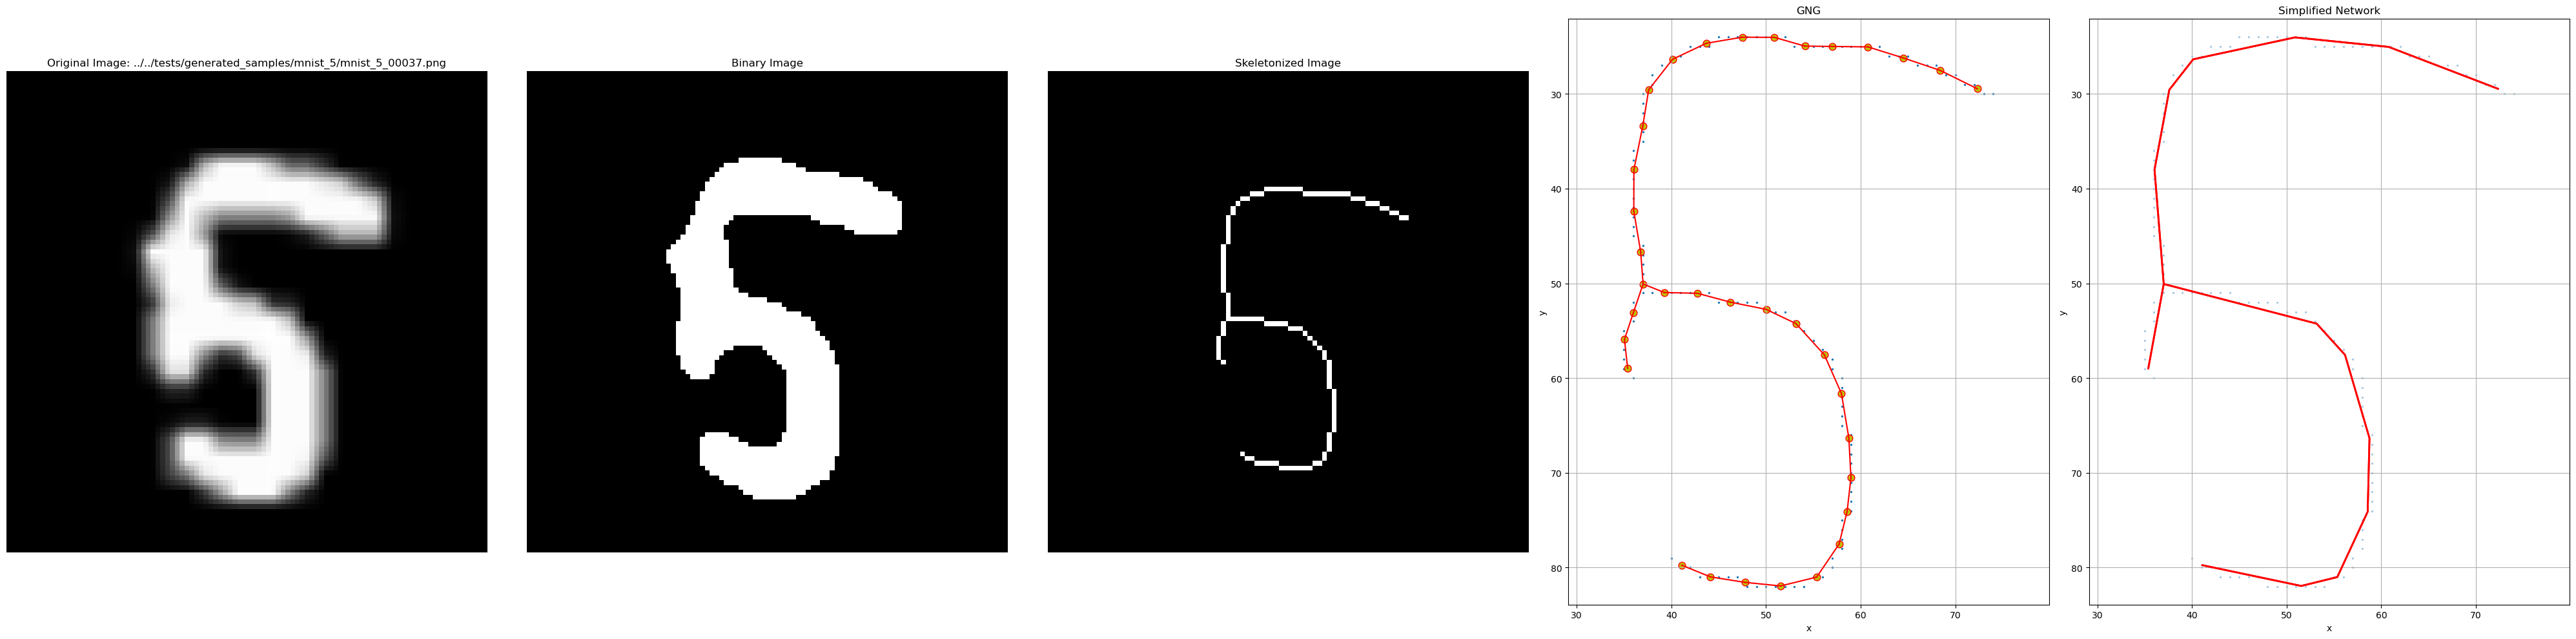

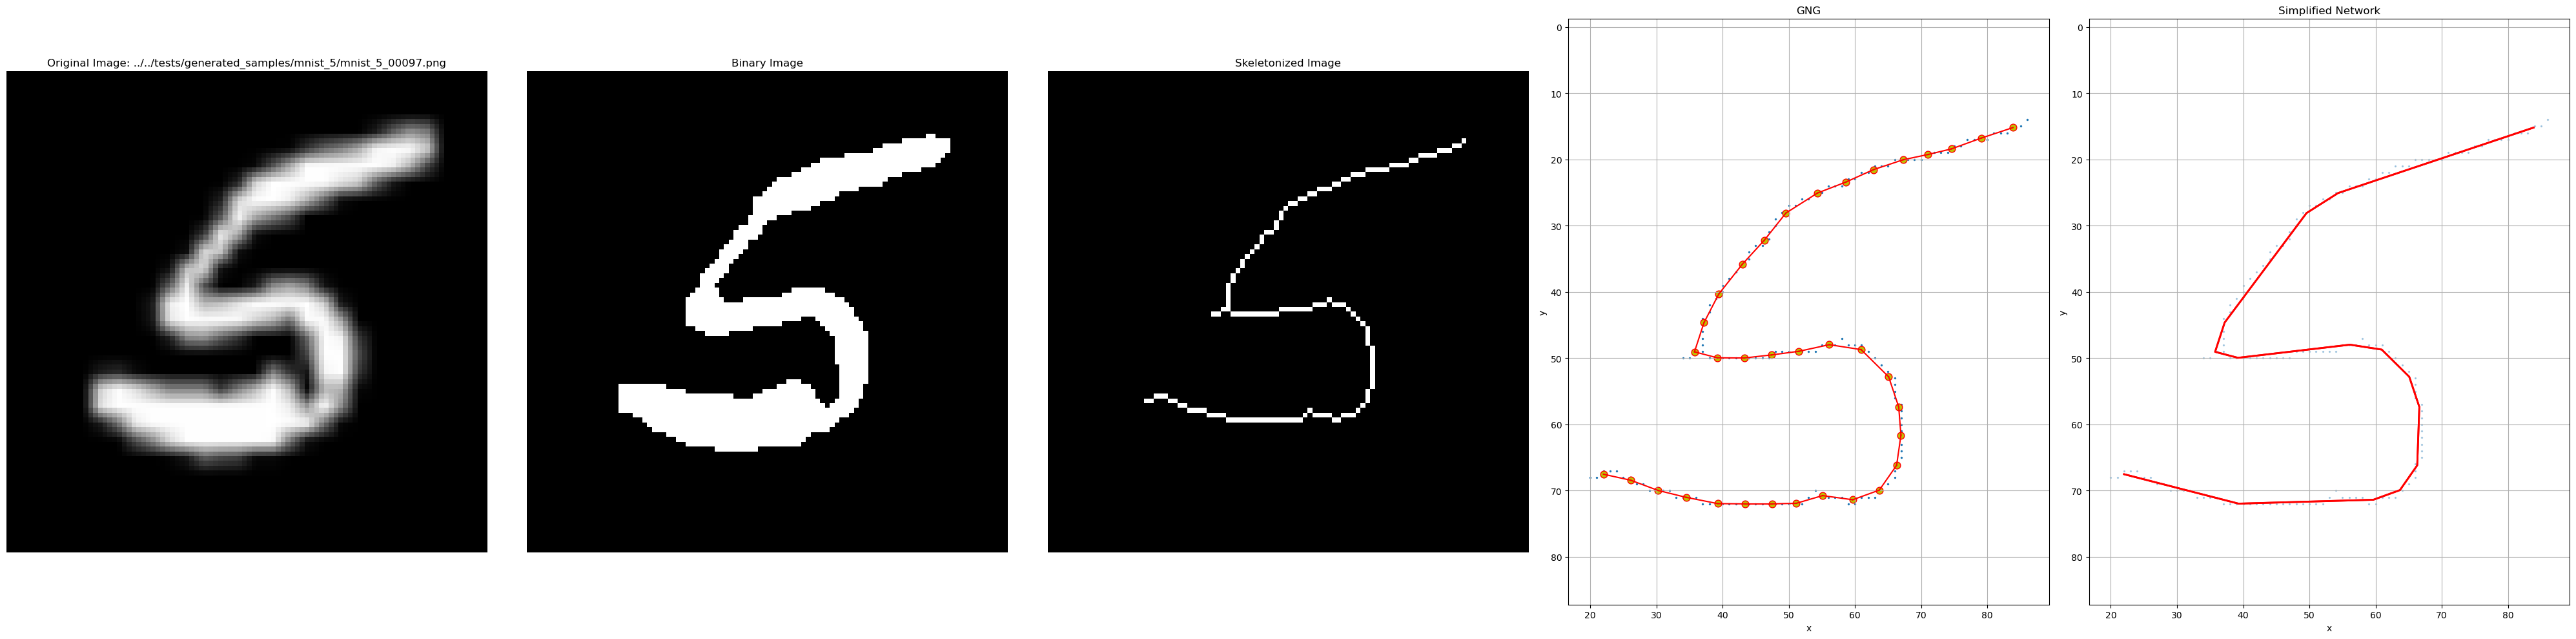

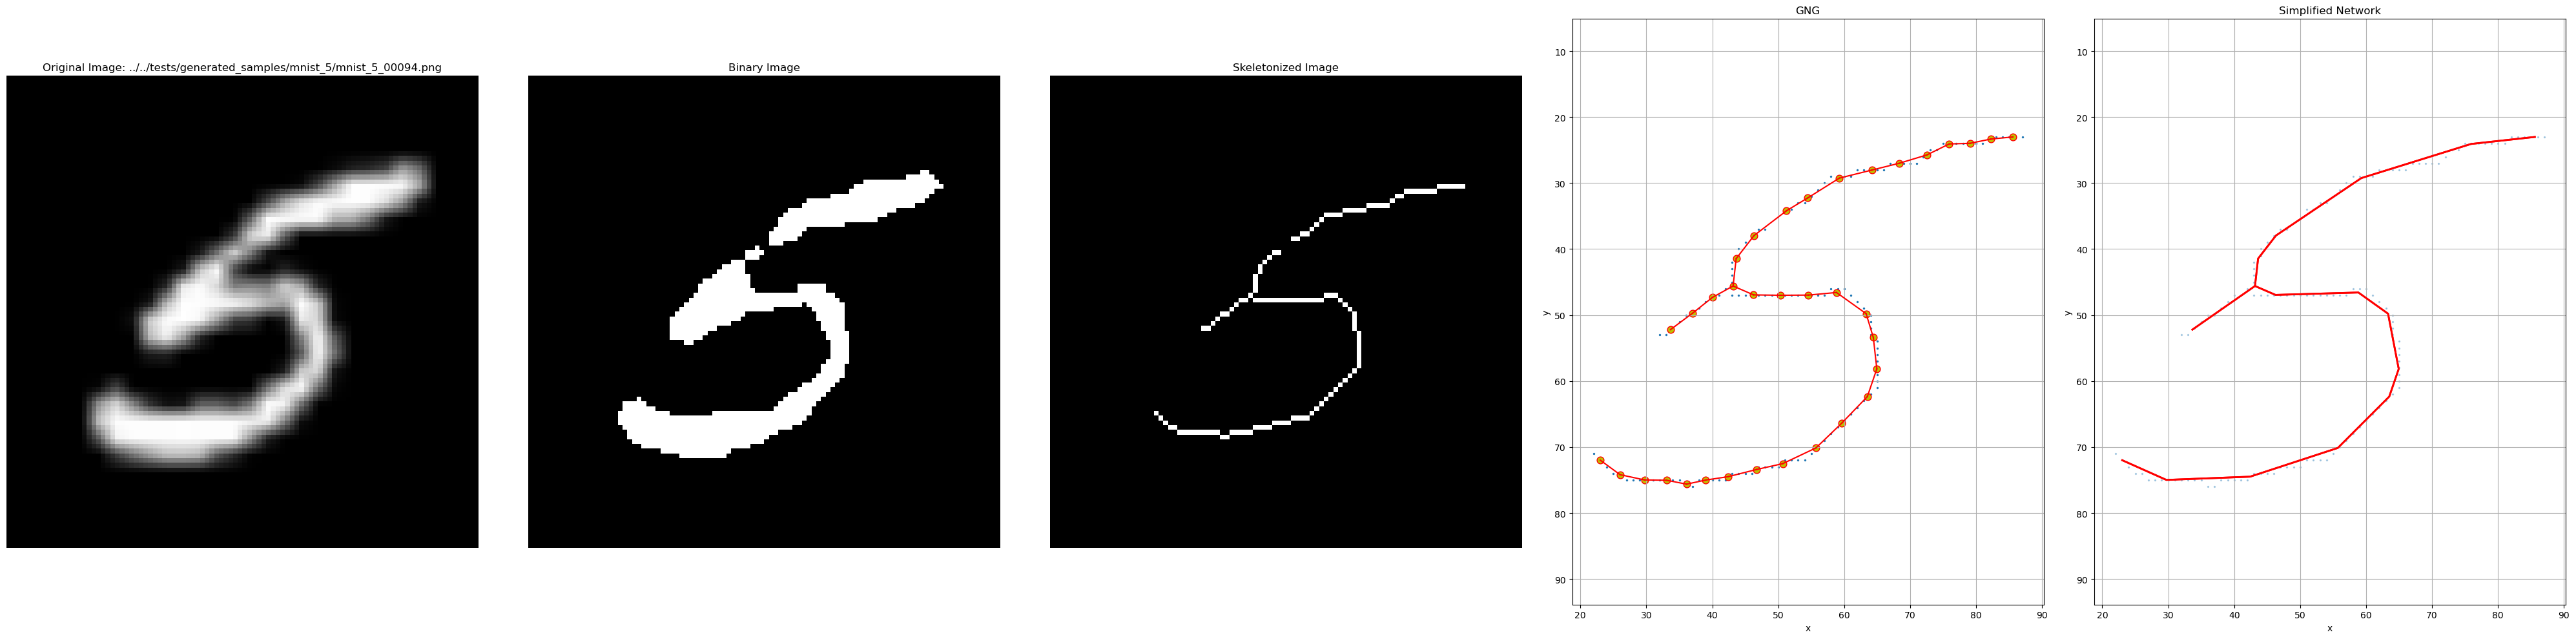

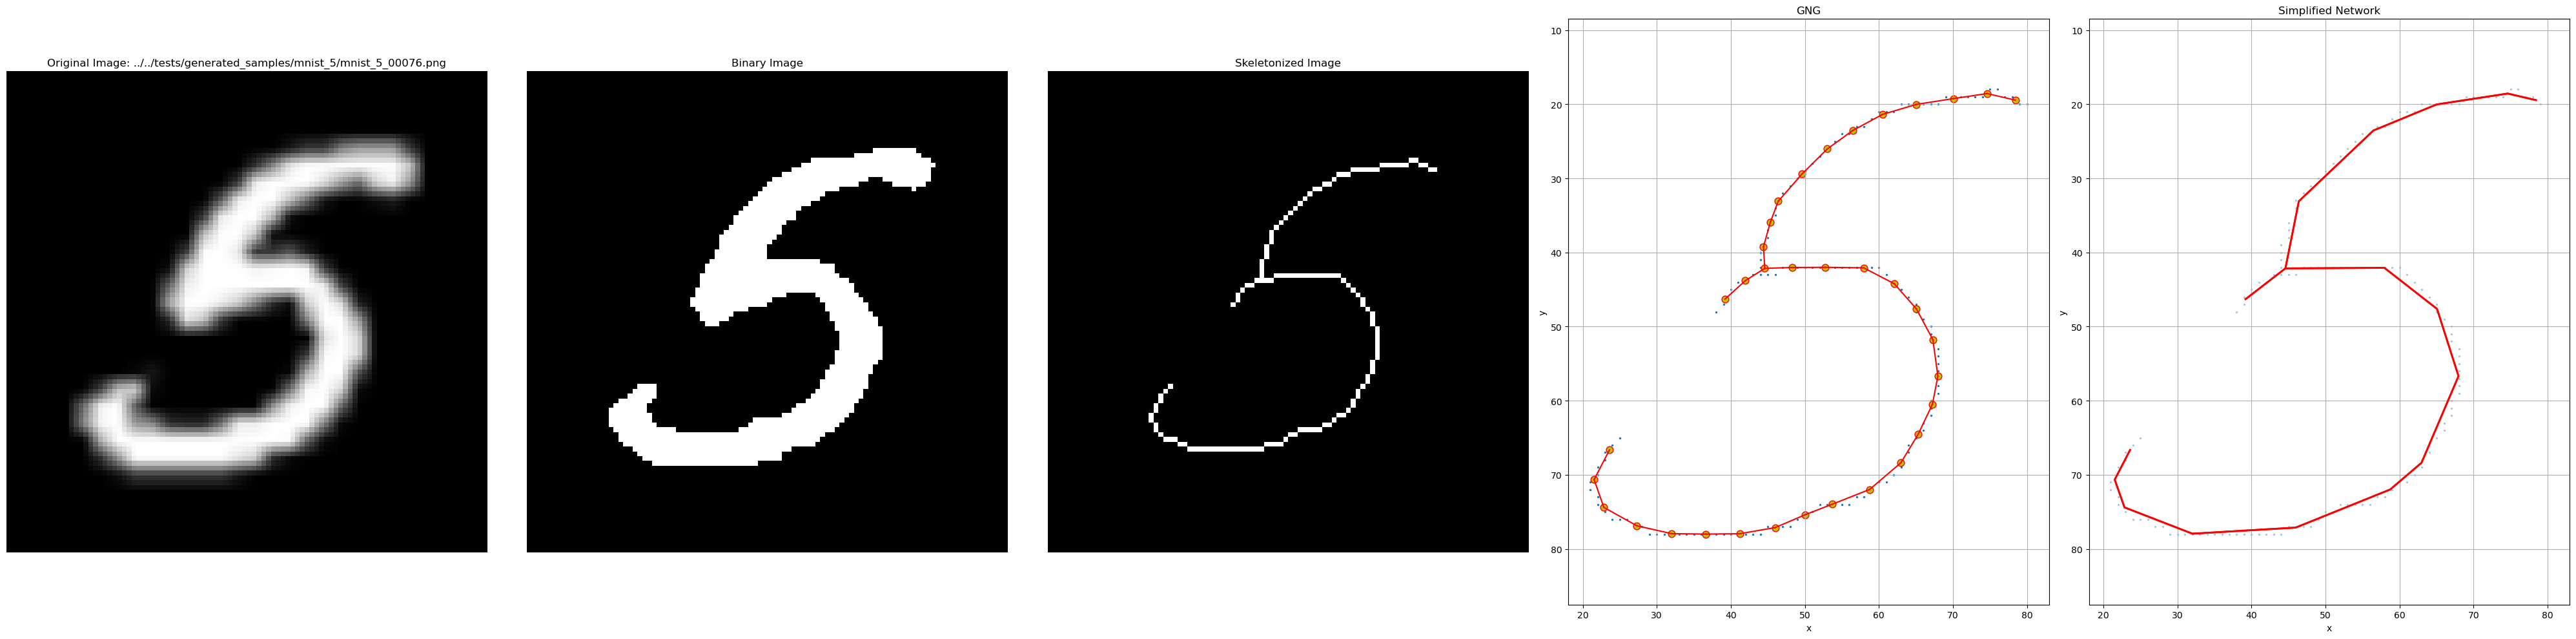

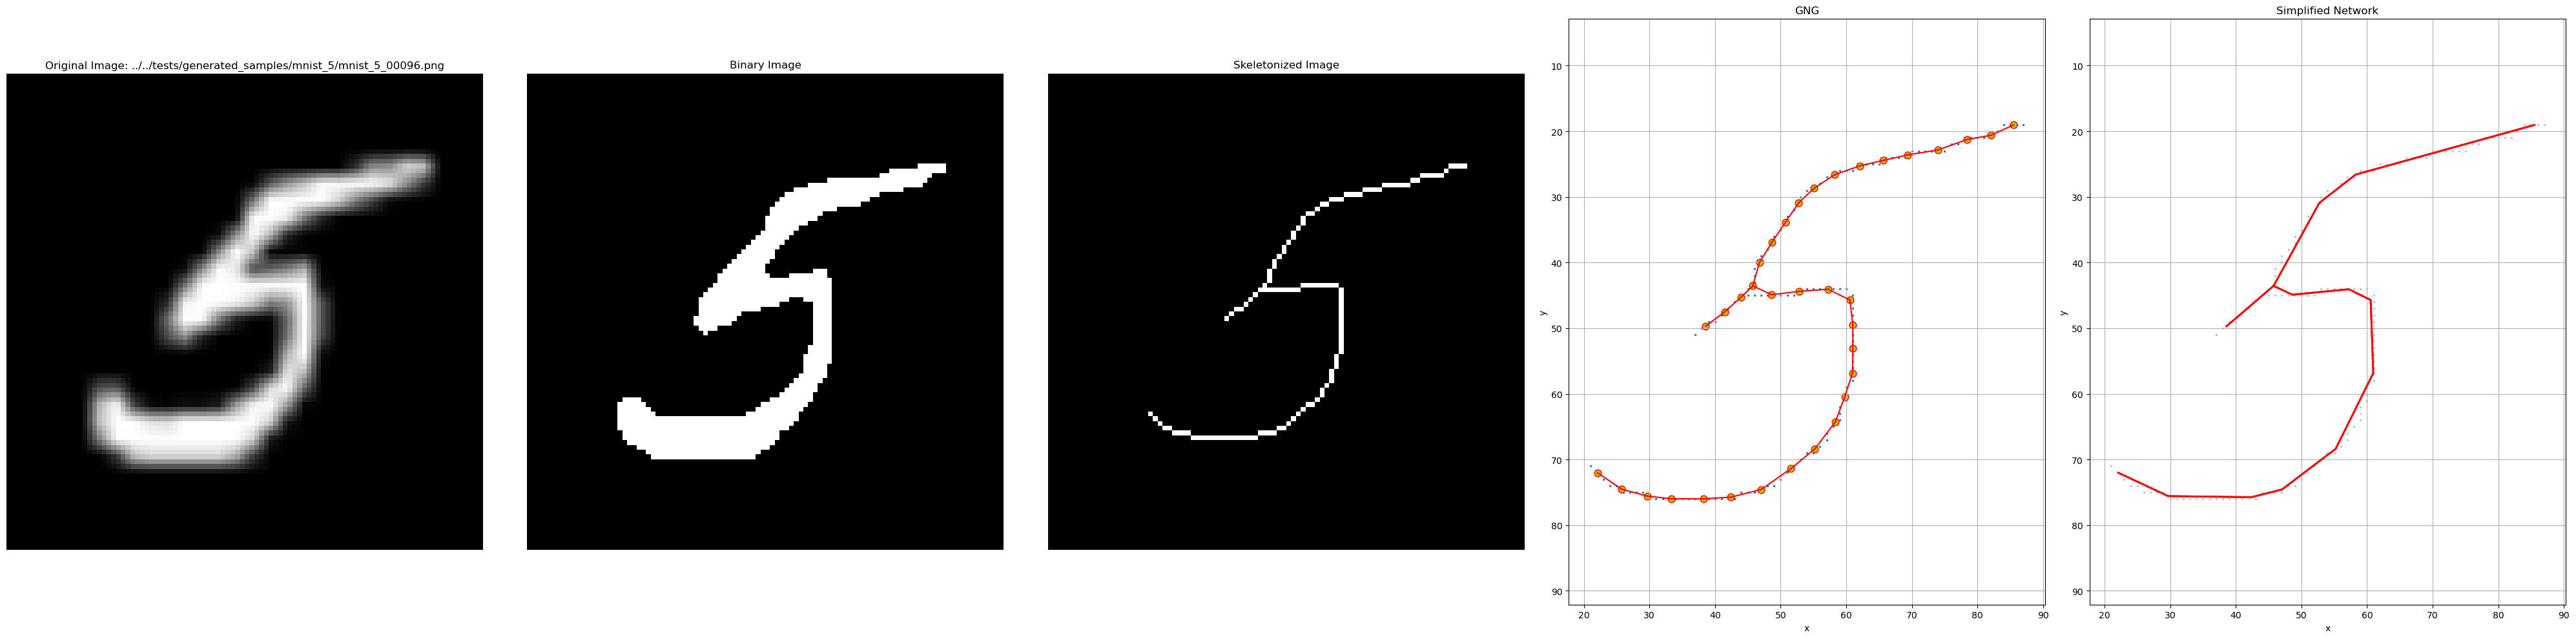

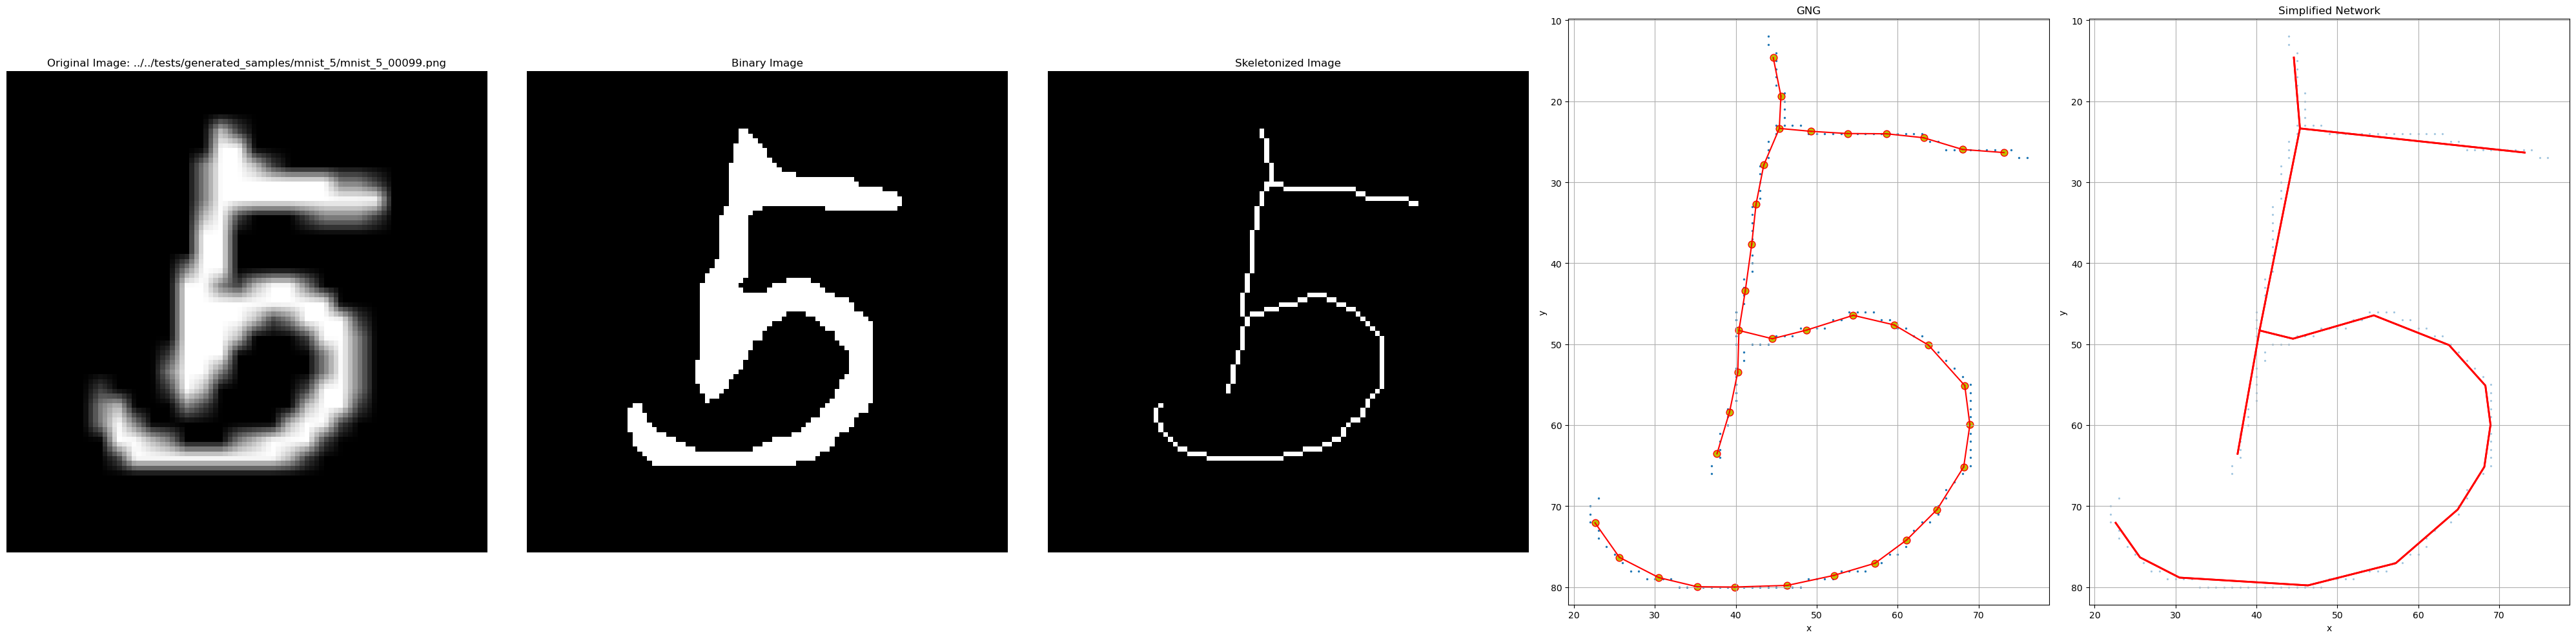

In [15]:
# Get 10 random images from the folder
folder_path = '../../tests/generated_samples/mnist_5'
images = [os.path.join(folder_path, file) for file in os.listdir(folder_path) if file.endswith((".png", ".jpg", ".jpeg", ".tiff", ".bmp", ".gif"))]
random_images = np.random.choice(images, 50, replace=False)

for image_path in random_images:
    image = imread(image_path, 0)
    binary = binary_image(image_path)
    skeleton = skeleton_image(image_path)
    image_points = get_image_points(skeleton)
    network = gng_process(image_points)
    simplified_network = simplify_network(network)
    plot_network_result(image_path, network, params, image_points, image, binary, skeleton, simplified_network)